## 1. Project Overview and Modeling Strategy

This project aims to **maximize revenue from direct marketing campaigns** for a retail bank by identifying the most promising clients to target with specific financial product offers.

### 🧾 Available Data Sources

The analysis utilizes several data tables:

- **Social-demographic data**: Age, gender, tenure at the bank  
- **Product holdings & balances**: Current/saving accounts, mutual funds, overdraft, credit card, consumer loan  
- **Behavioral metrics**: Inflows/outflows on current accounts, aggregated credit card turnover (monthly average over the past 3 months)  
- **Labeled training set**: For ~60% of clients, actual product sales and revenue data are available  

### 🏦 Business Constraints & Goals

- The bank can contact only **15% of clients** (~100 people), and **each client can be targeted only once**.
- Expected outcomes from the analysis:
  - Identify clients with **high propensity to buy**:
    - Consumer Loan (CL)
    - Credit Card (CC)
    - Mutual Fund (MF)
  - Provide **recommendations** on which client to target with which offer
  - **Estimate expected revenue** from the proposed targeting strategy

### 🧠 Modeling Methodology

A combined **classification and regression approach** is developed to address both product uptake and expected revenue:

- 🔗 **Feature Integration**: All features from `Soc_Dem`, `Products_ActBalance`, and `Inflow_Outflow` are merged.
- 🎯 **Classification**: For each product (`MF`, `CC`, `CL`), a model predicts the **purchase propensity**.
- 💰 **Regression**: For each product, models predict the **expected revenue** and generate **90% confidence intervals** via quantile regression.
- 📊 **Client Scoring**:
  - For each client, the expected revenue from each product is weighted by the predicted probability of purchase.
  - Total expected revenue across all products is computed.
- 🎯 **Target Selection**:
  - The **top 100 clients** with the highest predicted total revenue are selected as the **recommended targets** for the campaign.

### 📝 Deliverables

- A **two-page executive summary** of the findings and approach
- A **technical report** listing selected clients and their recommended offers

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Importing the Data from the Excel Worksheets

In [49]:
raw_data_path: str = "../data/raw/"
excl_file_name = "Task_Data_Scientist_Dataset.xlsx"

# Parse the Excel file into DataFrame objects 
xlsx = pd.ExcelFile(os.path.join(raw_data_path, excl_file_name))

# Read the worksheets into dataframes
df_Soc_Dem: pd.DataFrame = xlsx.parse("Soc_Dem", header=0) 
df_Products_ActBalance: pd.DataFrame = xlsx.parse("Products_ActBalance", header=0) 
df_Inflow_Outflow: pd.DataFrame = xlsx.parse("Inflow_Outflow", header=0) 
df_Sales_Revenues: pd.DataFrame = xlsx.parse("Sales_Revenues", header=0) 

## 3. Basic EDA of the Dataframes

In [56]:
# Table Soc_Dem
df_Soc_Dem.info()
df_Soc_Dem.describe()

NameError: name 'df_Soc_Dem' is not defined

In [ ]:
# Table Products_ActBalance
df_Products_ActBalance.info()
df_Products_ActBalance.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Client      1615 non-null   int64  
 1   Count_CA    1615 non-null   int64  
 2   Count_SA    426 non-null    float64
 3   Count_MF    306 non-null    float64
 4   Count_OVD   419 non-null    float64
 5   Count_CC    170 non-null    float64
 6   Count_CL    135 non-null    float64
 7   ActBal_CA   1615 non-null   float64
 8   ActBal_SA   426 non-null    float64
 9   ActBal_MF   306 non-null    float64
 10  ActBal_OVD  419 non-null    float64
 11  ActBal_CC   170 non-null    float64
 12  ActBal_CL   135 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 164.2 KB


,Client,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,ActBal_SA,ActBal_MF,ActBal_OVD,ActBal_CC,ActBal_CL
count,1615.000000,1615.000000,426.000000,306.000000,419.0,170.0,135.000000,1615.000000,426.000000,306.000000,419.000000,170.000000,135.000000
mean,808.000000,1.078638,1.166667,4.676471,1.0,1.0,1.185185,2438.601941,15201.520284,20517.533479,126.449897,351.295420,4237.641981
std,466.354658,0.333035,0.468205,7.845009,0.0,0.0,0.520980,7072.777350,32365.183430,78046.994833,290.573266,486.679857,4167.134365
min,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,-15.479286,0.000000
25%,404.500000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,61.562143,728.145000,0.000000,0.000000,1.241071,1020.163393
50%,808.000000,1.000000,1.000000,2.000000,1.0,1.0,1.000000,462.221786,4413.503571,1700.943036,0.000000,153.006071,3141.900000
75%,1211.500000,1.000000,1.000000,5.000000,1.0,1.0,1.000000,2174.864286,14622.666071,11169.181339,93.114286,545.008839,5851.657679
max,1615.000000,4.000000,5.000000,79.000000,1.0,1.0,5.000000,171575.889643,389883.830714,761235.504286,2055.325357,3522.233571,20749.294643


In [ ]:
# Table Inflow_Outflow
df_Inflow_Outflow.info()
df_Inflow_Outflow.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Client                        1587 non-null   int64  
 1   VolumeCred                    1587 non-null   float64
 2   VolumeCred_CA                 1587 non-null   float64
 3   TransactionsCred              1587 non-null   int64  
 4   TransactionsCred_CA           1587 non-null   int64  
 5   VolumeDeb                     1587 non-null   float64
 6   VolumeDeb_CA                  1587 non-null   float64
 7   VolumeDebCash_Card            1587 non-null   float64
 8   VolumeDebCashless_Card        1587 non-null   float64
 9   VolumeDeb_PaymentOrder        1587 non-null   float64
 10  TransactionsDeb               1587 non-null   int64  
 11  TransactionsDeb_CA            1587 non-null   int64  
 12  TransactionsDebCash_Card      1587 non-null   int64  
 13  Tra

,Client,VolumeCred,VolumeCred_CA,TransactionsCred,TransactionsCred_CA,VolumeDeb,VolumeDeb_CA,VolumeDebCash_Card,VolumeDebCashless_Card,VolumeDeb_PaymentOrder,TransactionsDeb,TransactionsDeb_CA,TransactionsDebCash_Card,TransactionsDebCashless_Card,TransactionsDeb_PaymentOrder
count,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000
mean,808.174543,1823.559572,1506.329113,5.541903,4.265280,1697.218658,1460.202903,257.937337,150.850401,715.974931,16.006931,13.596723,1.988658,5.240076,4.601134
std,466.744374,5864.792552,4661.535696,6.355383,4.944032,5183.787844,4281.369956,757.734230,311.938796,3215.106760,16.243554,12.975287,2.710704,8.386154,5.211451
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,405.500000,252.923393,214.290893,2.000000,2.000000,226.214286,211.848750,0.000000,0.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000
50%,808.000000,655.867500,620.858214,3.000000,3.000000,654.615357,632.148929,71.428571,20.139286,175.428571,11.000000,10.000000,1.000000,1.000000,3.000000
75%,1213.500000,1426.027143,1304.757143,6.000000,4.000000,1418.208214,1329.007857,353.370536,175.892500,507.607143,22.000000,19.000000,3.000000,7.000000,7.000000
max,1615.000000,107703.804286,98717.675000,63.000000,48.000000,119906.503929,73477.932500,23571.428571,3637.616786,72278.782143,102.000000,83.000000,25.000000,60.000000,34.000000


In [ ]:
# Table Sales_Revenues
df_Sales_Revenues.info()
df_Sales_Revenues.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Client      969 non-null    int64  
 1   Sale_MF     969 non-null    int64  
 2   Sale_CC     969 non-null    int64  
 3   Sale_CL     969 non-null    int64  
 4   Revenue_MF  969 non-null    float64
 5   Revenue_CC  969 non-null    float64
 6   Revenue_CL  969 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 53.1 KB


,Client,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000
mean,814.781218,0.199174,0.249742,0.299278,1.925015,2.712827,3.604220
std,464.568139,0.399586,0.433087,0.458178,9.943601,17.693433,7.743618
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,422.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,819.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1216.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.642857
max,1615.000000,1.000000,1.000000,1.000000,220.488214,407.962500,133.275357


In [ ]:
# Check the overlap of the Client IDs between different tables

df_merged_Soc_Products = pd.merge(left=df_Soc_Dem, right=df_Products_ActBalance, left_on='Client', right_on='Client')
num_common_ids_Soc_Products = df_merged_Soc_Products.shape[0]

df_merged_Soc_Products_Flow = pd.merge(left=df_merged_Soc_Products, right=df_Inflow_Outflow, left_on='Client', right_on='Client')
num_common_ids_Soc_Products_Flow = df_merged_Soc_Products_Flow.shape[0]

df_merged_all = pd.merge(left=df_merged_Soc_Products_Flow, right=df_Sales_Revenues, left_on='Client', right_on='Client')
num_common_ids_Soc_Products_Flow_Revenues = df_merged_all.shape[0]

print(f"Num. of common Client IDs in Soc_Dem and Products_ActBalance: {num_common_ids_Soc_Products}")
print(f"Num. of common Client IDs in Soc_Dem, Products_ActBalance, and Inflow_Outflow: {num_common_ids_Soc_Products_Flow}")
print(f"Num. of common Client IDs in Sales_Revenues and other tables: {num_common_ids_Soc_Products_Flow_Revenues}")


Num. of common Client IDs in Soc_Dem and Products_ActBalance: 1615
Num. of common Client IDs in Soc_Dem, Products_ActBalance, and Inflow_Outflow: 1587
Num. of common Client IDs in Sales_Revenues and other tables: 951


In [ ]:
# Calculate the target rates for the products MF, CC, and CL

target_rate_Sale_MF = df_Sales_Revenues['Sale_MF'].sum() / df_Sales_Revenues.shape[0]
target_rate_Sale_CC = df_Sales_Revenues['Sale_CC'].sum() / df_Sales_Revenues.shape[0]
target_rate_Sale_CL = df_Sales_Revenues['Sale_CL'].sum() / df_Sales_Revenues.shape[0]

print(f"Sale_MF target rate: {target_rate_Sale_MF}")
print(f"Sale_CC target rate: {target_rate_Sale_CC}")
print(f"Sale_CL target rate: {target_rate_Sale_CL}")


Sale_MF target rate: 0.19917440660474717
Sale_CC target rate: 0.24974200206398348
Sale_CL target rate: 0.29927760577915374


### <span style="color:orange">**Data Audit Summary and Observations**</span>

This section presents an overview of the structure, content, and quality of the input data used in the analysis.

---

#### 🧾 Number of Client IDs in Each Table

| Table                | Number of Client IDs |
|----------------------|----------------------|
| `Soc_Dem`            | 1,615                |
| `Products_ActBalance`| 1,615                |
| `Inflow_Outflow`     | 1,587                |
| `Sales_Revenues`     | 969                  |

---

#### 🏷️ Feature Types

- **Categorical Feature**
  - `Sex` (in `Soc_Dem` table)

- **Numerical Features**
  - All other columns in all tables except `Client` and `Sex`

---

#### ⚠️ Missing Value Analysis

- `Soc_Dem` table:
  - 3 missing values in the `Sex` column

- **Numerical features** (across all tables):
  - Missing values can be safely imputed as **zero**

- `Sales_Revenues` table:
  - No missing values; each record contains complete values for all 6 target variables

---

#### 🔗 Client ID Overlap Across Tables

- `Sales_Revenues` (training set):
  - Contains 969 unique client IDs
  - Of these, **951** have corresponding records in *all other tables*

- Remaining clients (application set):
  - After excluding 951 training clients, **636** clients are available for prediction (inference)

- Common Client IDs across all base tables: **1,587**

---

#### ⚖️ Target Imbalance Observed

- Significant class imbalance is observed in the binary target columns:
  - `Sale_MF`
  - `Sale_CC`
  - `Sale_CL`

  This imbalance should be taken into account when training the classification models.

## 4. Preparing the Datasets for Modeling and Prediction

In [56]:
# Change the data type of "Client" column to str in each dataframe to use it as the record ID.
df_merged_Soc_Products_Flow['Client'] = df_merged_Soc_Products_Flow['Client'].astype(str)
df_Sales_Revenues['Client'] = df_Sales_Revenues['Client'].astype(str)

In [57]:
from sklearn.impute import SimpleImputer

# The "Sex" column has only 3 missing values. Mode imputation is applied to fill in the missing values.
gender_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df_merged_Soc_Products_Flow['Sex'] = gender_imputer.fit_transform(df_merged_Soc_Products_Flow['Sex'].values.reshape(-1, 1))[:, 0]

# Impute the missing values of all numerical columns as 0
df_merged_Soc_Products_Flow.fillna(0.0, inplace=True)

# Generate one-hot encoding for the "Sex" feature
df_encoded_Soc_Products_Flow = pd.get_dummies(df_merged_Soc_Products_Flow, columns=['Sex'], drop_first=True, dtype=int)

# Create the dataset for training
df_modeling = pd.merge(left=df_encoded_Soc_Products_Flow, right=df_Sales_Revenues, left_on='Client', right_on='Client')

# Create the dataset for prediction
df_outer = pd.merge(left=df_encoded_Soc_Products_Flow, right=df_Sales_Revenues, how='outer', 
                    left_on='Client', right_on='Client', indicator = True)
df_prediction = df_outer[(df_outer._merge=='left_only')].drop(['_merge', 
                                                               'Sale_MF',
                                                               'Sale_CC',
                                                               'Sale_CL',
                                                               'Revenue_MF',
                                                               'Revenue_CC',
                                                               'Revenue_CL'], axis=1)

Text(0.5, 1.0, 'Correlation between the features and the targets')

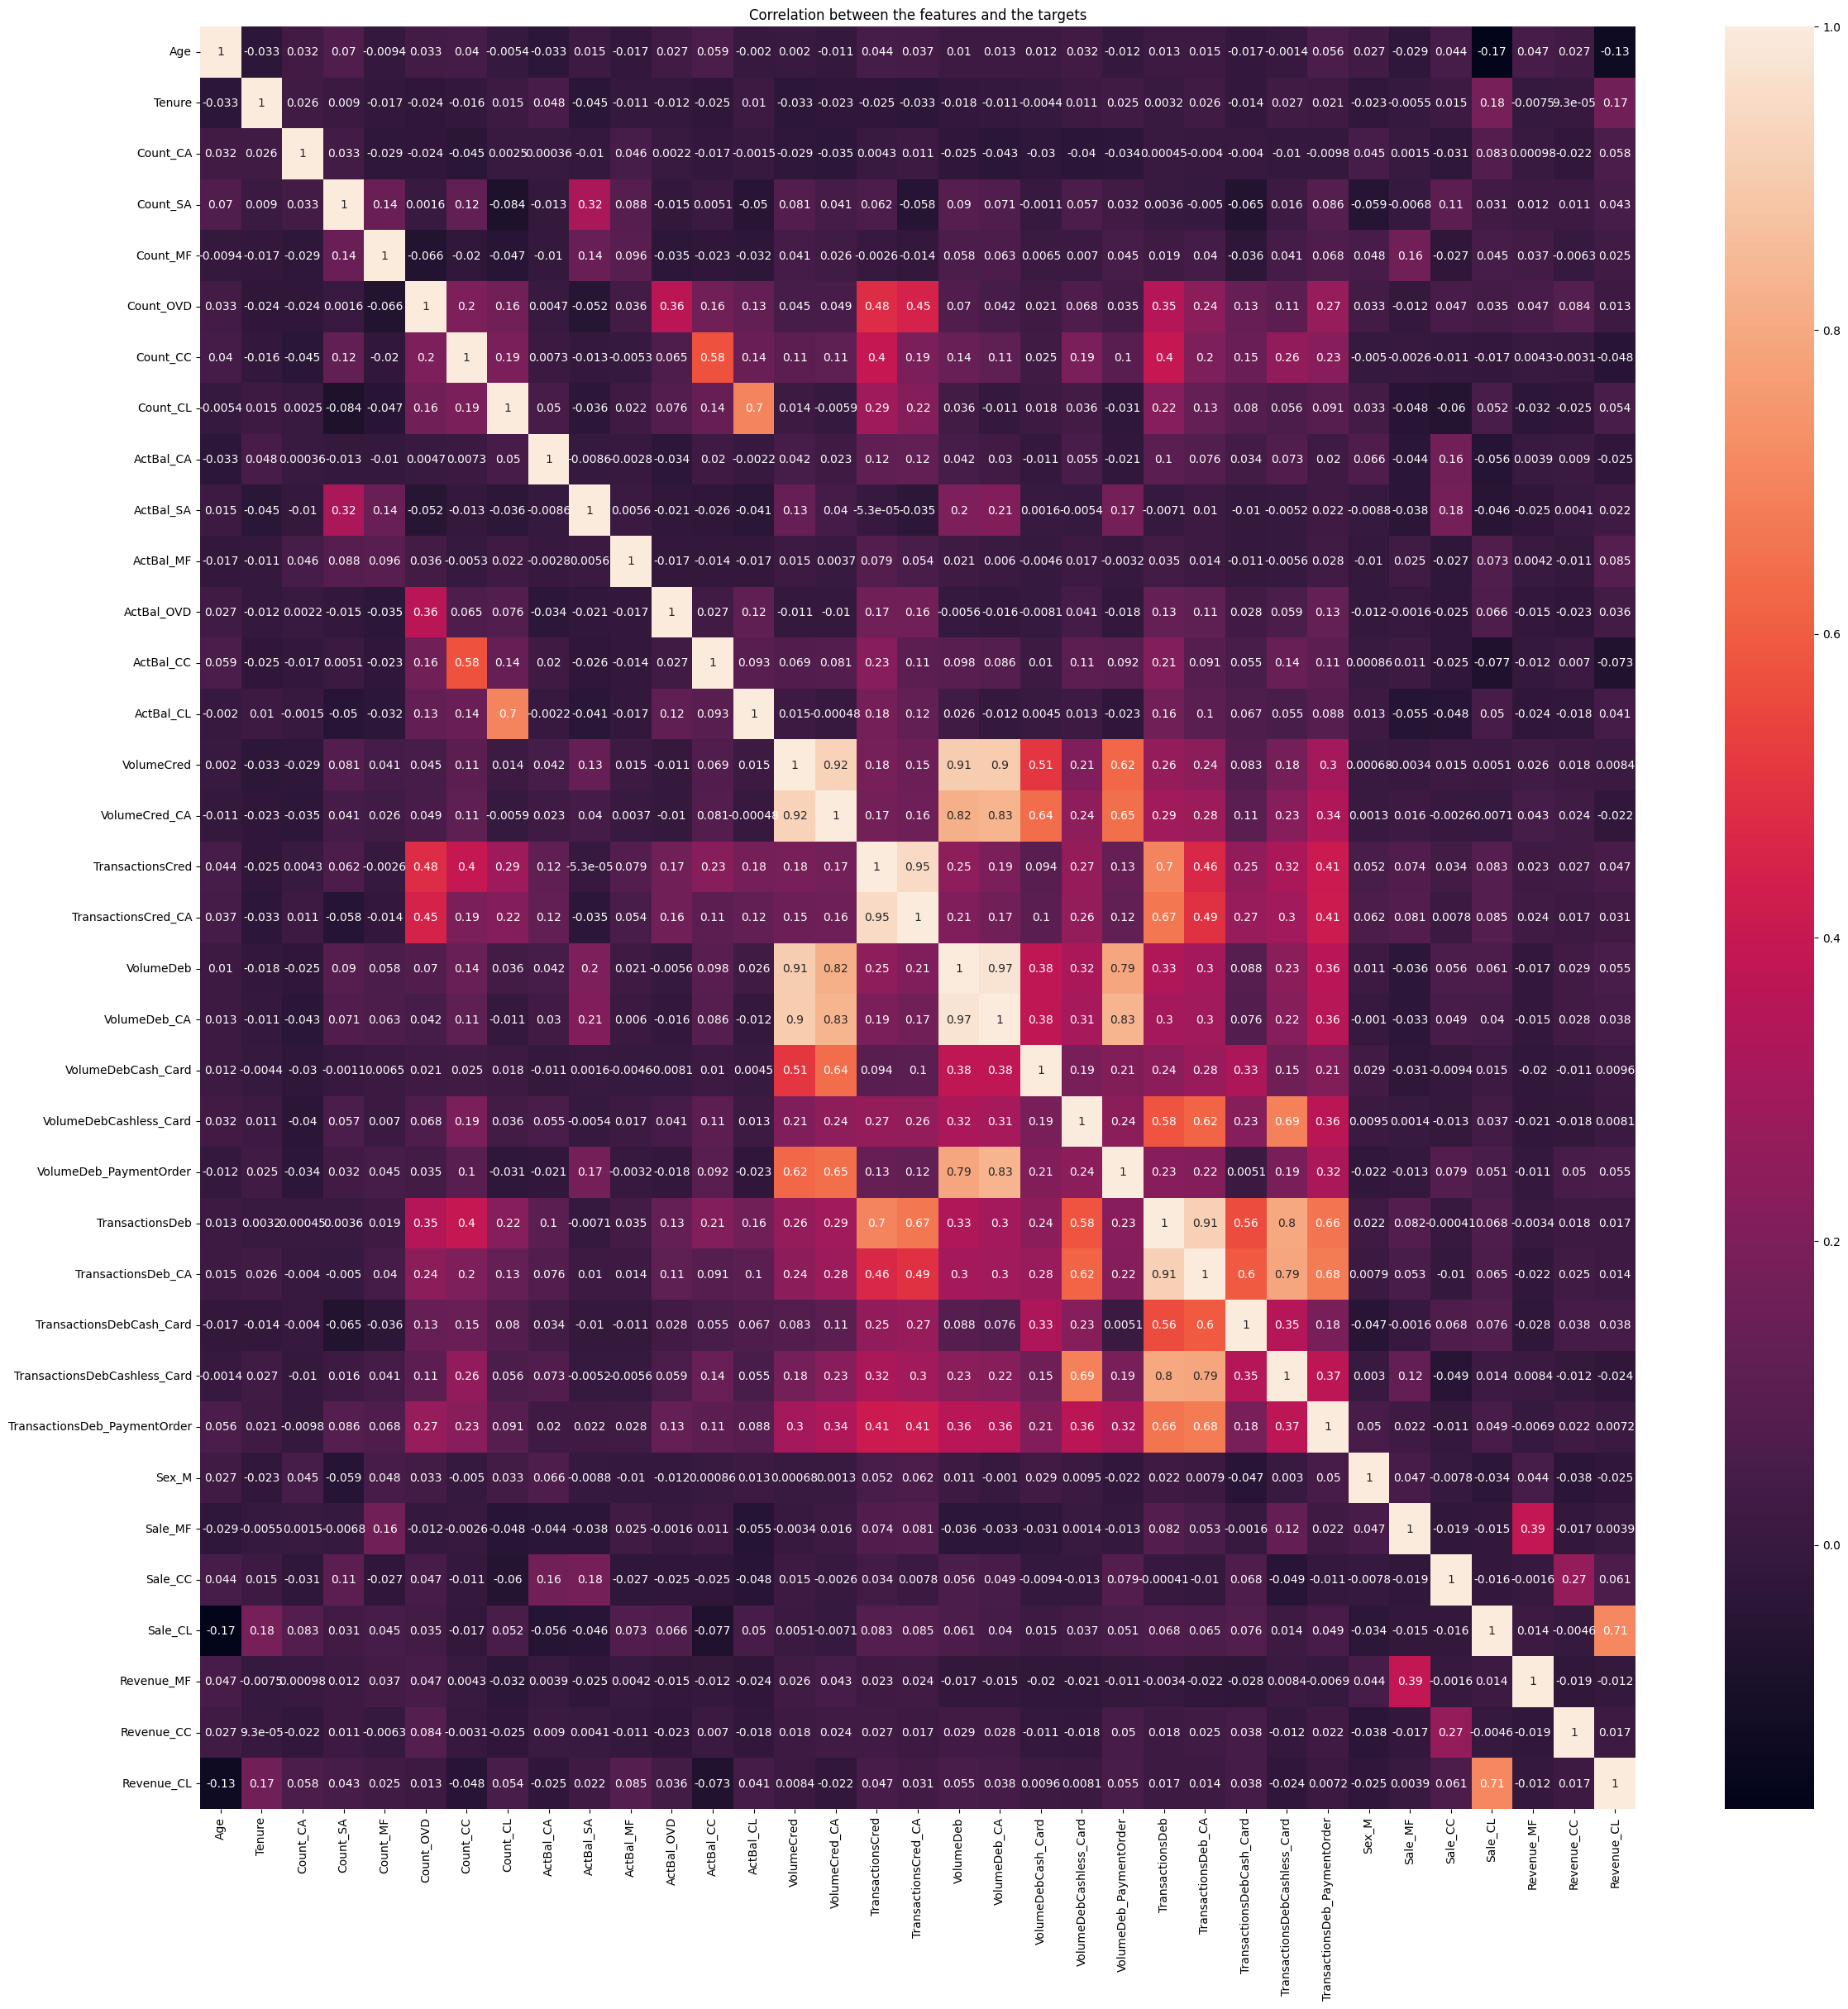

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Perform correlation analysis between the numeric features and the targets, to check if feature selection can be carried out.
df_numeric = df_modeling.drop(['Client'], axis=1).astype('float32')
corr = df_numeric.corr()
fig, ax = plt.subplots(figsize=(28, 28))
g = sns.heatmap(corr, ax=ax, annot=True)
ax.set_title("Correlation between the features and the targets")

In [59]:
# Enrich the data by creating new features

df_enriched_features = df_encoded_Soc_Products_Flow.copy()

# Create flag features for different accounts
df_enriched_features['has_Count_SA'] = np.where(df_enriched_features['Count_SA'] > 0, 1, 0)
df_enriched_features['has_Count_MF'] = np.where(df_enriched_features['Count_MF'] > 0, 1, 0)
df_enriched_features['has_Count_CL'] = np.where(df_enriched_features['Count_CL'] > 0, 1, 0)

# Create average balance features for different accounts
df_enriched_features['avgBal_SA'] = np.where(df_enriched_features['Count_SA'] == 0, 0, df_enriched_features['ActBal_SA'] / df_enriched_features['Count_SA'])
df_enriched_features['avgBal_MF'] = np.where(df_enriched_features['Count_MF'] == 0, 0, df_enriched_features['ActBal_MF'] / df_enriched_features['Count_MF'])
df_enriched_features['avgBal_CL'] = np.where(df_enriched_features['Count_CL'] == 0, 0, df_enriched_features['ActBal_CL'] / df_enriched_features['Count_CL'])

# Create flag features for different types of transactions
df_enriched_features['has_TransactionsCred'] = np.where(df_enriched_features['TransactionsCred'] > 0, 1, 0)
df_enriched_features['has_TransactionsCred_CA'] = np.where(df_enriched_features['TransactionsCred_CA'] > 0, 1, 0)
df_enriched_features['has_TransactionsCred_nonCA'] = np.where((df_enriched_features['TransactionsCred'] > 0) \
                                                  & (df_enriched_features['TransactionsCred'] > df_enriched_features['TransactionsCred_CA']), 1, 0)
df_enriched_features['has_TransactionsDeb'] = np.where(df_enriched_features['TransactionsDeb'] > 0, 1, 0)
df_enriched_features['has_TransactionsDeb_nonCA'] = np.where((df_enriched_features['TransactionsDeb'] > 0) \
                                                  & (df_enriched_features['TransactionsDeb'] > df_enriched_features['TransactionsDeb_CA']), 1, 0)
df_enriched_features['has_TransactionsDebCash'] = np.where(df_enriched_features['TransactionsDebCash_Card'] > 0, 1, 0)
df_enriched_features['has_TransactionsDebCashless'] = np.where(df_enriched_features['TransactionsDebCashless_Card'] > 0, 1, 0)
df_enriched_features['has_PaymentOrder'] = np.where(df_enriched_features['TransactionsDeb_PaymentOrder'] > 0, 1, 0)

# Create average transaction turnover features
df_enriched_features['avg_VolumeCred'] = np.where(df_enriched_features['TransactionsCred'] == 0, 0, df_enriched_features['VolumeCred'] / df_enriched_features['TransactionsCred'])
df_enriched_features['avg_VolumeCred_CA'] = np.where(df_enriched_features['TransactionsCred_CA'] == 0, 0, df_enriched_features['VolumeCred_CA'] / df_enriched_features['TransactionsCred_CA'])
df_enriched_features['avg_VolumeDeb'] = np.where(df_enriched_features['TransactionsDeb'] == 0, 0, df_enriched_features['VolumeDeb'] / df_enriched_features['TransactionsDeb'])
df_enriched_features['avg_VolumeDeb_CA'] = np.where(df_enriched_features['TransactionsDeb_CA'] == 0, 0, df_enriched_features['VolumeDeb_CA'] / df_enriched_features['TransactionsDeb_CA'])
df_enriched_features['avg_VolumeDebCash'] = np.where(df_enriched_features['TransactionsDebCash_Card'] == 0, 0, df_enriched_features['VolumeDebCash_Card'] / df_enriched_features['TransactionsDebCash_Card'])
df_enriched_features['avg_VolumeDebCashless'] = np.where(df_enriched_features['TransactionsDebCashless_Card'] == 0, 0, df_enriched_features['VolumeDebCashless_Card'] / df_enriched_features['TransactionsDebCashless_Card'])
df_enriched_features['avg_VolumeDeb_PaymentOrder'] = np.where(df_enriched_features['TransactionsDeb_PaymentOrder'] == 0, 0, df_enriched_features['VolumeDeb_PaymentOrder'] / df_enriched_features['TransactionsDeb_PaymentOrder'])

# Create difference features
df_enriched_features['VolumeCred_nonCA'] = df_enriched_features['VolumeCred'] - df_enriched_features['VolumeCred_CA']
df_enriched_features['VolumeDeb_nonCA'] = df_enriched_features['VolumeDeb'] - df_enriched_features['VolumeDeb_CA']

df_modeling_enriched = pd.merge(left=df_enriched_features, right=df_Sales_Revenues, left_on='Client', right_on='Client')


# Create the dataset for prediction
df_prediction_enriched = pd.merge(left=df_enriched_features, right=df_Sales_Revenues, how='outer', 
                                    left_on='Client', right_on='Client', indicator = True)  
df_prediction_enriched = df_prediction_enriched[(df_prediction_enriched._merge=='left_only')].drop(['_merge', 
                                                                                                    'Sale_MF',
                                                                                                    'Sale_CC',
                                                                                                    'Sale_CL',
                                                                                                    'Revenue_MF',
                                                                                                    'Revenue_CC',
                                                                                                    'Revenue_CL'], axis=1)


Text(0.5, 1.0, 'Correlation between the created features and the targets')

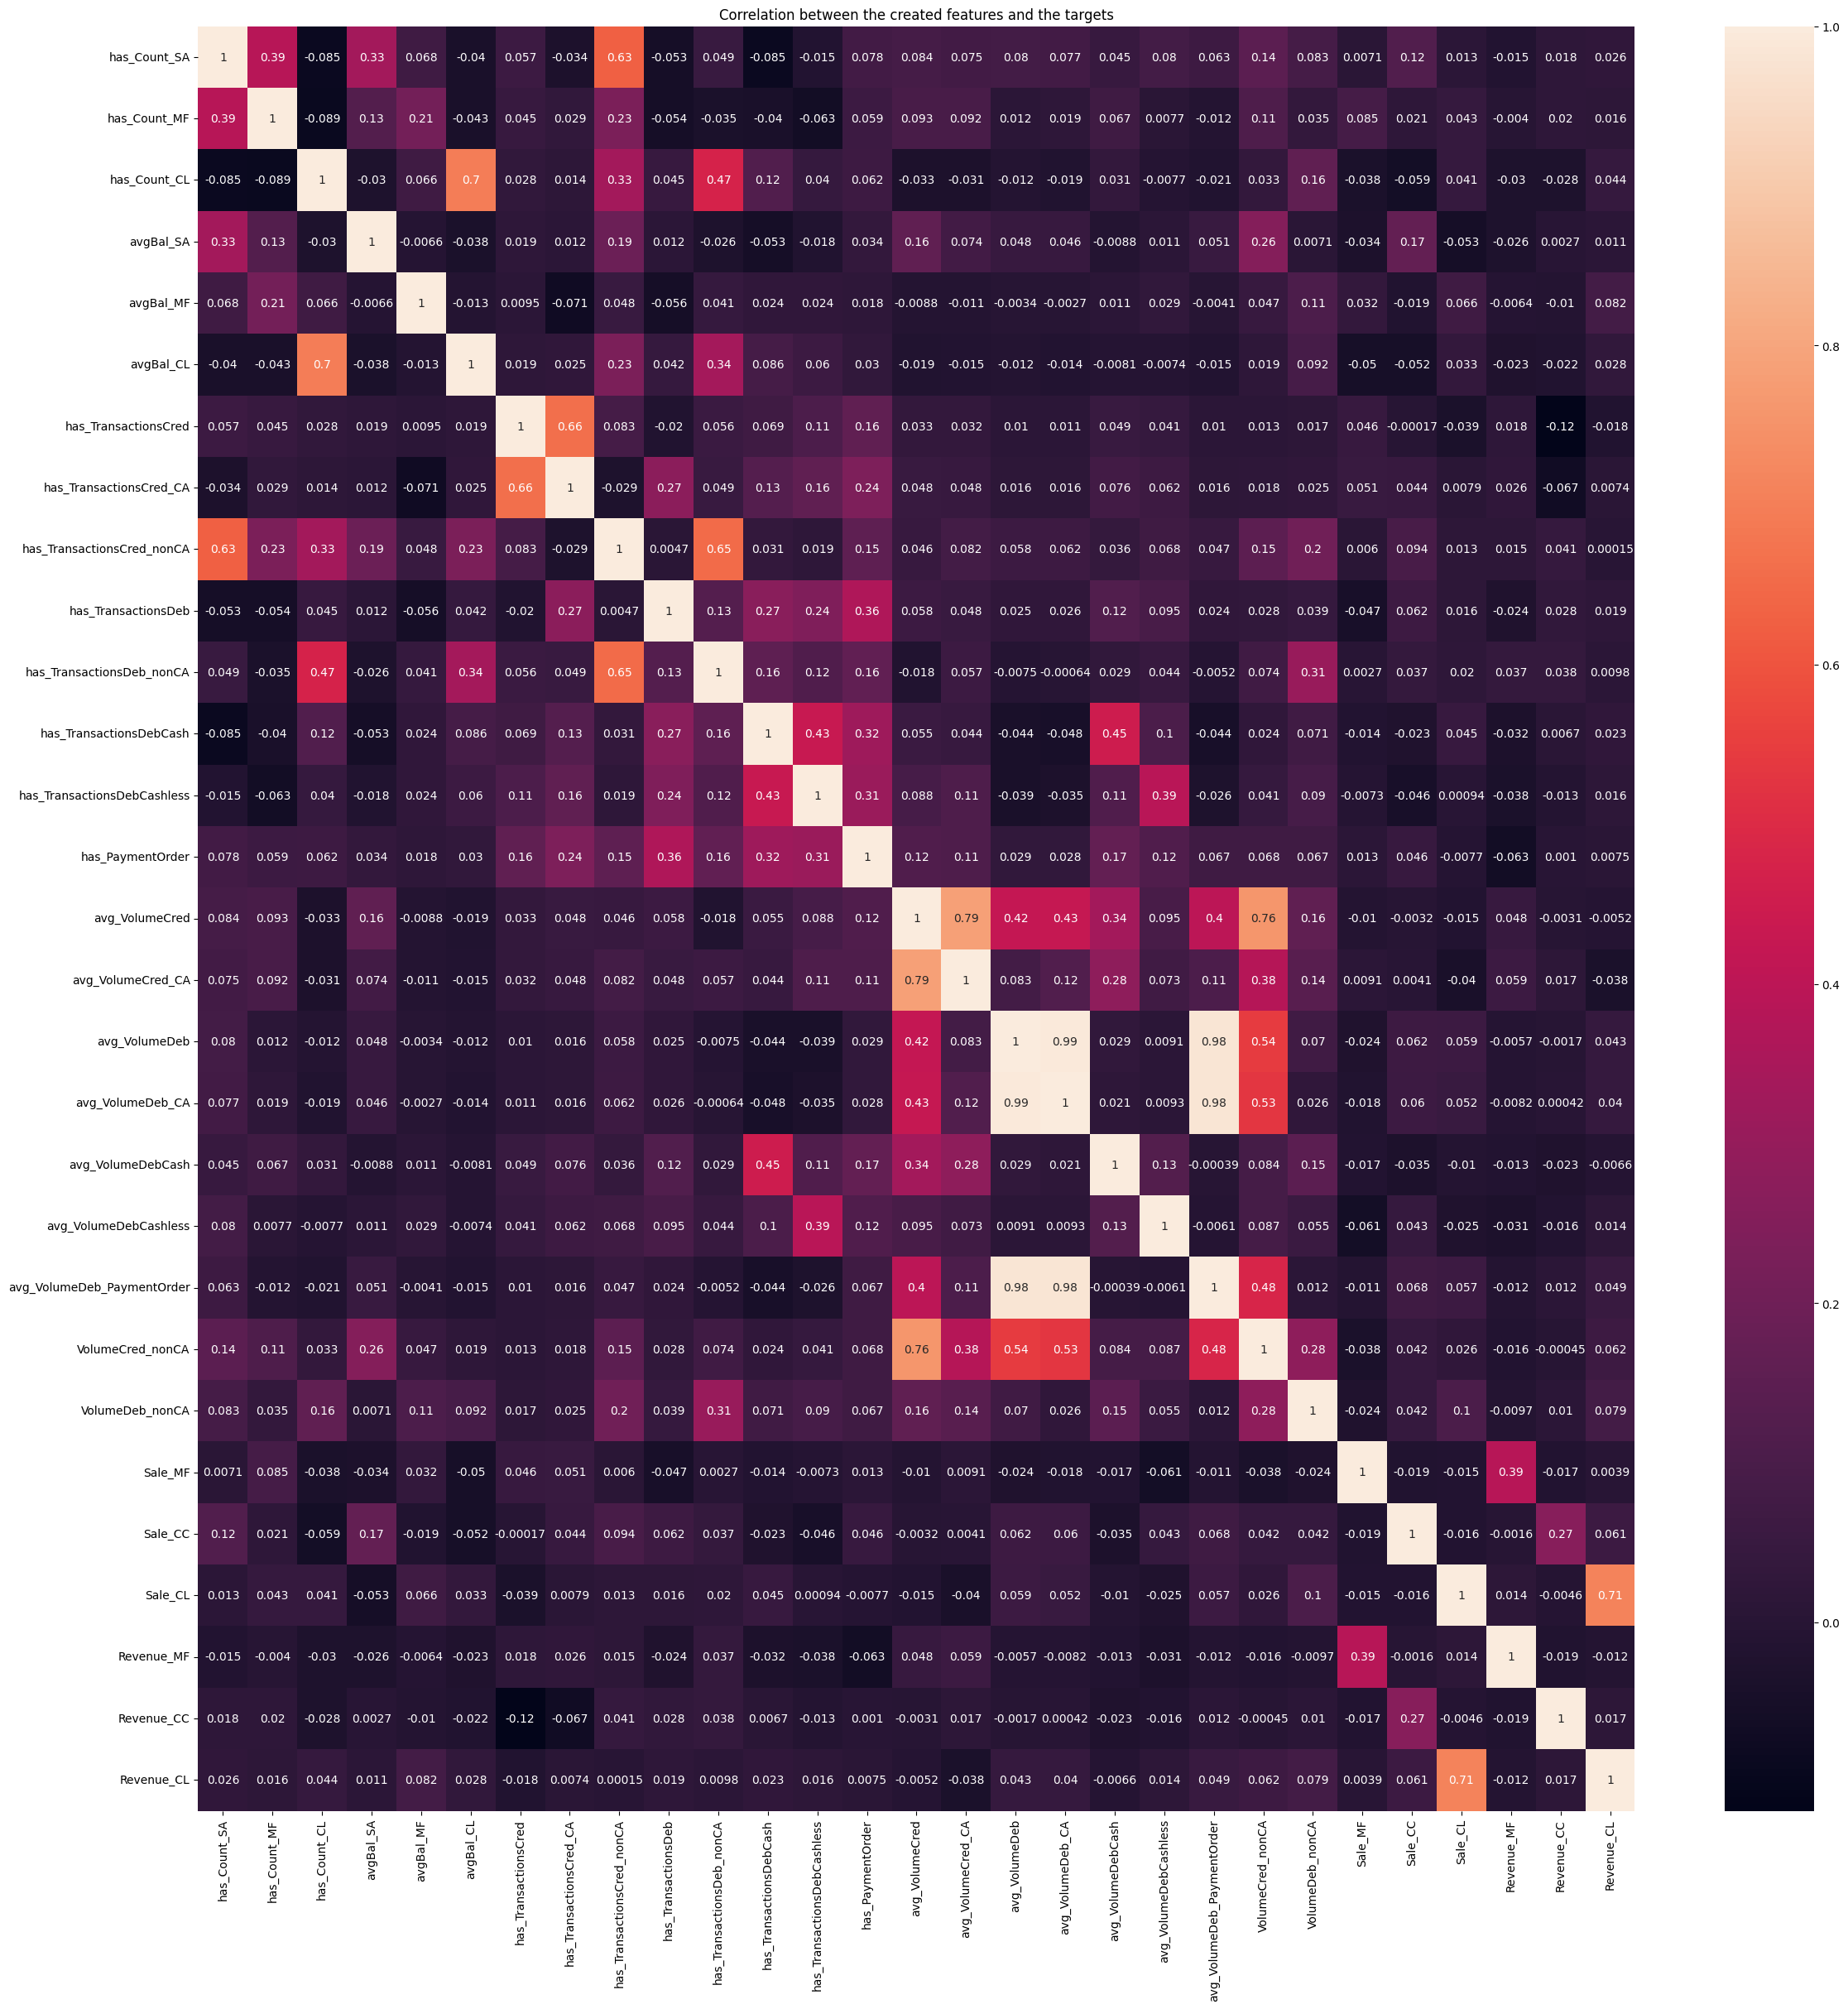

In [60]:
# Investigate the correlation between the created features and the targets

df_new_features = df_modeling_enriched.drop(['Client',
                             'Sex_M',
                             'Age',
                             'Tenure',
                             'Count_CA',
                             'Count_SA',
                             'Count_MF',
                             'Count_OVD',
                             'Count_CC',
                             'Count_CL',
                             'ActBal_CA',
                             'ActBal_SA',
                             'ActBal_MF',
                             'ActBal_OVD',
                             'ActBal_CC',
                             'ActBal_CL',
                             'VolumeCred',
                             'VolumeCred_CA',
                             'TransactionsCred',
                             'TransactionsCred_CA',
                             'VolumeDeb',
                             'VolumeDeb_CA',
                             'VolumeDebCash_Card',
                             'VolumeDebCashless_Card',
                             'VolumeDeb_PaymentOrder',
                             'TransactionsDeb',
                             'TransactionsDeb_CA',
                             'TransactionsDebCash_Card',
                             'TransactionsDebCashless_Card',
                             'TransactionsDeb_PaymentOrder',], axis=1).astype('float32')
                             
corr = df_new_features.corr()
fig, ax = plt.subplots(figsize=(28, 28))
g = sns.heatmap(corr, ax=ax, annot=True)
ax.set_title("Correlation between the created features and the targets")
                             

#### <span style="color:orange">**Feature Correlation Insights**</span>

This section summarizes the results of the correlation analysis between features and target variables, as well as among features themselves.

---

#### 🔍 Correlation with Target Variables

- Most **original and engineered features** show **low correlation** with the target variables.
- No feature stands out with significantly high or low correlation coefficients across targets.

---

#### 🔁 Inter-Feature Correlation

- No numerical features exhibit **perfect or near-perfect multicollinearity** with others.
- This indicates a **low risk of redundancy** among features due to linear relationships.

---

#### ✅ Decision Based on Correlation Analysis

- **No features will be removed** at this stage based on correlation alone.
- All original and created features will be retained for modeling, as they may still contribute to predictive performance in nonlinear models.

### Analyzing and handling Skewness in Feature Value Distribution

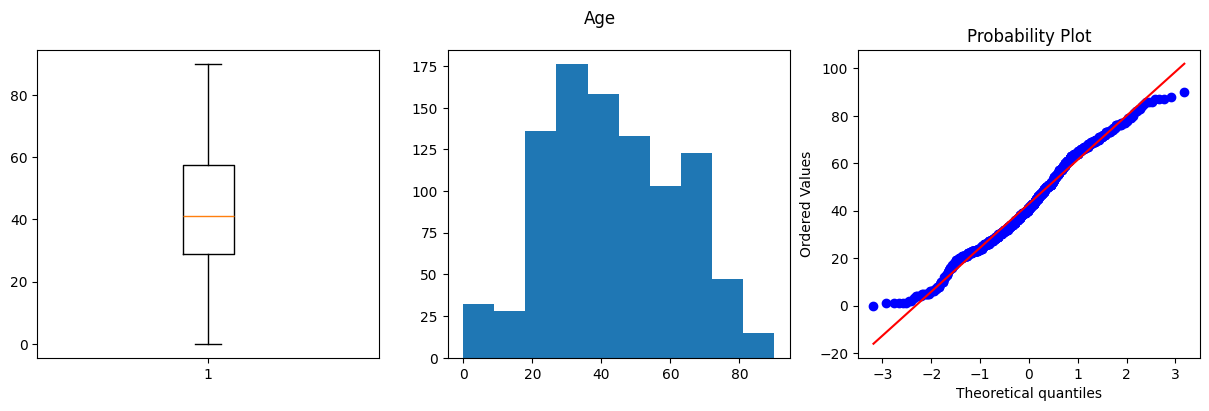

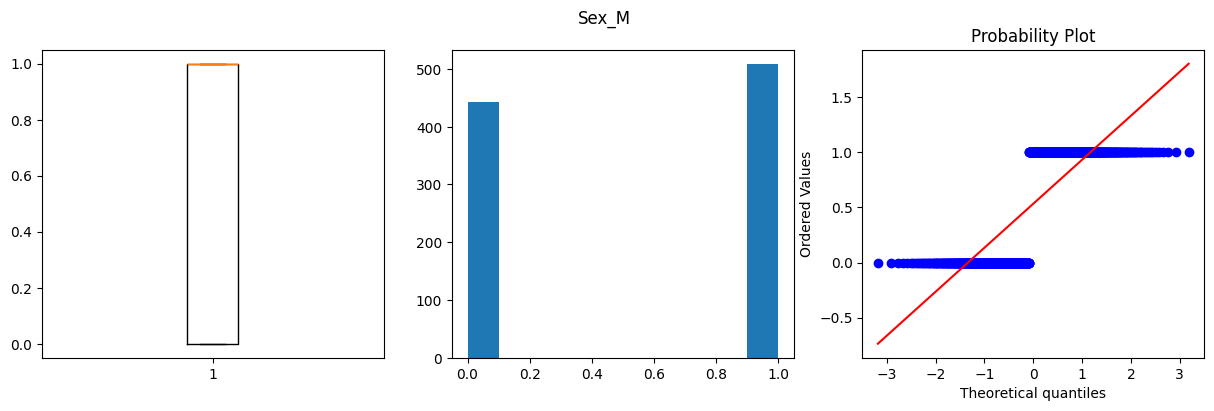

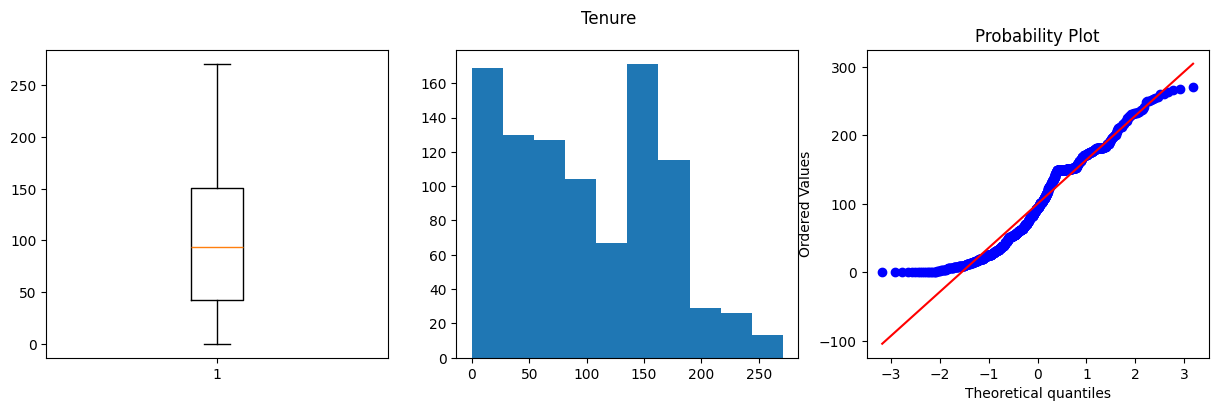

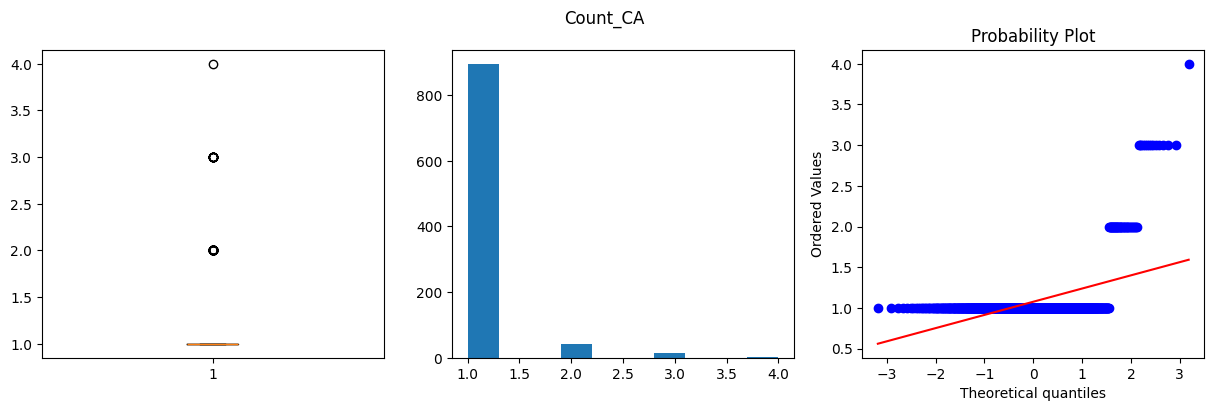

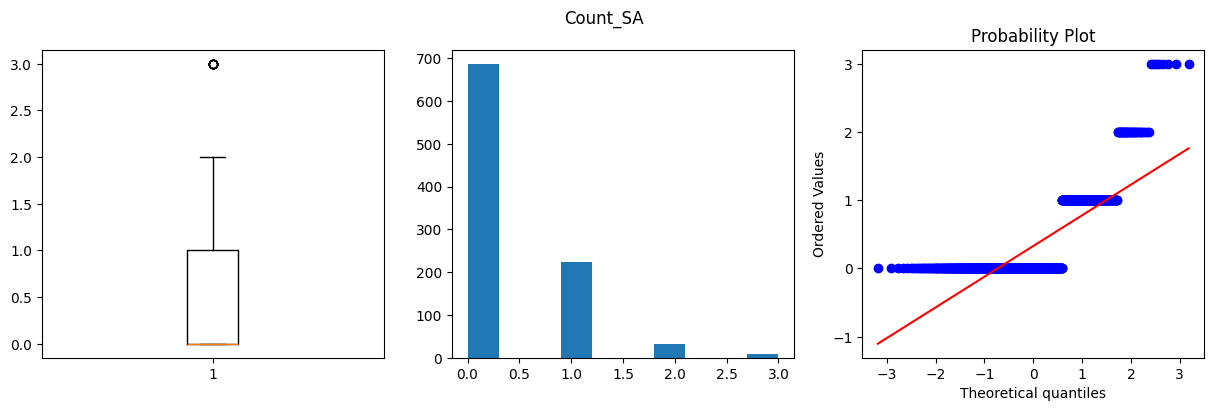

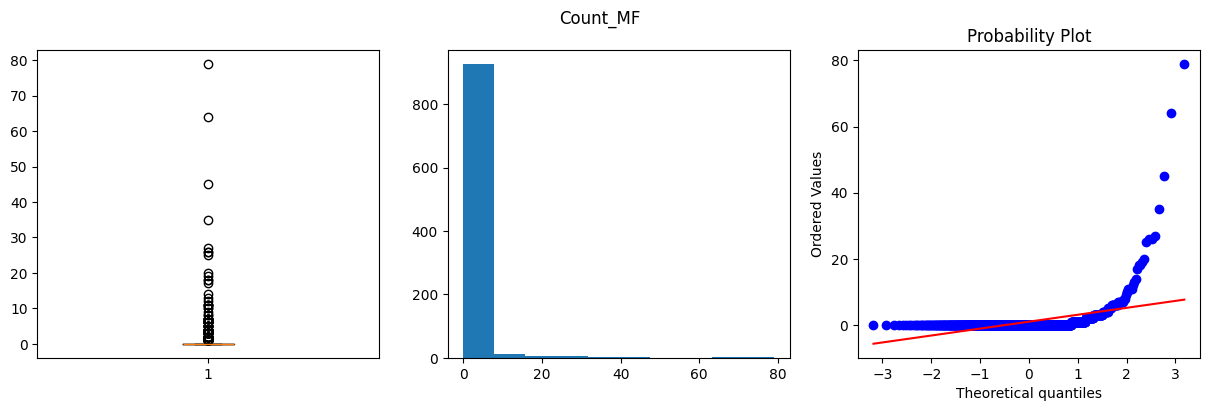

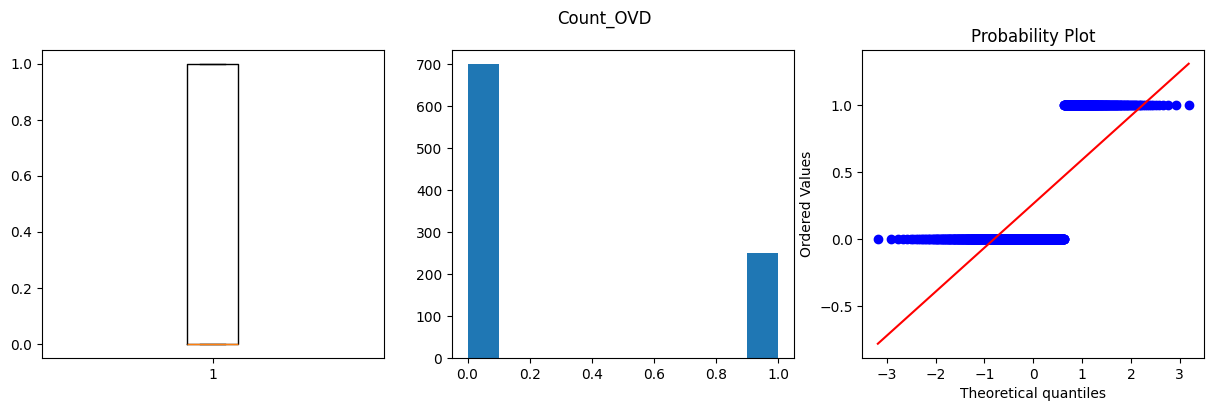

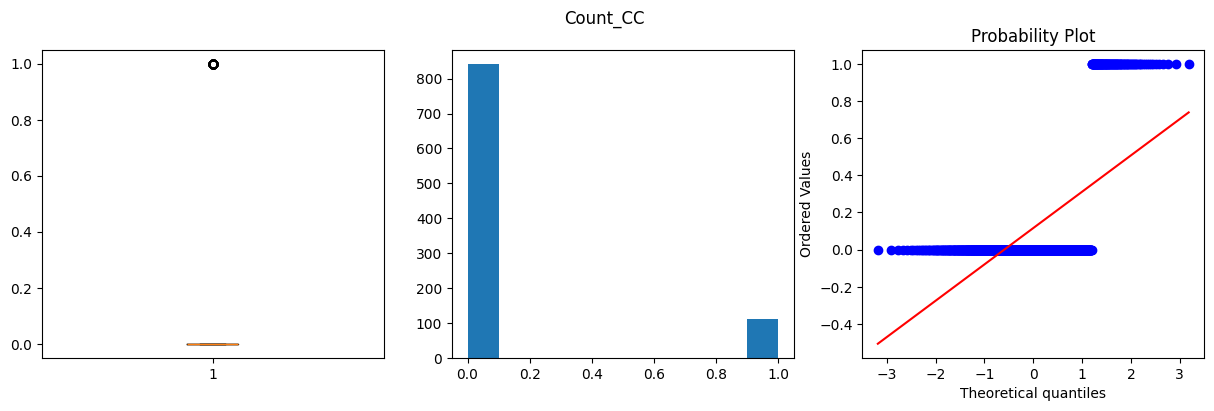

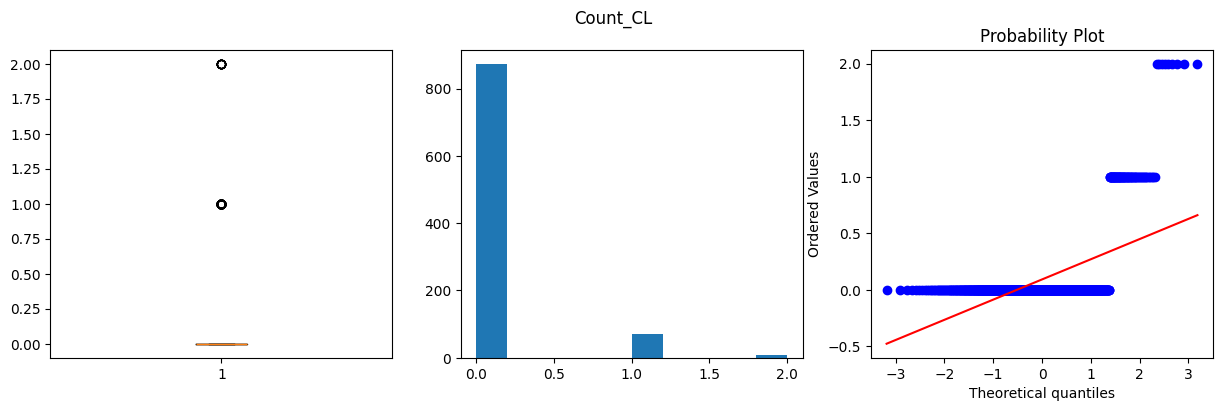

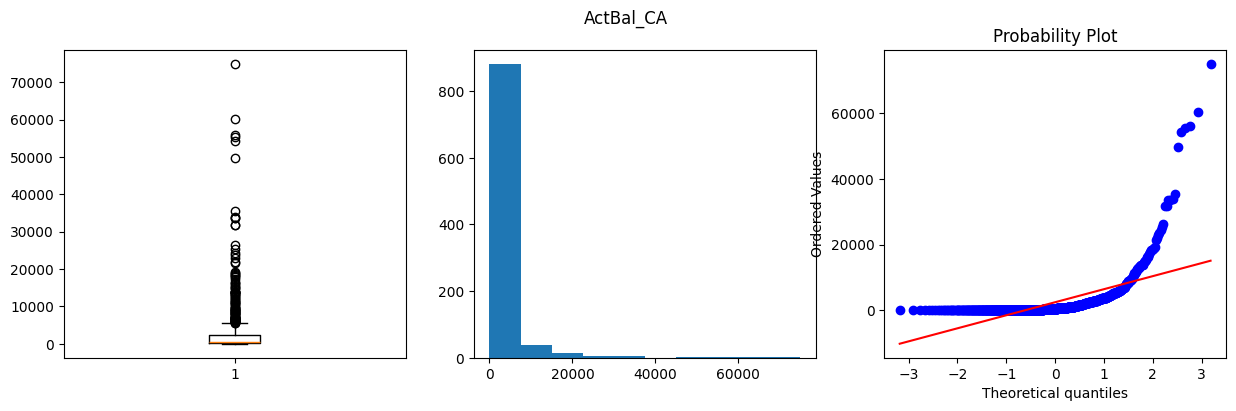

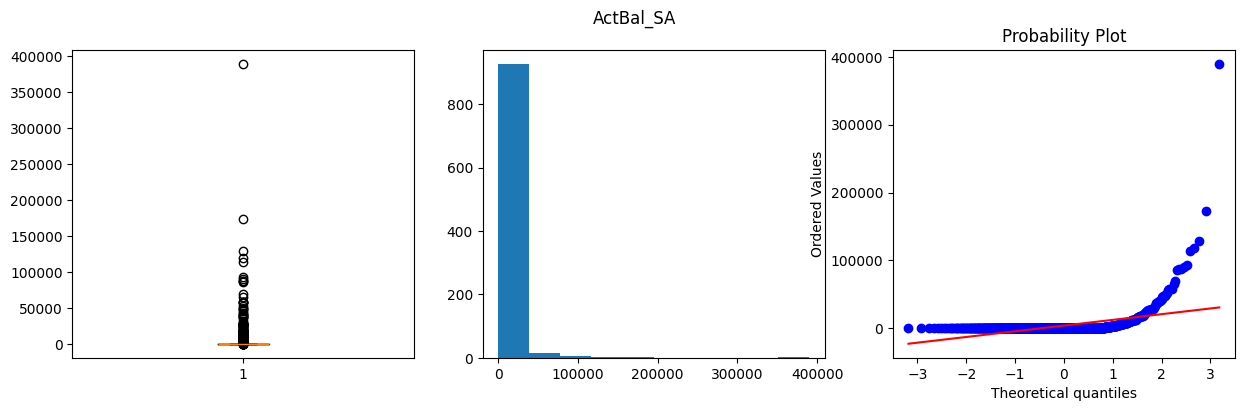

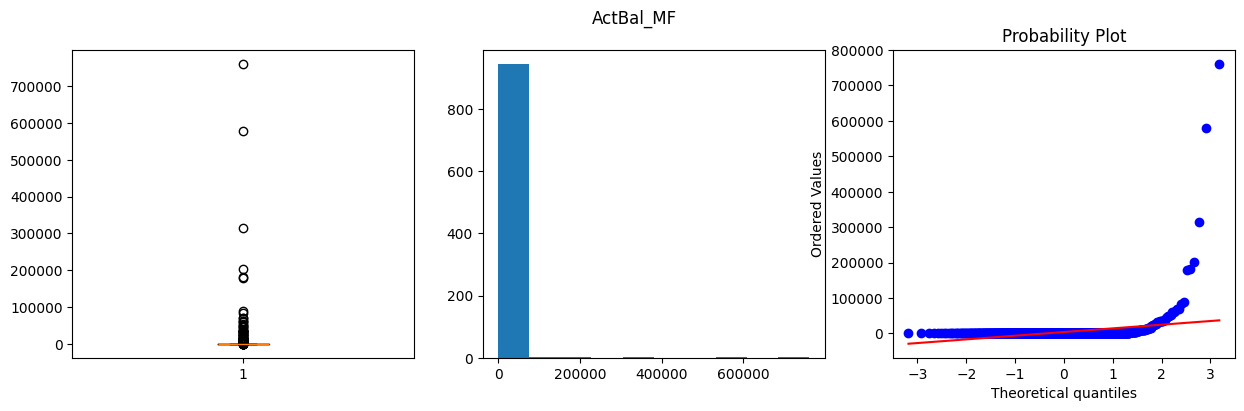

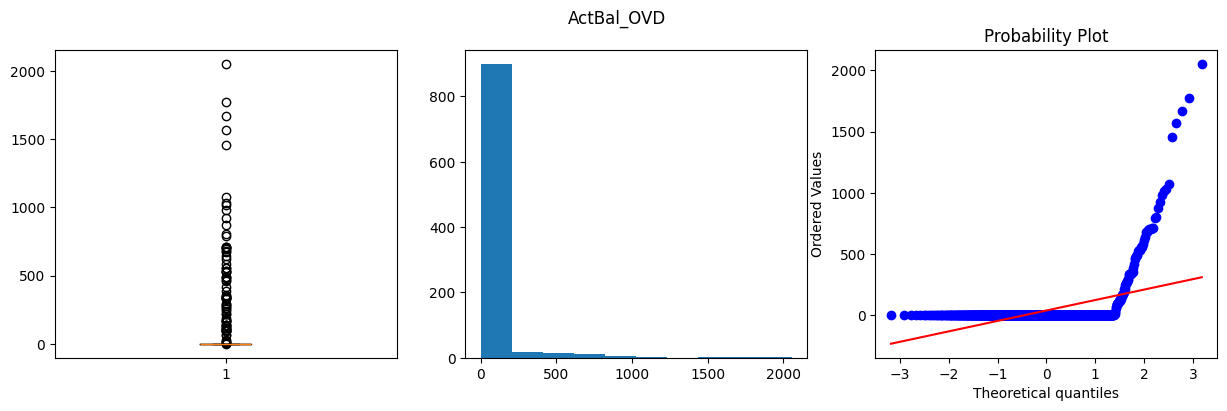

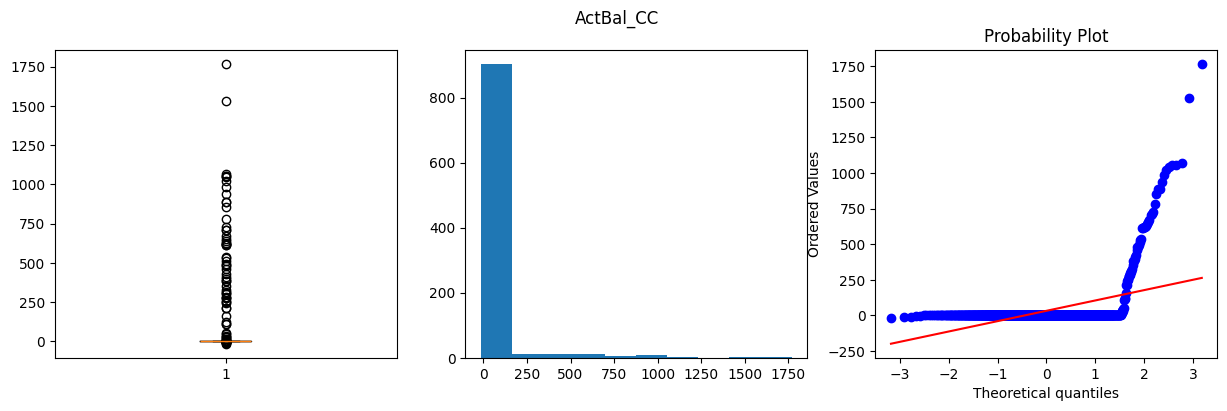

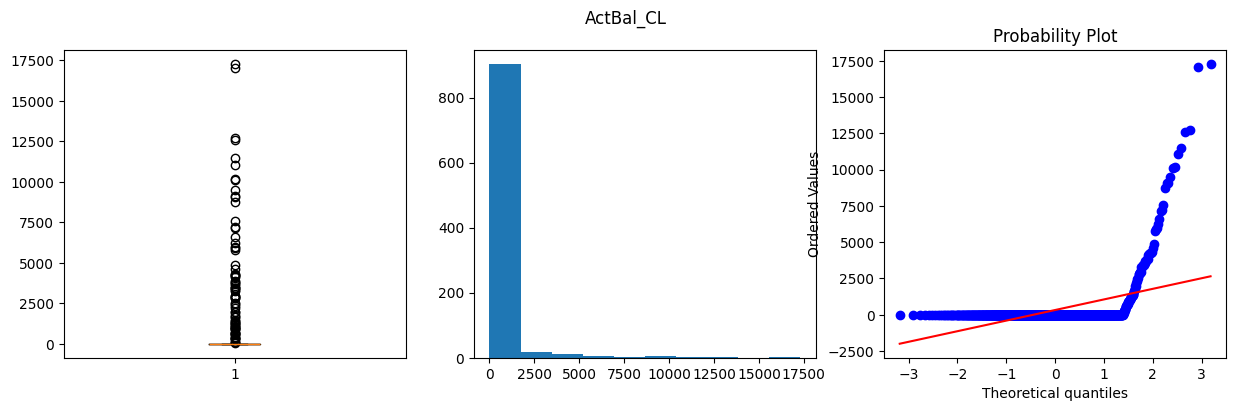

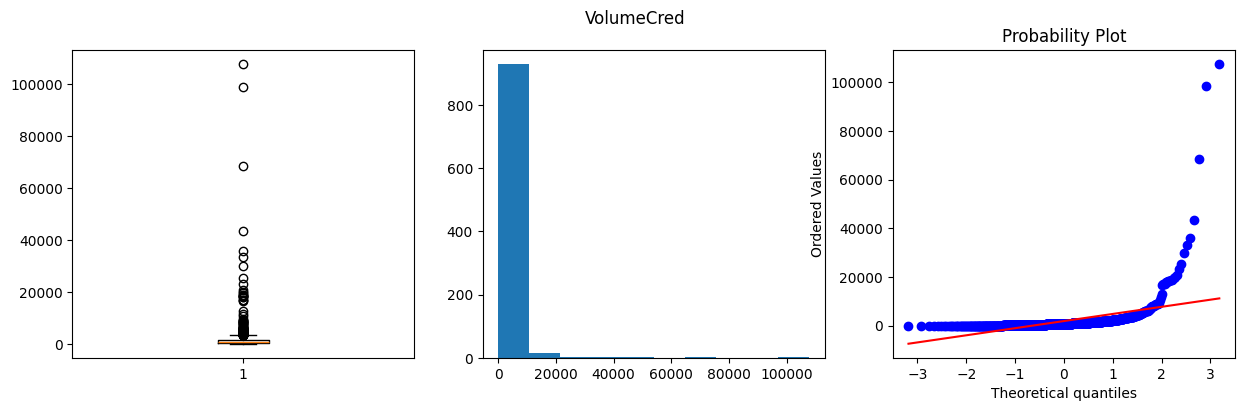

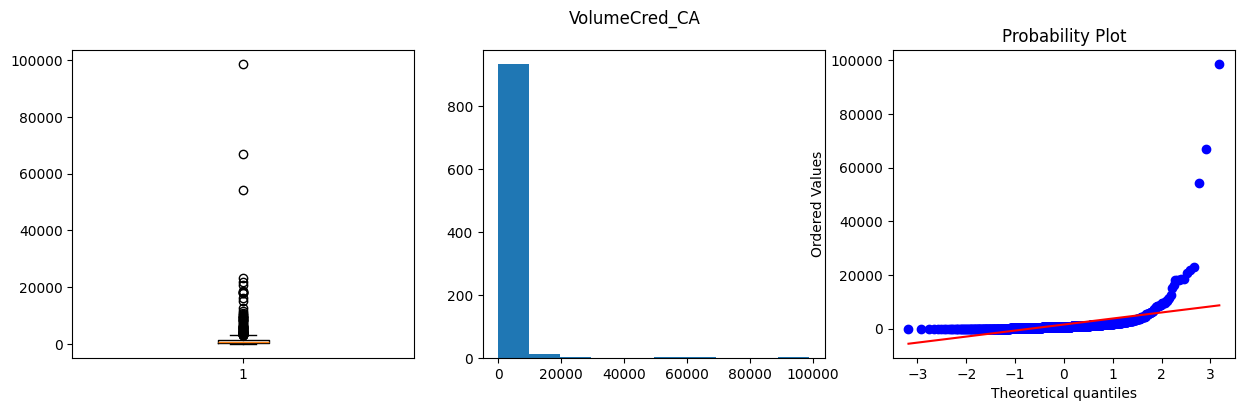

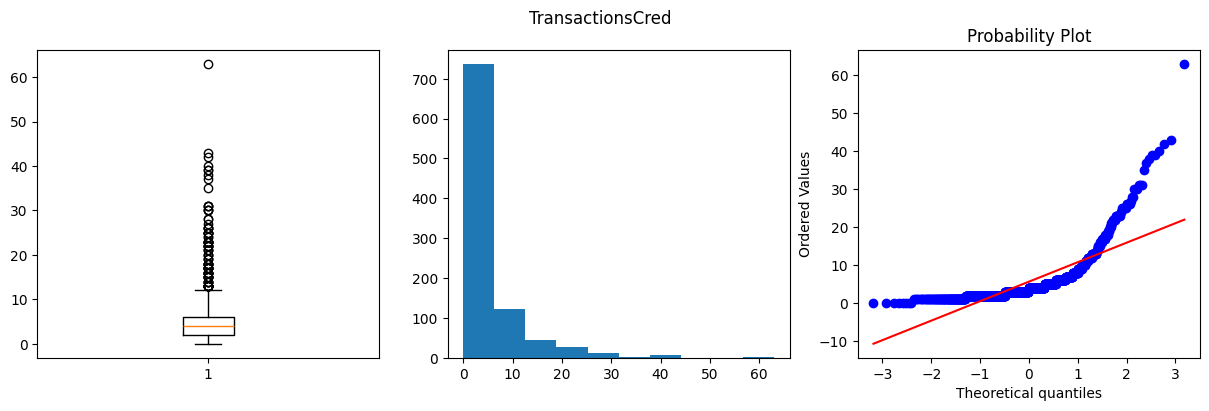

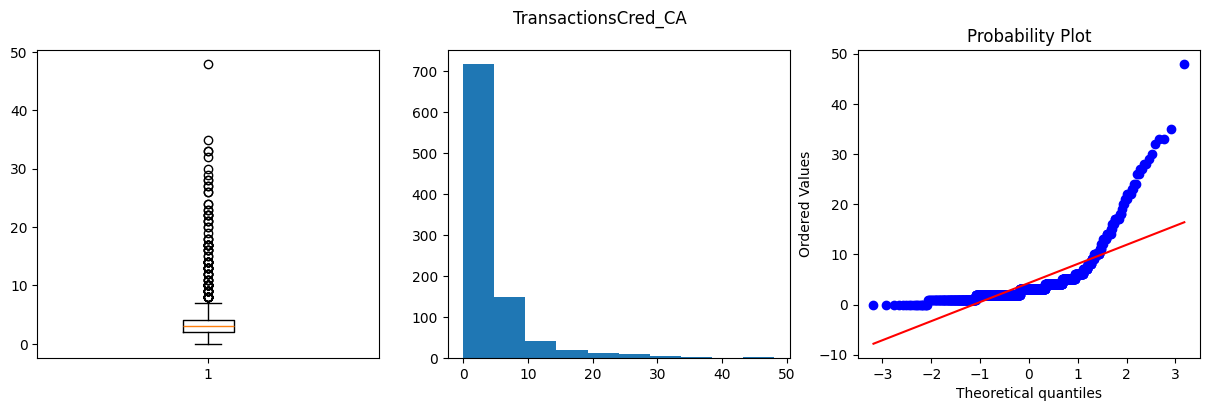

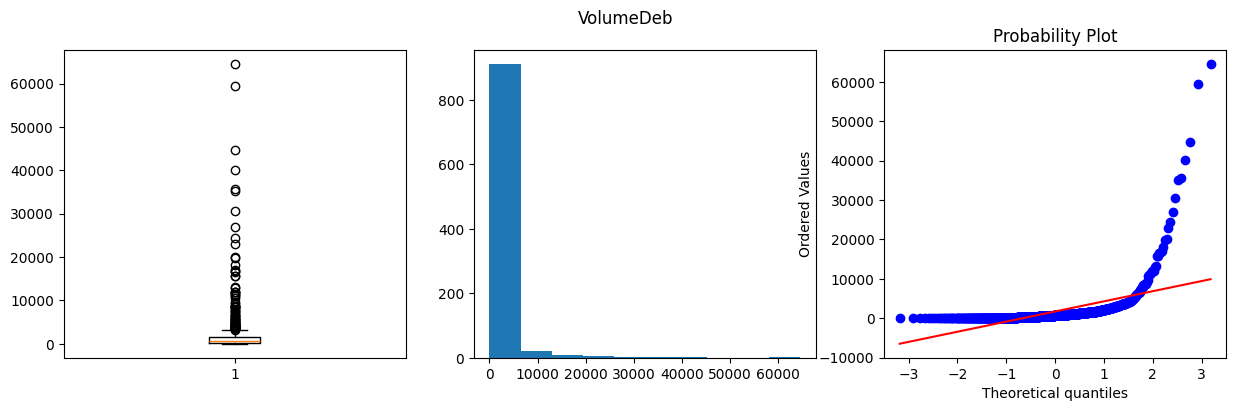

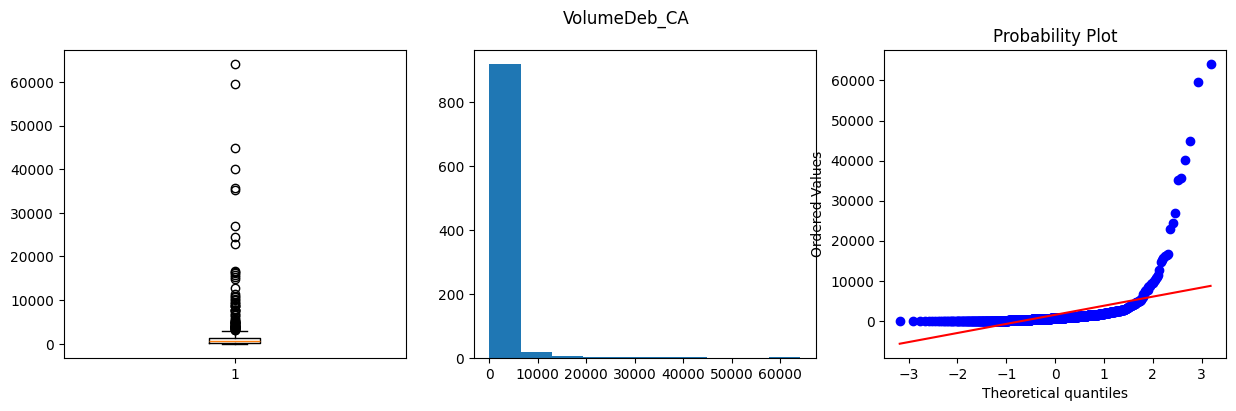

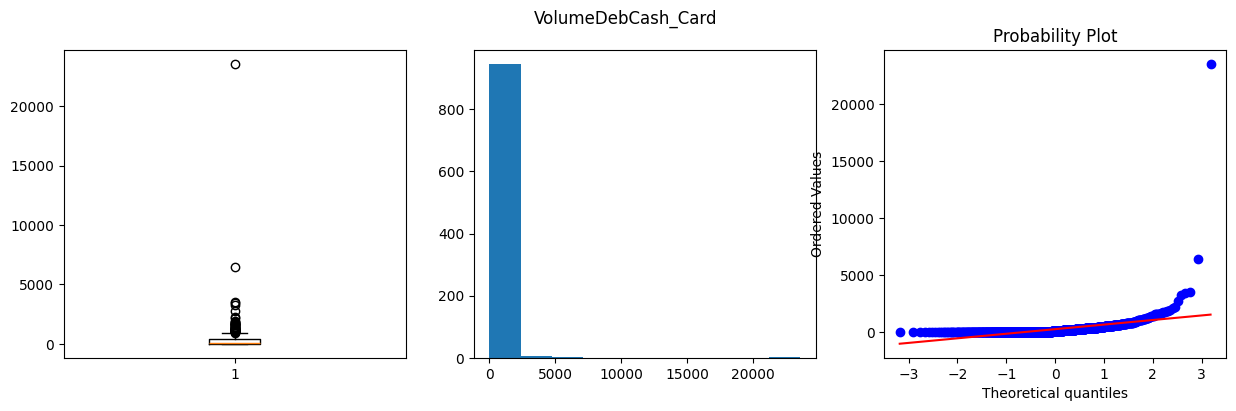

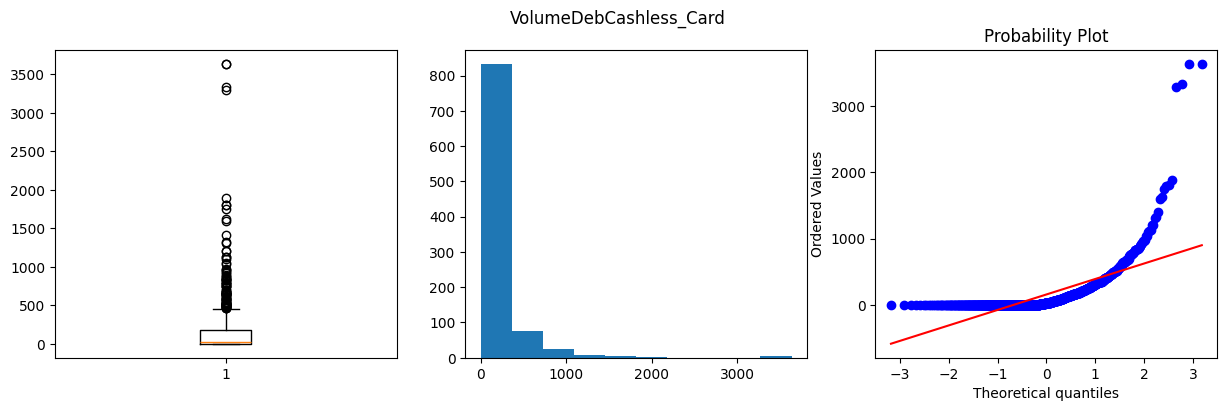

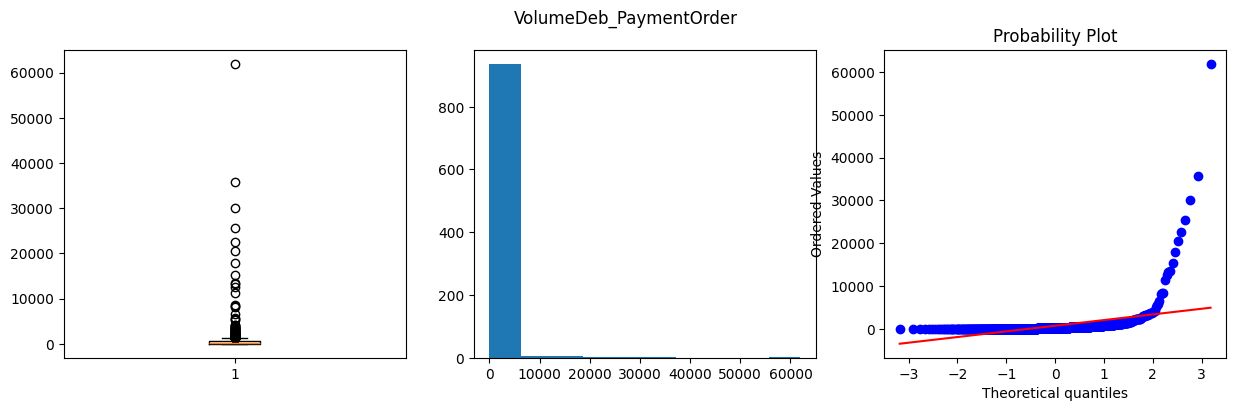

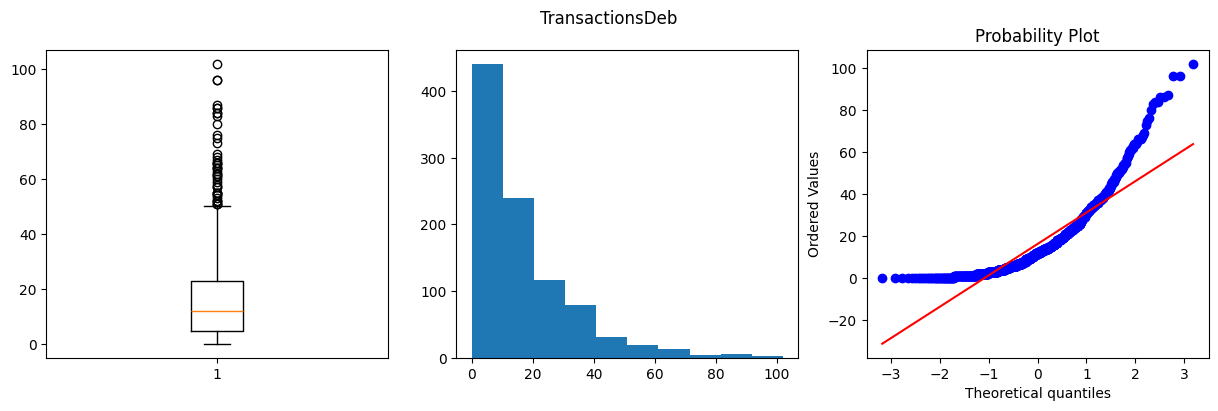

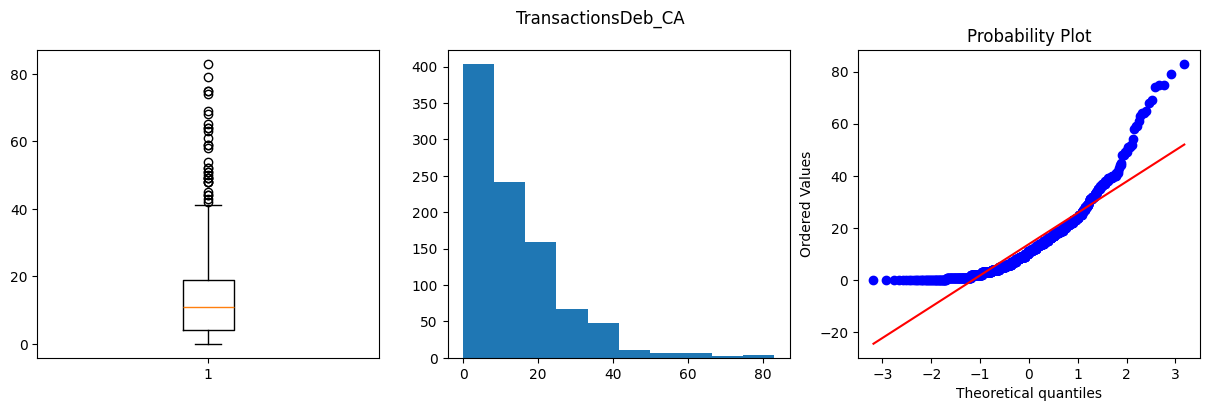

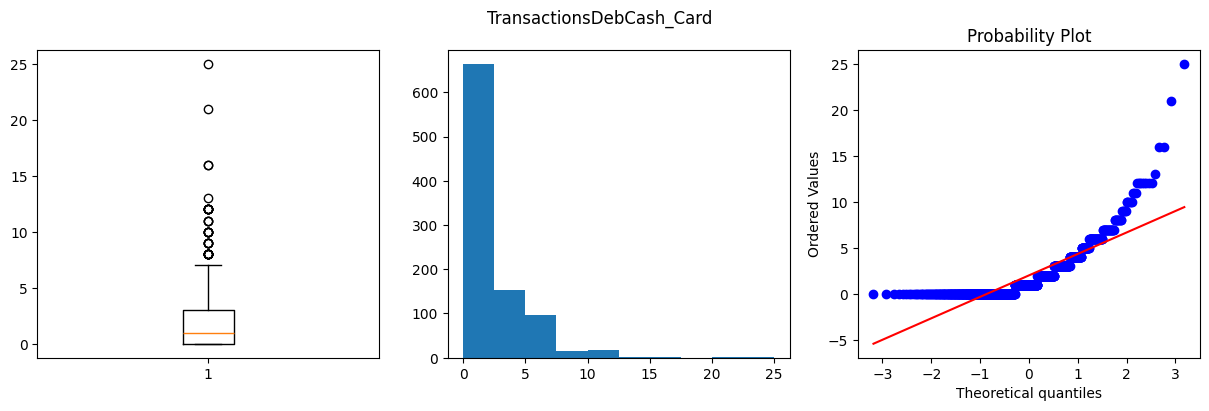

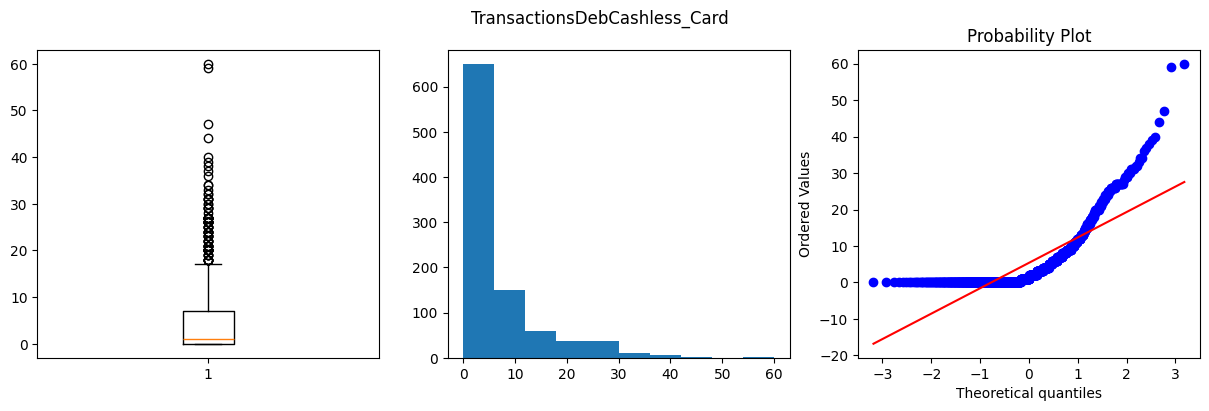

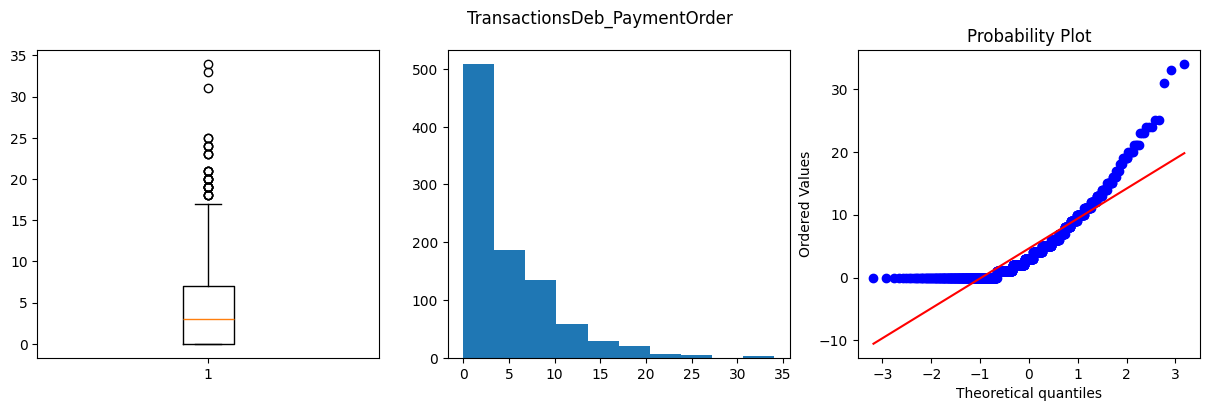

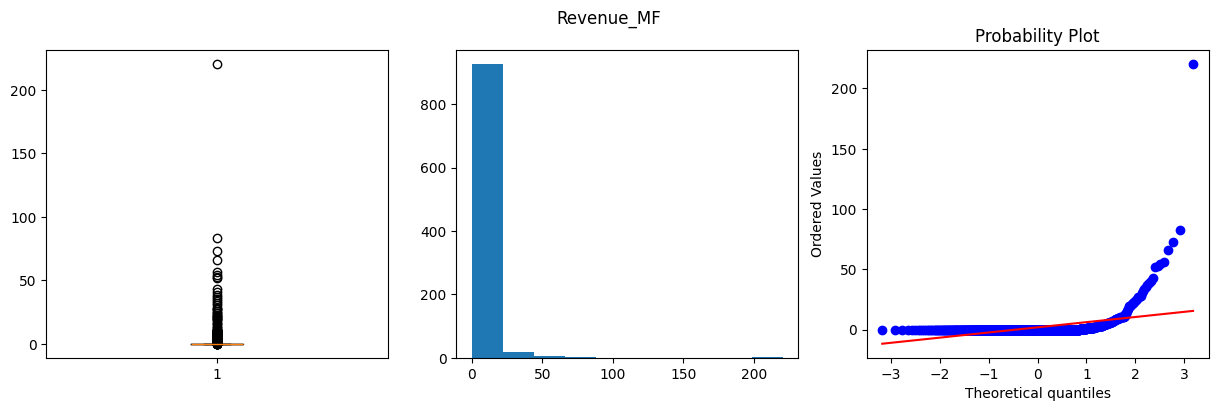

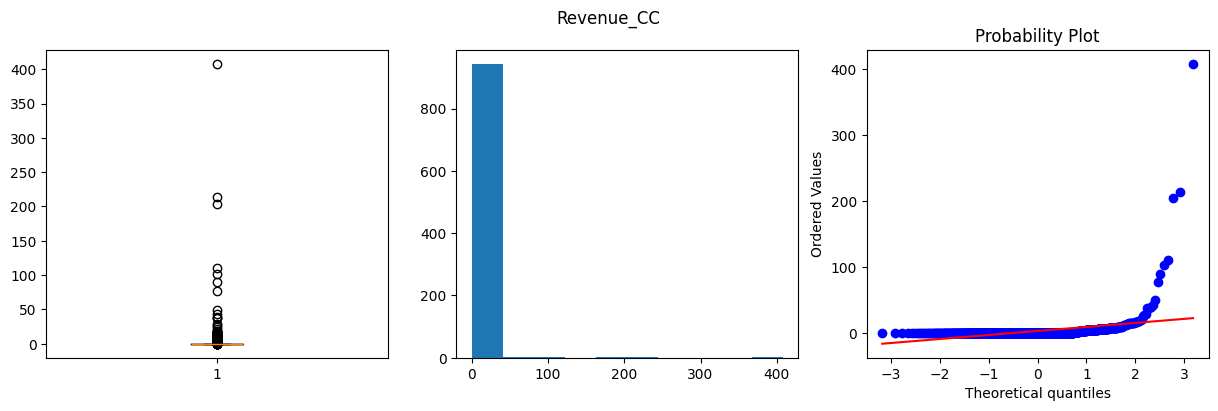

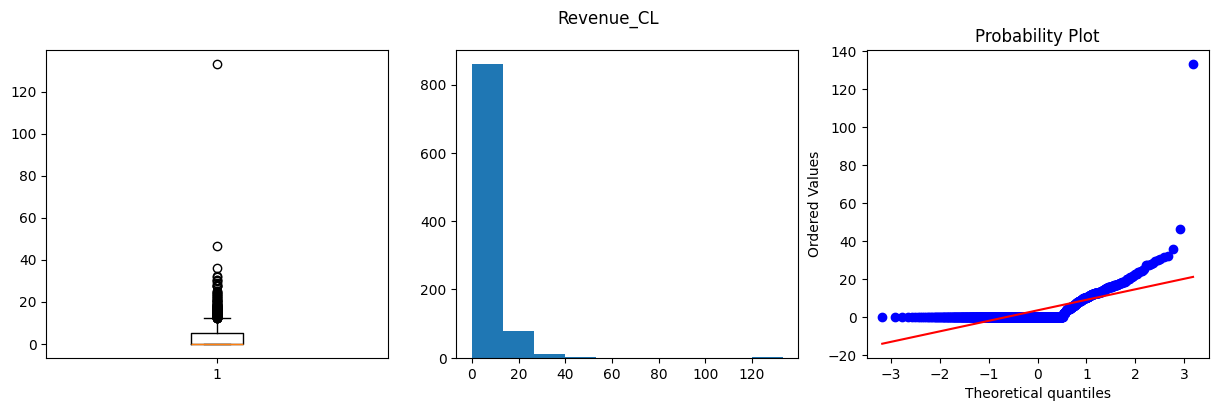

In [62]:
import scipy.stats as stats

cols = [ 'Age',
         'Sex_M',
         'Tenure',
         'Count_CA',
         'Count_SA',
         'Count_MF',
         'Count_OVD',
         'Count_CC',
         'Count_CL',
         'ActBal_CA',
         'ActBal_SA',
         'ActBal_MF',
         'ActBal_OVD',
         'ActBal_CC',
         'ActBal_CL',
         'VolumeCred',
         'VolumeCred_CA',
         'TransactionsCred',
         'TransactionsCred_CA',
         'VolumeDeb',
         'VolumeDeb_CA',
         'VolumeDebCash_Card',
         'VolumeDebCashless_Card',
         'VolumeDeb_PaymentOrder',
         'TransactionsDeb',
         'TransactionsDeb_CA',
         'TransactionsDebCash_Card',
         'TransactionsDebCashless_Card',
         'TransactionsDeb_PaymentOrder',
         'Revenue_MF',
         'Revenue_CC',
         'Revenue_CL',]

for col in cols: 
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    fig.suptitle(col)
    axes[0].boxplot(df_numeric[col])
    axes[1].hist(df_numeric[col])
    stats.probplot(df_numeric[col], dist='norm', plot=axes[2])
    plt.show()

### <span style="color:orange">**Feature Distribution and Skewness Analysis**</span>

This section highlights key insights into the distribution shapes of numerical and categorical variables and outlines the data transformation strategy.

---

#### 📊 Observations on Feature Skewness

- **Near-Normal Distributions**:
  - `'Age'`, `'Sex_M'`, and `'Tenure'` exhibit nearly symmetric, unskewed distributions.

- **Discrete Count Features**:
  - Features like `'Count_CA'`, `'Count_SA'`, `'Count_MF'`, `'Count_OVD'`, `'Count_CC'`, and `'Count_CL'` are **right-skewed**.
  - Except for `'Count_MF'`, these features have **small value ranges**, reducing the urgency for transformation.
  - `'Count_MF'` stands out with a **wider range** (0–79), warranting transformation.

- **Transaction and Balance Features**:
  - All **account balance**, **transaction count**, and **volume features** are **significantly right-skewed**.
  - `'ActBal_CC'` has a **negative minimum value**, unlike other features, which are non-negative.

---

#### 🛠️ Planned Data Transformation Strategy

To reduce skewness and approach normality, transformations (e.g., log or quantile) will be applied to the following variables:

- `'Count_MF'`
- All **balance features**
- All **transaction count features**
- All **transaction volume features**
- All **revenue-related columns**

> These transformations aim to enhance model performance, especially for algorithms sensitive to distributional assumptions or scale.


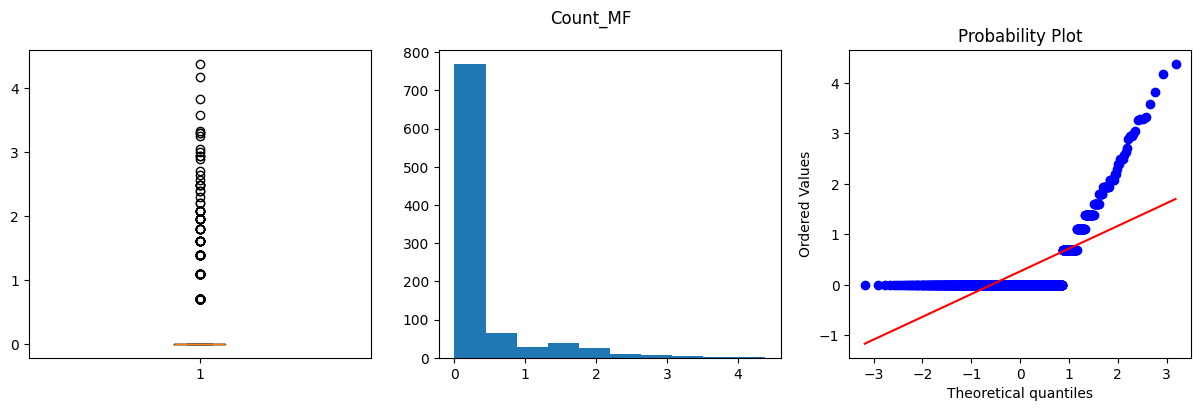

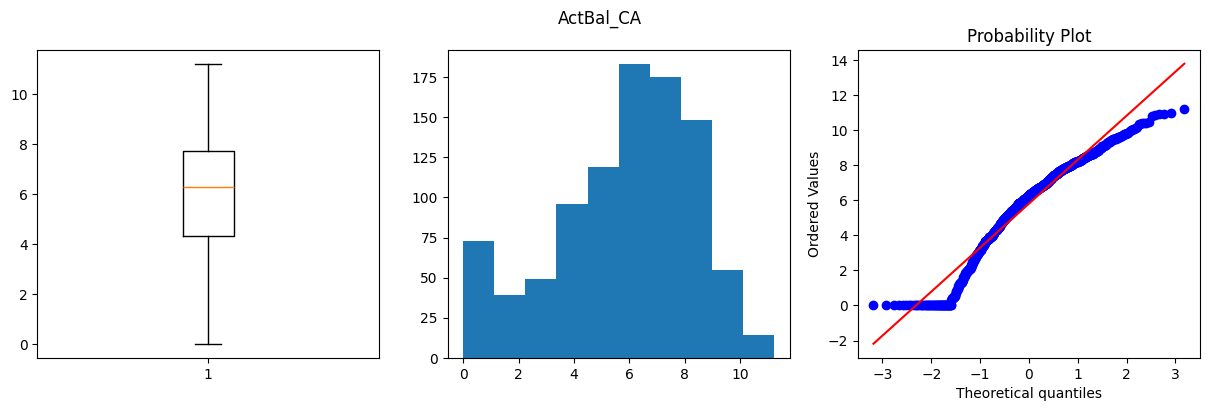

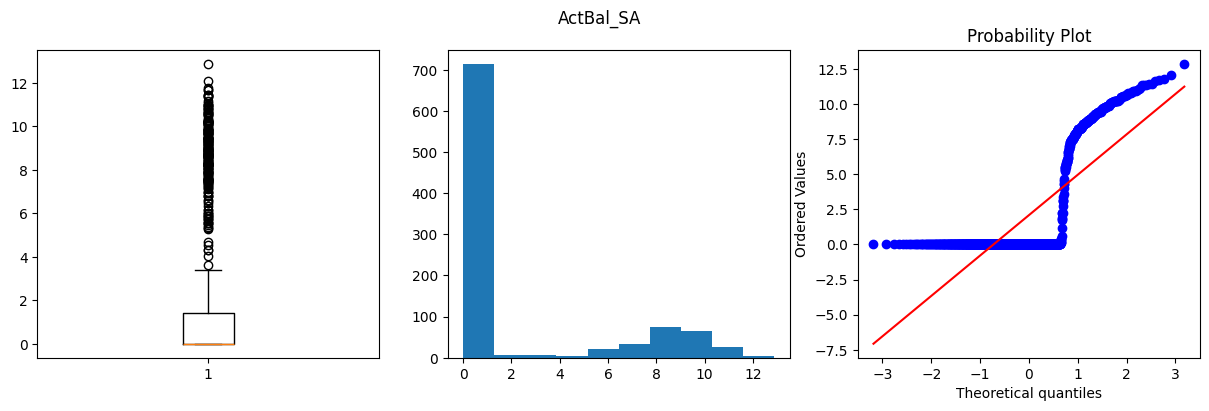

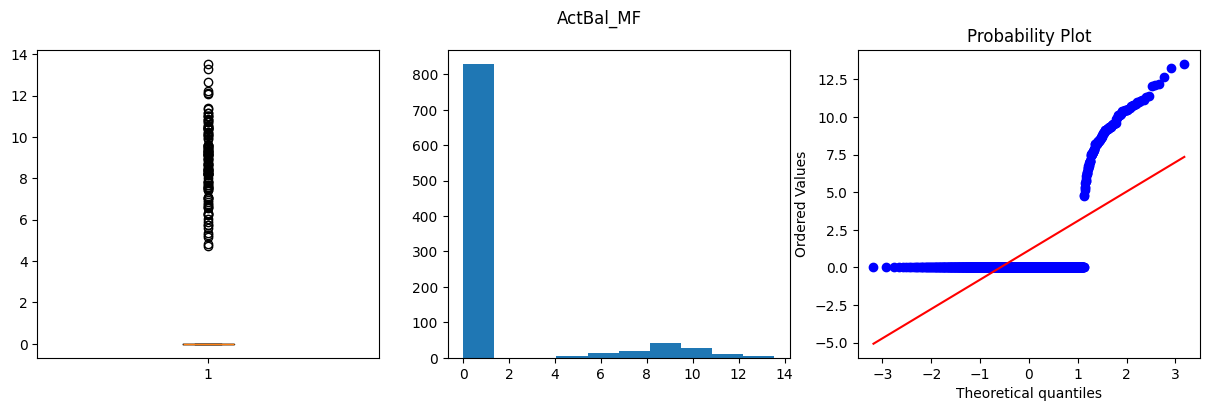

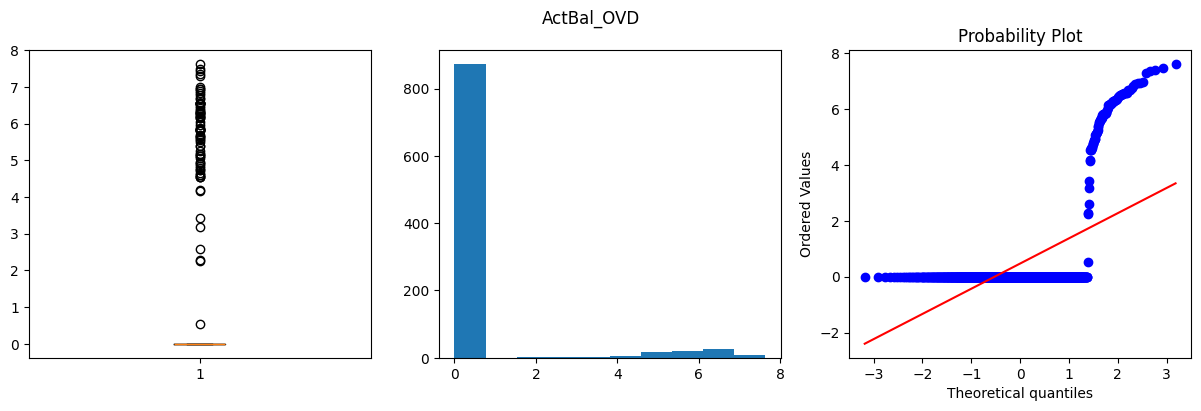

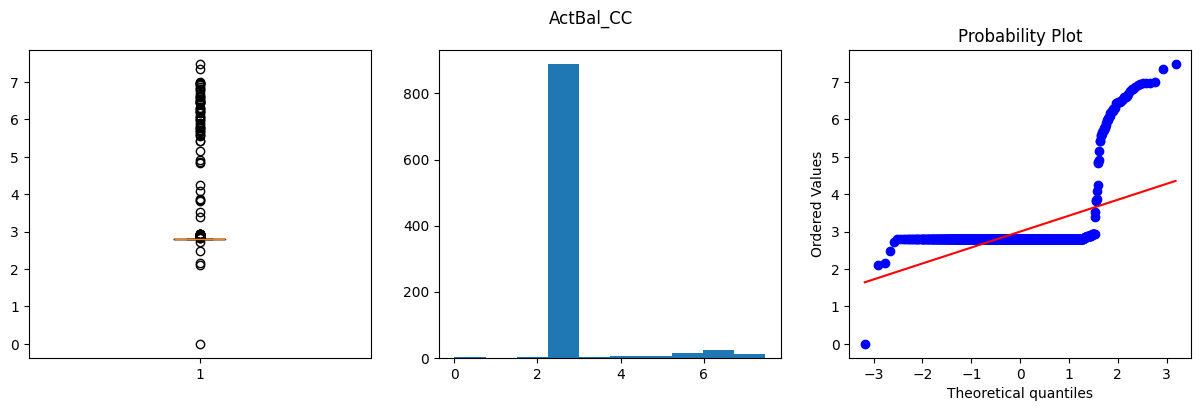

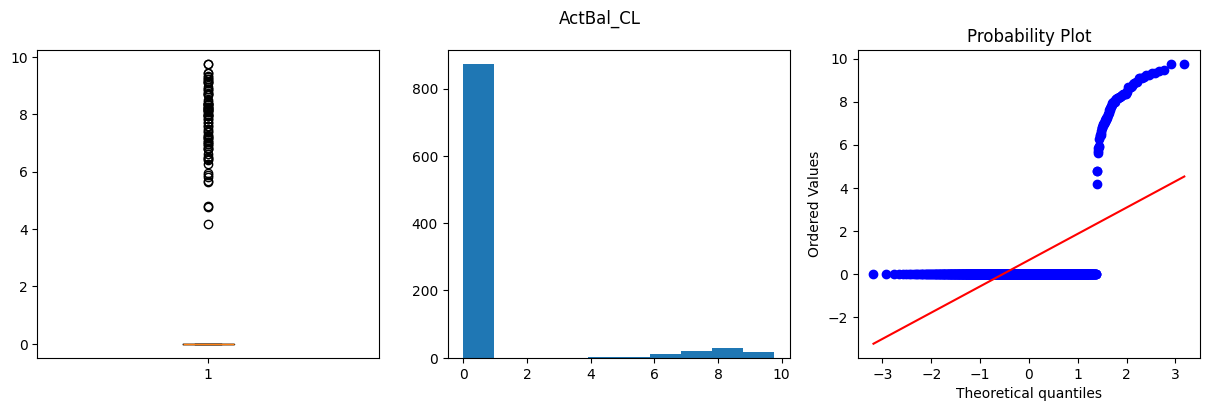

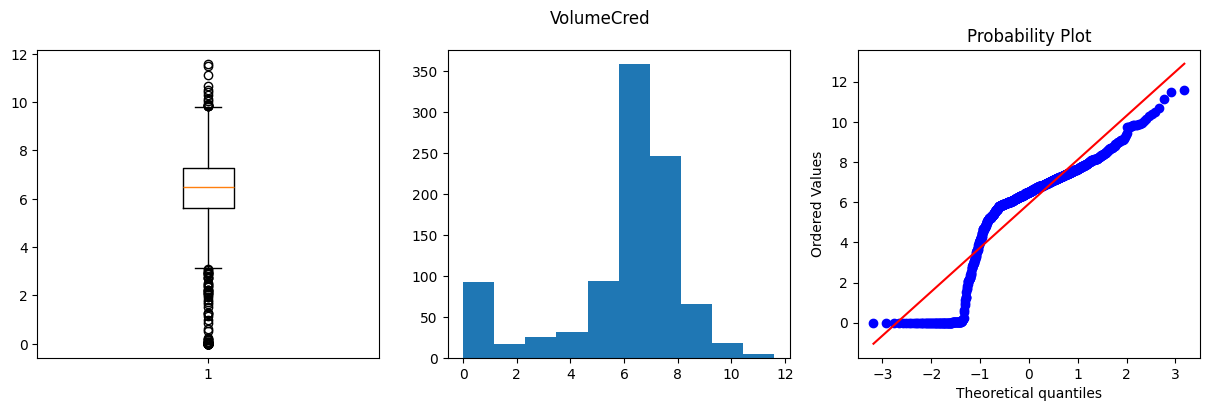

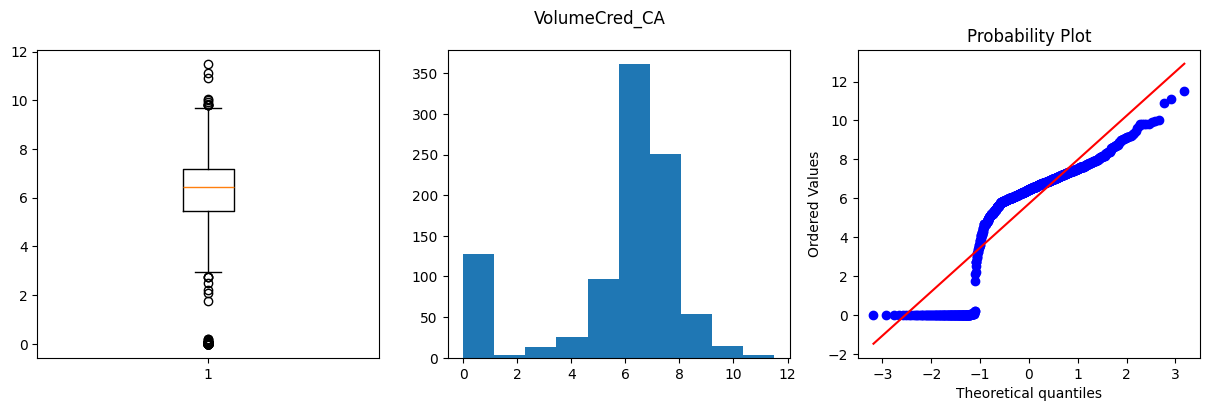

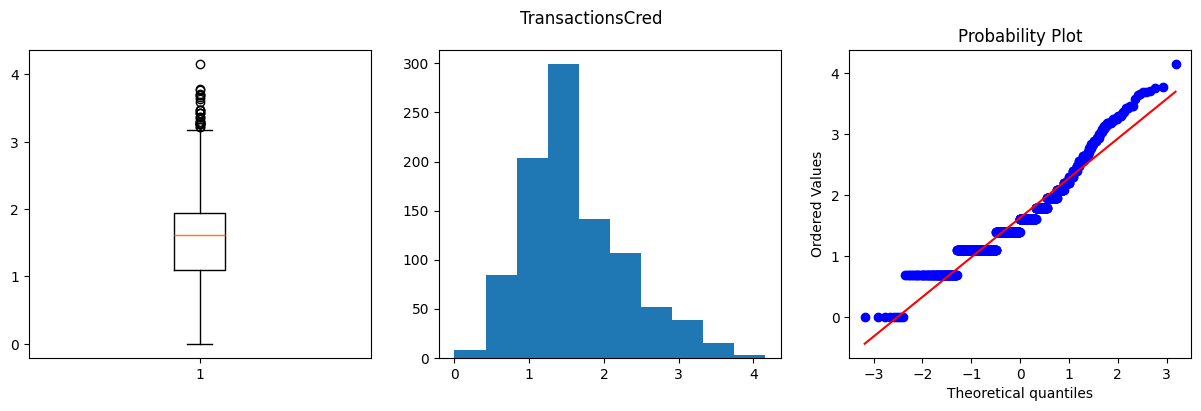

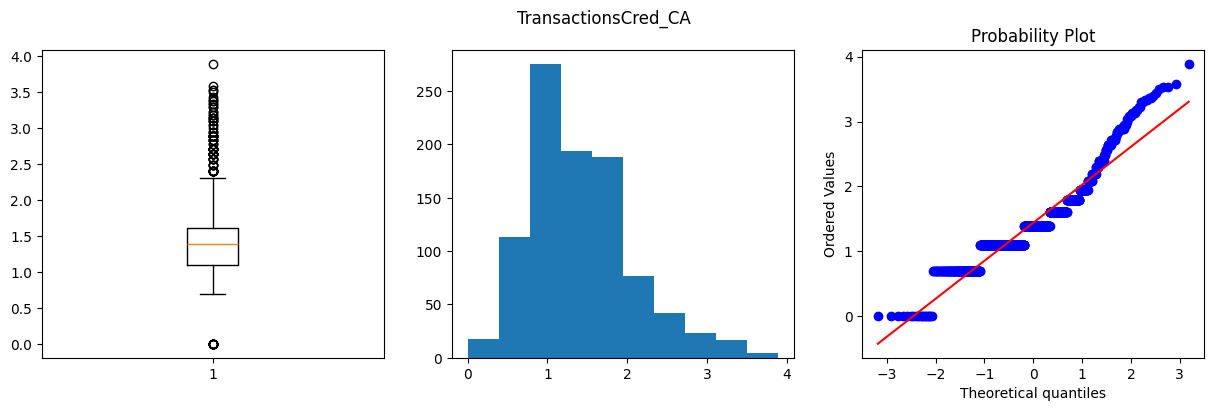

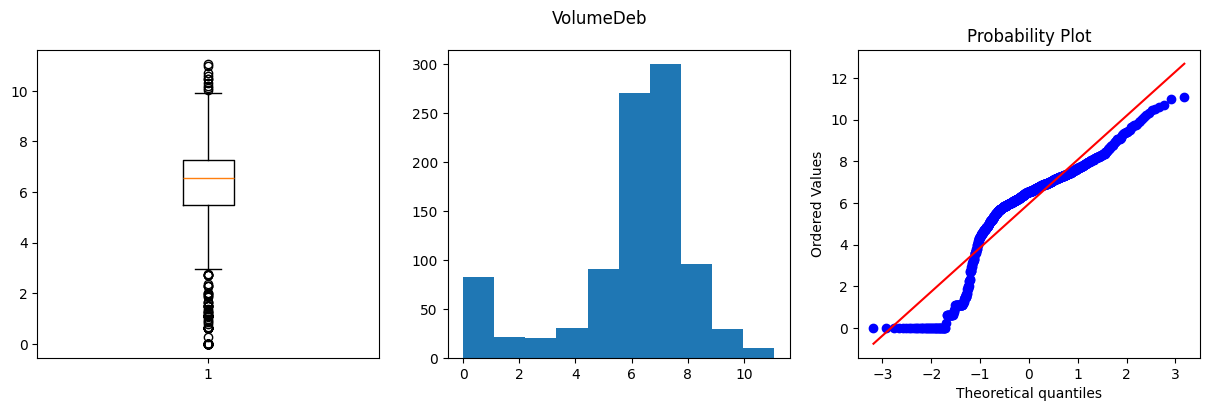

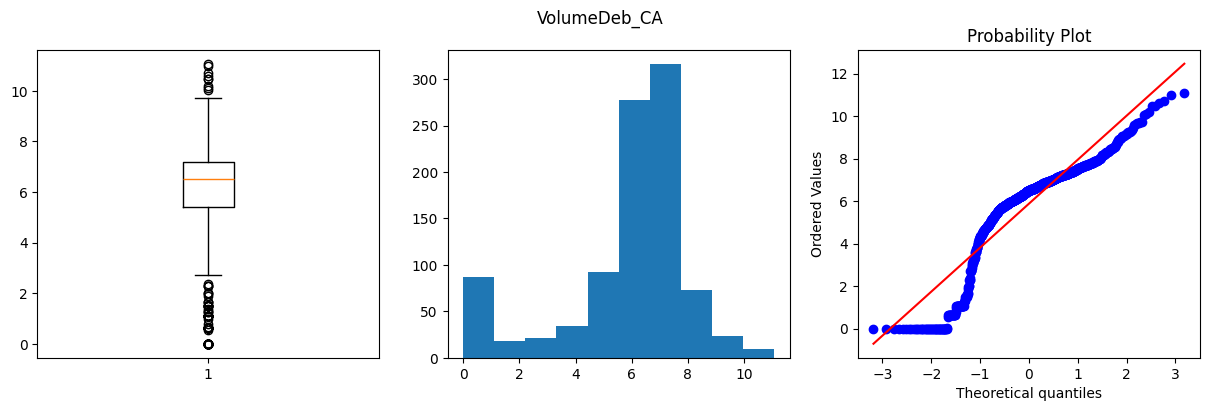

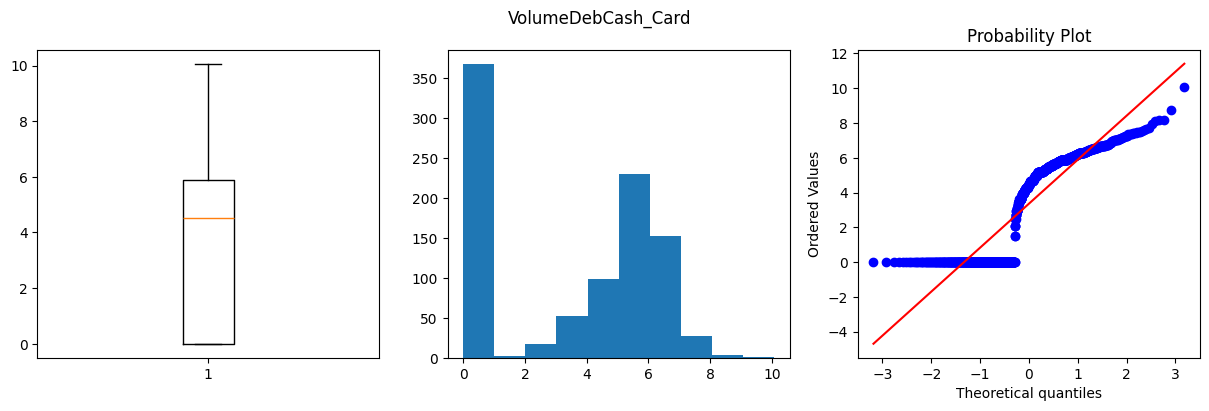

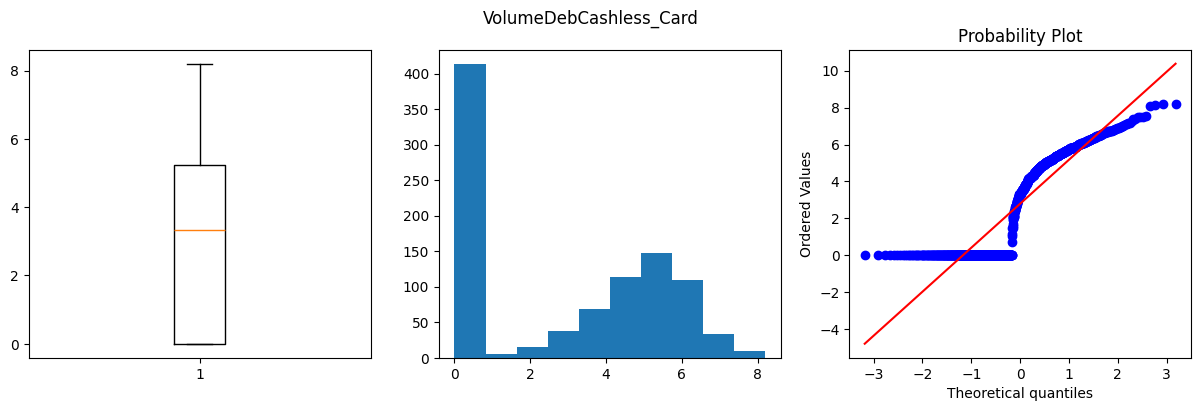

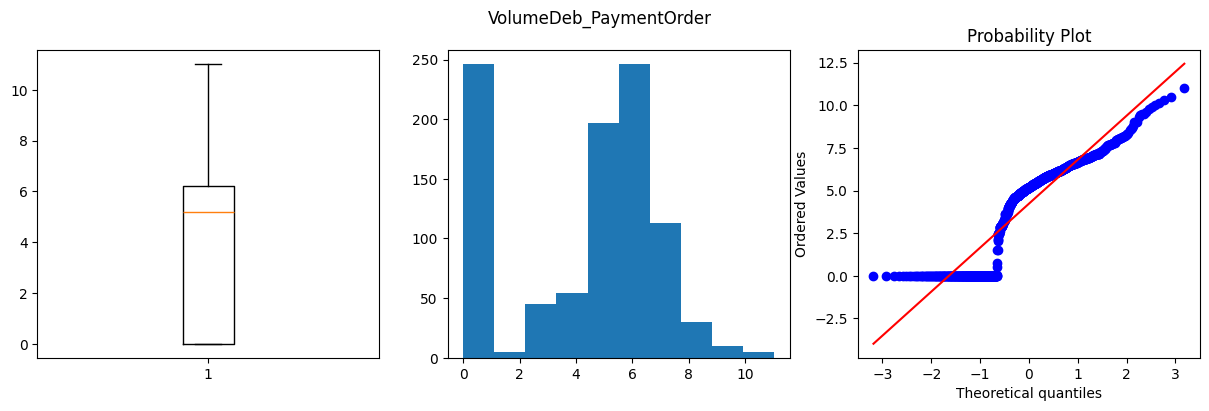

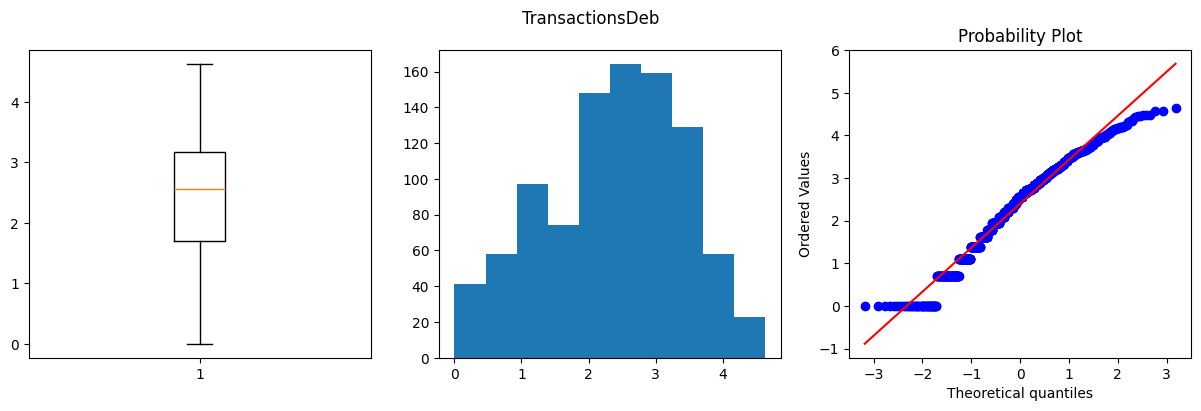

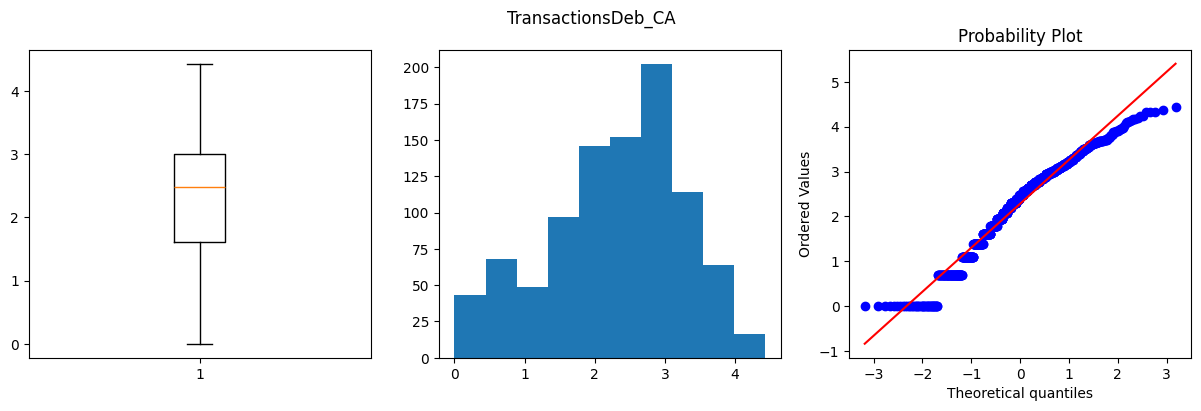

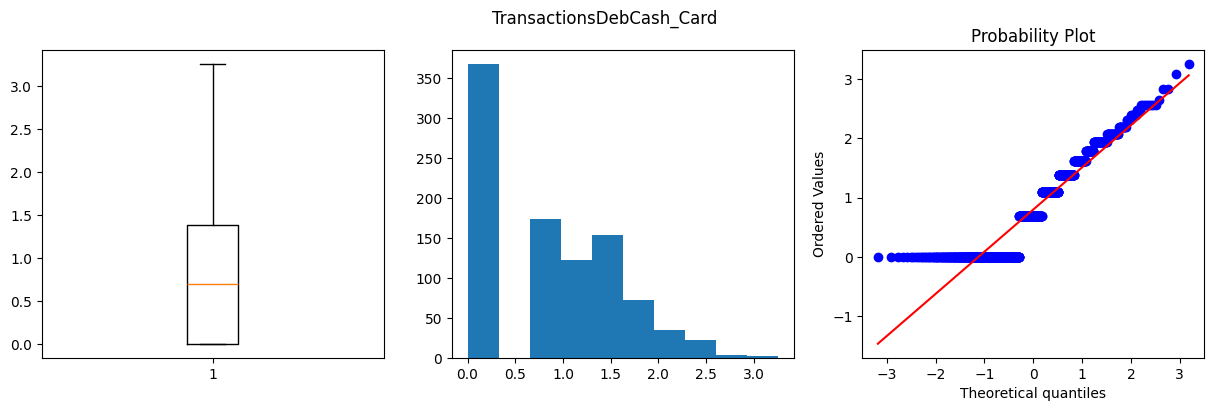

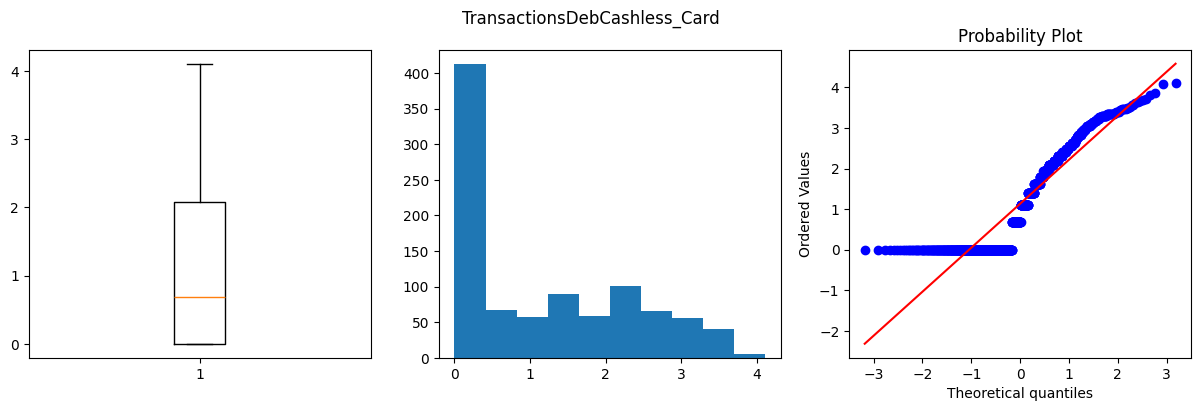

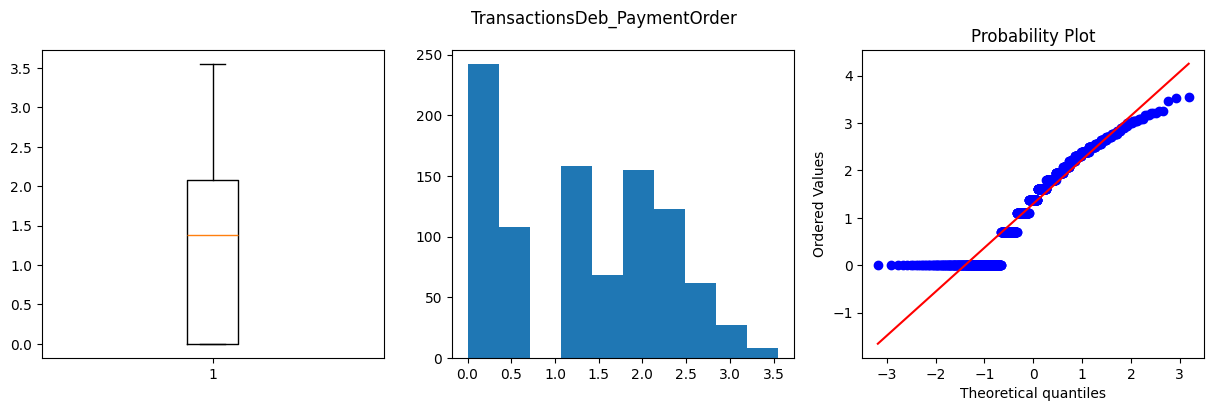

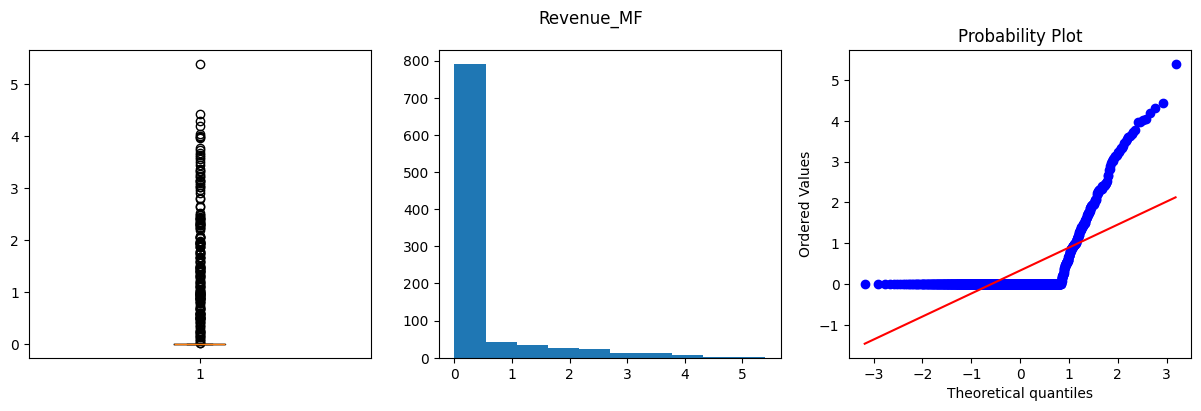

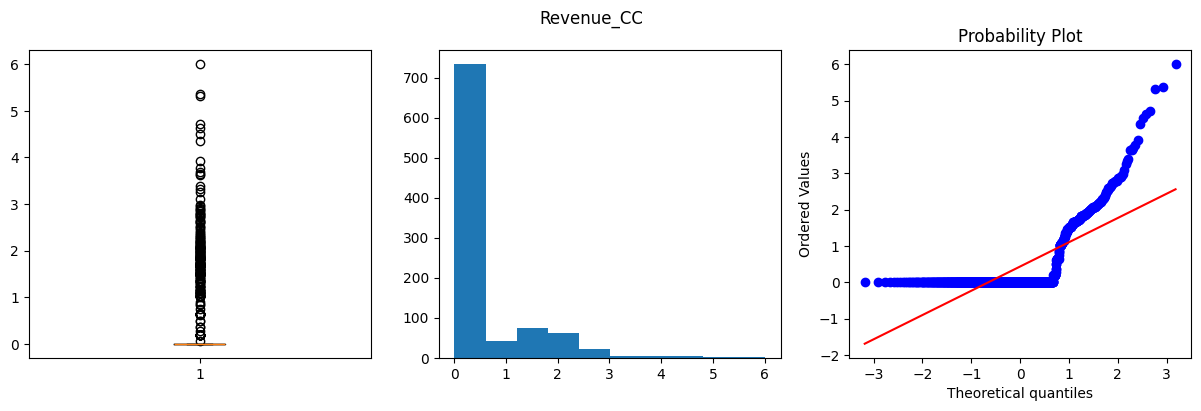

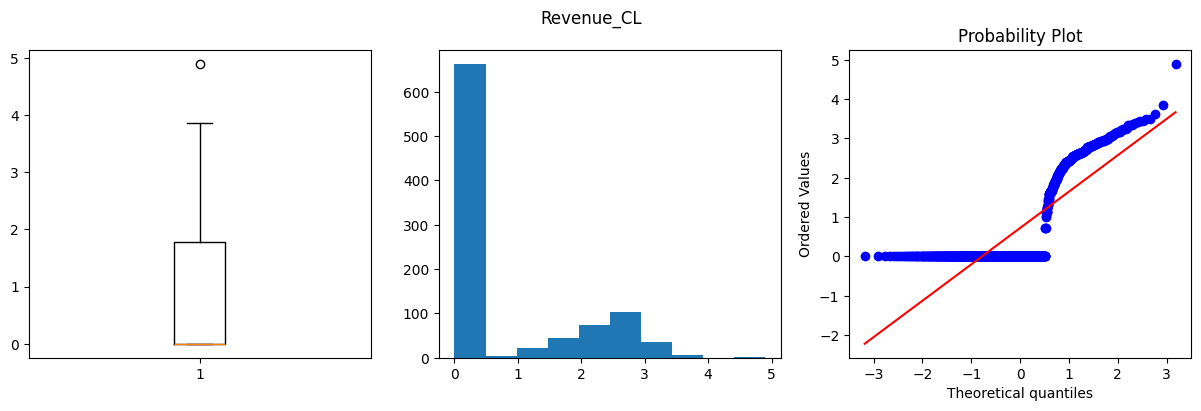

In [64]:
from sklearn.preprocessing import FunctionTransformer

logarithm_transformer = FunctionTransformer(np.log1p, validate=True)

# Apply the transformation to the skewed features
skewed_columns = ['Count_MF',
         'ActBal_CA',
         'ActBal_SA',
         'ActBal_MF',
         'ActBal_OVD',
         'ActBal_CC',
         'ActBal_CL',
         'VolumeCred',
         'VolumeCred_CA',
         'TransactionsCred',
         'TransactionsCred_CA',
         'VolumeDeb',
         'VolumeDeb_CA',
         'VolumeDebCash_Card',
         'VolumeDebCashless_Card',
         'VolumeDeb_PaymentOrder',
         'TransactionsDeb',
         'TransactionsDeb_CA',
         'TransactionsDebCash_Card',
         'TransactionsDebCashless_Card',
         'TransactionsDeb_PaymentOrder',
         'Revenue_MF',
         'Revenue_CC',
         'Revenue_CL',]

df_features_transformed = df_numeric.copy()

# Make all the values of 'ActBal_CC' positive
df_features_transformed['ActBal_CC'] = df_features_transformed['ActBal_CC'] - df_features_transformed['ActBal_CC'].min()

arr_transformed = logarithm_transformer.transform(df_features_transformed[skewed_columns].values)

for idx in range(len(skewed_columns)):
    df_features_transformed[skewed_columns[idx]] = arr_transformed[:, idx]

for col in skewed_columns: 
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    fig.suptitle(col)
    axes[0].boxplot(df_features_transformed[col])
    axes[1].hist(df_features_transformed[col])
    stats.probplot(df_features_transformed[col], dist='norm', plot=axes[2])
    plt.show()    
  

### <span style="color:orange">**Post-Transformation Feature Distribution Analysis**</span>

This section evaluates the effect of log transformation on the distribution of key features.

---

#### 📈 Observations After Transformation

- **Overall Effectiveness**:
  - Most numerical features show **substantial improvement** in distribution shape after transformation, moving closer to a **normal distribution**.

- **Remaining Skewness in Select Features**:
  - Features such as `'Count_MF'`, `'ActBal_SA'`, `'ActBal_MF'`, `'ActBal_OVD'`, and `'ActBal_CL'` remain **noticeably skewed** even after transformation.
  - These features have **fairly small value ranges**, so no further transformation will be applied.

- **Special Case: Revenue Columns (`'Revenue_MF'`, `'Revenue_CC'`, `'Revenue_CL'`)**:
  - These columns include a **large number of 0 values** (non-buyers).
  - For regression modeling:
    - A **classification model** will first predict whether a client is a buyer (non-zero target).
    - A **regression model** will then predict the revenue, but **only for the subset with non-zero values**.
  - After removing zero entries, the **log-transformed revenue values** are approximately **normally distributed**, which is beneficial for regression modeling.

---

> This two-step modeling (classification + regression on non-zeros) provides a robust way to handle the zero-inflated, skewed nature of the target variables.


In [16]:
# Create the dataset for training
df_modeling_transformed = pd.merge(left=df_features_transformed, right=df_Sales_Revenues, left_on='Client', right_on='Client')

# Create the dataset for prediction
df_outer_transformed = pd.merge(left=df_features_transformed, right=df_Sales_Revenues, how='outer', left_on='Client', right_on='Client', indicator = True)
df_prediction_transformed = df_outer_transformed[(df_outer_transformed._merge=='left_only')].drop(['_merge', 
                                                                                                   'Sale_MF',
                                                                                                  'Sale_CC',
                                                                                                  'Sale_CL',
                                                                                                  'Revenue_MF',
                                                                                                  'Revenue_CC',
                                                                                                  'Revenue_CL'], axis=1)

In [17]:
# Save the datasets to CSV files
processed_data_path: str = "../data/processed/"

df_modeling.to_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv"), index=False)
df_prediction.to_csv(os.path.join(processed_data_path, "dataset_prediction_original.csv"), index=False)

# Save the enriched datasets to CSV files
df_modeling_enriched.to_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv"), index=False)  
df_prediction_enriched.to_csv(os.path.join(processed_data_path, "dataset_prediction_enriched.csv"), index=False)

# Save the transformed datasets to CSV files
df_modeling_transformed.to_csv(os.path.join(processed_data_path, "dataset_modeling_transformed.csv"), index=False)    
df_prediction_transformed.to_csv(os.path.join(processed_data_path, "dataset_prediction_transformed.csv"), index=False)

### <span style="color:orange">**Results of Data Preparation**</span>

This section summarizes the different versions of datasets generated for model training and application, based on enrichment and transformation stages.

---

#### 📂 Dataset Variants

| Dataset Name               | Description                                                                 |
|---------------------------|-----------------------------------------------------------------------------|
| `df_modeling`             | Numerical dataset **without enrichment or transformation** for model training |
| `df_prediction`           | Numerical dataset **without enrichment or transformation** for prediction     |
| `df_modeling_enriched`    | Numerical dataset **with enrichment but without transformation** for training |
| `df_prediction_enriched`  | Numerical dataset **with enrichment but without transformation** for prediction |
| `df_modeling_transformed` | Numerical dataset **with transformation but without enrichment** for training |
| `df_prediction_transformed` | Numerical dataset **with transformation but without enrichment** for prediction |

---

> These variants allow for flexible experimentation with different modeling pipelines, such as evaluating the impact of feature enrichment and transformation independently.

In [18]:
print(df_modeling.shape)
df_modeling.head()

(951, 36)


,Client,Age,Tenure,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,...,TransactionsDebCash_Card,TransactionsDebCashless_Card,TransactionsDeb_PaymentOrder,Sex_M,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
0,1217,38,165,1,0.0,0.0,0.0,0.0,0.0,6752.244643,...,0,0,1,1,0,0,0,0.000000,0.000000,0.000000
1,850,49,44,1,0.0,0.0,0.0,0.0,0.0,43.523214,...,0,0,1,0,0,1,0,0.000000,0.893929,0.000000
2,1473,54,34,1,1.0,0.0,0.0,1.0,1.0,29.024286,...,1,26,11,1,1,0,0,4.929643,0.000000,0.000000
3,1038,29,106,1,0.0,0.0,0.0,0.0,0.0,27.035714,...,0,0,0,1,0,0,0,0.000000,0.000000,0.000000
4,225,14,187,1,0.0,0.0,1.0,0.0,0.0,345.686071,...,0,4,1,1,0,0,1,0.000000,0.000000,8.130714


In [19]:
print(df_modeling_enriched.shape)
df_modeling_enriched.head()

(951, 59)


,Client,Age,Tenure,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,...,avg_VolumeDebCashless,avg_VolumeDeb_PaymentOrder,VolumeCred_nonCA,VolumeDeb_nonCA,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
0,1217,38,165,1,0.0,0.0,0.0,0.0,0.0,6752.244643,...,0.000000,714.285714,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000
1,850,49,44,1,0.0,0.0,0.0,0.0,0.0,43.523214,...,0.000000,121.928571,0.000000,0.000000,0,1,0,0.000000,0.893929,0.000000
2,1473,54,34,1,1.0,0.0,0.0,1.0,1.0,29.024286,...,17.099904,188.798701,847.998571,80.557143,1,0,0,4.929643,0.000000,0.000000
3,1038,29,106,1,0.0,0.0,0.0,0.0,0.0,27.035714,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000
4,225,14,187,1,0.0,0.0,1.0,0.0,0.0,345.686071,...,27.808929,19.285714,0.000000,0.000000,0,0,1,0.000000,0.000000,8.130714


In [20]:
print(df_modeling_transformed.shape)
df_modeling_transformed.head()

(951, 36)


,Client,Age,Tenure,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,...,TransactionsDebCash_Card,TransactionsDebCashless_Card,TransactionsDeb_PaymentOrder,Sex_M,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
0,1217,38,165,1,0.0,0.0,0.0,0.0,0.0,8.817778,...,0.000000,0.000000,0.693147,1,0,0,0,0.000000,0.000000,0.000000
1,850,49,44,1,0.0,0.0,0.0,0.0,0.0,3.796011,...,0.000000,0.000000,0.693147,0,0,1,0,0.000000,0.893929,0.000000
2,1473,54,34,1,1.0,0.0,0.0,1.0,1.0,3.402007,...,0.693147,3.295837,2.484907,1,1,0,0,4.929643,0.000000,0.000000
3,1038,29,106,1,0.0,0.0,0.0,0.0,0.0,3.333479,...,0.000000,0.000000,0.000000,1,0,0,0,0.000000,0.000000,0.000000
4,225,14,187,1,0.0,0.0,1.0,0.0,0.0,5.848420,...,0.000000,1.609438,0.693147,1,0,0,1,0.000000,0.000000,8.130714


## 5. Building Classification Models to Predict Product Purchase Propensity

### Building Baseline Models

Baseline classification models are constructed using `DecisionTreeClassifier`.

---

#### ✅ Rationale for Choosing Decision Tree

- **Handles Imbalanced Data**  
  Decision trees are relatively robust to imbalanced datasets and can still produce meaningful splits without needing resampling.

- **No Need for Feature Scaling or Transformation**  
  Decision trees are non-parametric models that do not require features to be standardized or transformed.

- **Fast and Interpretable**  
  They provide quick training and allow for easy interpretation of decision logic, which is useful for early insights.

---

> These baseline models serve as a reference point for evaluating the added value of more complex algorithms in later stages.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score

****** Baseline Model Metrics for Sale_MF ******

Confusion Matrix: 
 [[625 133]
 [140  53]]

Classification Report:


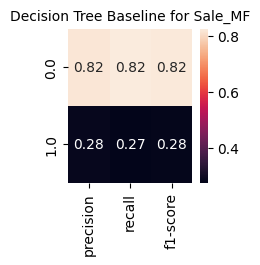

****** Baseline Model Metrics for Sale_CC ******

Confusion Matrix: 
 [[548 166]
 [169  68]]

Classification Report:


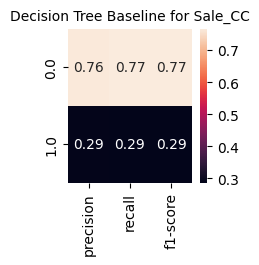

****** Baseline Model Metrics for Sale_CL ******

Confusion Matrix: 
 [[454 208]
 [191  98]]

Classification Report:


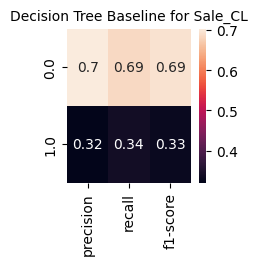

In [22]:
# Evaluate the confusion matrix and classifiocation metrices for each baseline model based on the dataset without enrichment and transformation
df_modeling = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv"))
df_modeling_enriched = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv"))

df_build = df_modeling.drop(['Client'], axis=1).astype('float32')
arr_build = df_build.values

X = arr_build[:, :-6]

y_Sale_MF = arr_build[:, -6]
y_Sale_CC = arr_build[:, -5]
y_Sale_CL = arr_build[:, -4]

target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
target_sets = [y_Sale_MF, y_Sale_CC, y_Sale_CL]

def report_test_results(y_test: np.array, y_pred: np.array, target_name: str, model_name: str)  -> None:
    
    print(f"****** Baseline Model Metrics for {target_name} ******")

    # Confusion matrix
    print("\nConfusion Matrix: \n", metrics.confusion_matrix(y_test, y_pred)) # Confusion matrix
    
    # Classification report
    print("\nClassification Report:")
    clf_report_dtc = metrics.classification_report(y_test, y_pred, output_dict=True)
    plt.figure(figsize=(2, 2))
    plt.title(f"{model_name} for {target_name}", fontdict={'fontsize': 10})
    sns.heatmap(pd.DataFrame(clf_report_dtc).iloc[:-1, :-3].T, annot=True)
    plt.show()    


def build_test_dtc(X: np.array, y: np.array, target_name: str, model_name: str) -> None:

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
    cv_splits = cv.split(X, y)

    # DecisionTreeClassifier is used to build the baseline as no feature scaling is needed.
    dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')

    y_test_cv = []
    y_pred_cv = []

    for train_indices, test_indices in cv_splits:
        # Split the dataset into train and test datasets
        X_train = X[train_indices]
        y_train = y[train_indices]

        X_test = X[test_indices]
        y_test = y[test_indices]   

        # Fitting and making predictions
        dtc.fit(X_train, y_train)
        y_pred_dtc = dtc.predict(X_test)

        y_test_cv.extend(y_test.tolist())
        y_pred_cv.extend(y_pred_dtc.tolist())

 
    report_test_results(y_test_cv, y_pred_cv, target_name, model_name)


for target_name, target_set in zip(target_names, target_sets):
    
    build_test_dtc(X, target_set, target_name, 'Decision Tree Baseline')

### Investigating Usefulness of the Created Features in Building Baseline Models

In [23]:
# Here, the baseline models are built upon df_modeling, as well as df_modeling_enriched, to compare the performance of the models with and without enrichment.
# Since it's not necessary to scale or transform numerical features for tree-based models, the dataset df_modeling_transformed is not used for training the models.

for data_set_name, data_set in zip(['df_modeling', 'df_modeling_enriched'], [df_modeling, df_modeling_enriched]):
    df_build = data_set.drop(['Client'], axis=1).astype('float32')
    arr_build = df_build.values

    X = arr_build[:, :-6]

    y_Sale_MF = arr_build[:, -6]
    y_Sale_CC = arr_build[:, -5]
    y_Sale_CL = arr_build[:, -4]

    target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
    target_sets = [y_Sale_MF, y_Sale_CC, y_Sale_CL]

    print(f"\n-------- Baseline Model is built upon {data_set_name} --------")

    # The model is trained and evaluated using 10-fold cross-validation
    for target_name, target_set in zip(target_names, target_sets):
        
        y = target_set
        
        # 10-fold random stratified cross-validation
        # cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42) 
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
        
        dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')
            
        print(f"\n****** Baseline Model Metrics for {target_name} ******")
        
        # Accuracy score
        print("Mean CV Accuracy:", cross_val_score(dtc, X, y, scoring="accuracy", cv=cv, n_jobs=-1).mean())  

        # Precision score
        print("Mean CV Precision:", cross_val_score(dtc, X, y, scoring="precision", cv=cv, n_jobs=-1).mean()) 

        # Recall score
        print("Mean CV Recall:", cross_val_score(dtc, X, y, scoring="recall", cv=cv, n_jobs=-1).mean())  

        # ROC-AUC
        print("Mean CV ROC-AUC:", cross_val_score(dtc, X, y, scoring="roc_auc", cv=cv, n_jobs=-1).mean()) 



-------- Baseline Model is built upon df_modeling --------

****** Baseline Model Metrics for Sale_MF ******
Mean CV Accuracy: 0.7129605263157895
Mean CV Precision: 0.2830330612426116
Mean CV Recall: 0.27473684210526317
Mean CV ROC-AUC: 0.5496666666666667

****** Baseline Model Metrics for Sale_CC ******
Mean CV Accuracy: 0.6476644736842105
Mean CV Precision: 0.3001079156456731
Mean CV Recall: 0.28731884057971013
Mean CV ROC-AUC: 0.5272568381302307

****** Baseline Model Metrics for Sale_CL ******
Mean CV Accuracy: 0.5804166666666667
Mean CV Precision: 0.3158677248677249
Mean CV Recall: 0.3392857142857143
Mean CV ROC-AUC: 0.5124967693997544

-------- Baseline Model is built upon df_modeling_enriched --------

****** Baseline Model Metrics for Sale_MF ******
Mean CV Accuracy: 0.6877083333333334
Mean CV Precision: 0.22405482113047065
Mean CV Recall: 0.2336842105263158
Mean CV ROC-AUC: 0.5185438596491228

****** Baseline Model Metrics for Sale_CC ******
Mean CV Accuracy: 0.63927631578947

### <span style="color:orange">**Baseline Model Evaluation Results**</span>

---

#### 🔍 Key Observations from Metrics & Confusion Matrices

- The baseline models perform reasonably well for predicting the **Non-Purchase** class (`Sale_MF == 0`, `Sale_CC == 0`, `Sale_CL == 0`).
- However, **Purchase** class predictions (`Sale_MF == 1`, `Sale_CC == 1`, `Sale_CL == 1`) are poor, with high **false positives** and **false negatives**.
- This imbalance suggests that the classifier is biased toward the majority class (non-purchasers), a typical issue in imbalanced datasets.

---

#### ⚠️ Identified Issue

> **Class imbalance** in the target variables likely causes the model to underperform for minority (positive) classes.

---

#### 🔧 Planned Solution

- Apply **oversampling techniques** (e.g., SMOTE or RandomOverSampler) to construct balanced training datasets.
- Re-train models using the oversampled data to improve minority class prediction.

---

#### 🧪 Enriched Features Impact Analysis

- Enriched features **do not improve** the baseline performance of DecisionTreeClassifier.
- However, the enriched dataset will be retained for further model development:
  - After **hyperparameter tuning** and switching to more powerful models, enriched features **may improve performance**.

### Comparing Different Oversampling Techniques

In [24]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score

target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
target_indeces = [-6, -5, -4]

# The oversampling methods are applied to the training dataset to build the baseline models.
def build_baseline_models_with_oversampling(df_build: pd.DataFrame, target_names: list, target_indeces: list, sampling_method: str) -> None:
    
    arr_build =  df_build.drop(['Client'], axis=1).astype('float32').values
    X = arr_build[:, :-6]

    for target_name, target_index in zip(target_names, target_indeces):
        y = arr_build[:, target_index]

        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
        cv_splits = cv.split(X, y)
        
        avg_accuracy = 0.0
        avg_precision = 0.0
        avg_recall = 0.0    
        avg_roc_auc = 0.0
        
        for train_indices, test_indices in cv_splits:
            X_train = X[train_indices]
            y_train = y[train_indices]

            X_test = X[test_indices]
            y_test = y[test_indices]    
            
            # Apply oversampling to the training data
            # The overSampler is applied to the training data only.
            if sampling_method == 'SMOTE':
                oversampler = SMOTE(random_state=42, sampling_strategy='auto')
            elif sampling_method == 'RandomOverSampler':
                oversampler = RandomOverSampler(random_state=42)
            else:
                raise ValueError(f"Unknown sampling method: {sampling_method}")
            
            X_balanced, y_balanced = oversampler.fit_resample(X_train, y_train)

            # DecisionTreeClassifier is used to build the baseline as no feature scaling is needed.
            dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')

            # Fitting and making predictions
            dtc.fit(X_balanced, y_balanced)
            y_pred_dtc = dtc.predict(X_test)
            y_proba_dtc = dtc.predict_proba(X_test)[:, 1]
            
            accuracy = accuracy_score(y_test, y_pred_dtc)
            precision = metrics.precision_score(y_test, y_pred_dtc)
            recall = metrics.recall_score(y_test, y_pred_dtc)
            roc_auc = roc_auc_score(y_test, y_proba_dtc)
            
            avg_accuracy += accuracy
            avg_precision += precision
            avg_recall += recall
            avg_roc_auc += roc_auc
            
        
        avg_accuracy = avg_accuracy / 10.0
        avg_precision = avg_precision / 10.0
        avg_recall = avg_recall / 10.0
        avg_roc_auc = avg_roc_auc / 10.0   
            
        print(f"\n****** Decision Tree on Balanced Data with {sampling_method} for {target_name} ******")    

        # Accuracy score
        print("\nMean CV Accuracy:", avg_accuracy)  

        # Precision score
        print("Mean CV Precision:", avg_precision)

        # Recall score
        print("Mean CV Recall:", avg_recall)

        # ROC-AUC
        print("Mean CV ROC-AUC:", avg_roc_auc)       


#####  Random Oversampling with Replacement

In [25]:
# Perform random oversampling with replacement
build_baseline_models_with_oversampling(df_modeling, target_names, target_indeces, 'RandomOverSampler')


****** Decision Tree on Balanced Data with RandomOverSampler for Sale_MF ******

Mean CV Accuracy: 0.712938596491228
Mean CV Precision: 0.28316756224570894
Mean CV Recall: 0.2744736842105263
Mean CV ROC-AUC: 0.5494473684210526

****** Decision Tree on Balanced Data with RandomOverSampler for Sale_CC ******

Mean CV Accuracy: 0.6666776315789474
Mean CV Precision: 0.3148694804644462
Mean CV Recall: 0.31159420289855067
Mean CV ROC-AUC: 0.5479136898686807

****** Decision Tree on Balanced Data with RandomOverSampler for Sale_CL ******

Mean CV Accuracy: 0.6372368421052632
Mean CV Precision: 0.40517267781783917
Mean CV Recall: 0.39802955665024625
Mean CV ROC-AUC: 0.5698650723097456


#####  Synthetic Minority Oversampling Technique (SMOTE)

In [26]:
# Perform SMOTE oversampling
build_baseline_models_with_oversampling(df_modeling, target_names, target_indeces, 'SMOTE')


****** Decision Tree on Balanced Data with SMOTE for Sale_MF ******

Mean CV Accuracy: 0.6666557017543859
Mean CV Precision: 0.21576264378895962
Mean CV Recall: 0.2431578947368421
Mean CV ROC-AUC: 0.5087456140350877

****** Decision Tree on Balanced Data with SMOTE for Sale_CC ******

Mean CV Accuracy: 0.6477412280701755
Mean CV Precision: 0.3191120455162809
Mean CV Recall: 0.36739130434782613
Mean CV ROC-AUC: 0.5541573110158536

****** Decision Tree on Balanced Data with SMOTE for Sale_CL ******

Mean CV Accuracy: 0.6056469298245613
Mean CV Precision: 0.3590327291822008
Mean CV Recall: 0.37733990147783253
Mean CV ROC-AUC: 0.5414062691468764


### <span style="color:orange">**Impact of Oversampling on Classification Model Performance**</span>

---

#### 📈 Key Insights from Model Performance Comparison

- **Oversampling** has notably improved the classification performance for:
  - `Sale_CC`: Significant gains in both **precision** and **recall**.
  - `Sale_CL`: Marked improvement in predictive quality across key metrics.
- However, **Sale_MF** classification did **not benefit** from oversampling — metrics remain similar to the baseline model.

---

#### 🔍 Comparison of Oversampling Techniques

- Between the two oversampling methods tested:
  - **Random Oversampling with Replacement** yields **better performance** than **SMOTE** for Decision Tree models.
  - This suggests that for the given dataset size and distribution, simple duplication works better than synthetic sample generation.

---

#### ✅ Conclusion

> Oversampling is a **valuable strategy** for improving class imbalance, but its effectiveness may **vary by target variable**. Method selection (e.g., Random vs. SMOTE) should be **validated empirically** per use case.

### Comparing Different Classification Modeling Methods

In [27]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# A set of ensemble models are defined to accurately fit the data.
models = [RandomForestClassifier(random_state=42), 
          ExtraTreesClassifier(random_state=42), 
          GradientBoostingClassifier(random_state=42), 
          XGBClassifier(random_state=42)]
model_names = ["RandomForest", "ExtraTrees", "GradientBoosting", "XGBoost"]

# Define targets
target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
target_indeces = [-6, -5, -4]


def cross_validate_models(df_build: pd.DataFrame, dataset_name: str) -> None:
    

    for target_name, target_index in zip(target_names, target_indeces):
        arr_build = df_build.values
        
        X = arr_build[:, :-6]
        y = arr_build[:, target_index]
       
        # 10-fold random stratified cross-validation
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

        print(f"****** Model Metrics for {target_name} on {dataset_name} ******")

        # Getting matrics scores for the different models
        for model, model_name in zip(models, model_names):

            print(f"-- {model_name} --")
            # Accuracy score
            print("Mean CV Accuracy:", cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1).mean())  

            # Precision score
            print("Mean CV Precision:", cross_val_score(model, X, y, scoring="precision", cv=cv, n_jobs=-1).mean()) 

            # Recall score
            print("Mean CV Recall:", cross_val_score(model, X, y, scoring="recall", cv=cv, n_jobs=-1).mean())

            # ROC-AUC
            print("Mean CV ROC-AUC:", cross_val_score(model, X, y, scoring="roc_auc", cv=cv, n_jobs=-1).mean())        
            print()     
            
            
cross_validate_models(df_build, "Original Dataset")            

****** Model Metrics for Sale_MF on Original Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.8044298245614036
Mean CV Precision: 0.6016666666666667
Mean CV Recall: 0.08263157894736842
Mean CV ROC-AUC: 0.5665822022160665

-- ExtraTrees --
Mean CV Accuracy: 0.798125
Mean CV Precision: 0.43666666666666665
Mean CV Recall: 0.09263157894736843
Mean CV ROC-AUC: 0.5934766620498615

-- GradientBoosting --
Mean CV Accuracy: 0.8023245614035087
Mean CV Precision: 0.5583333333333333
Mean CV Recall: 0.12394736842105263
Mean CV ROC-AUC: 0.5686048476454293

-- XGBoost --
Mean CV Accuracy: 0.7875877192982456
Mean CV Precision: 0.44929653679653675
Mean CV Recall: 0.14578947368421052
Mean CV ROC-AUC: 0.5646030470914127

****** Model Metrics for Sale_CC on Original Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.7749890350877193
Mean CV Precision: 0.6765079365079365
Mean CV Recall: 0.18605072463768113
Mean CV ROC-AUC: 0.6120545080061691

-- ExtraTrees --
Mean CV Accuracy: 0.7623464912280701
Me

### Investigating Usefulness of the Created Features in Using Different Classification Modeling Methods

In [28]:
df_build_enriched = df_modeling_enriched.drop(['Client'], axis=1).astype('float32')

cross_validate_models(df_build_enriched, "Enriched Dataset")   

****** Model Metrics for Sale_MF on Enriched Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.8044298245614036
Mean CV Precision: 0.6016666666666667
Mean CV Recall: 0.08263157894736842
Mean CV ROC-AUC: 0.5665822022160665

-- ExtraTrees --
Mean CV Accuracy: 0.798125
Mean CV Precision: 0.43666666666666665
Mean CV Recall: 0.09263157894736843
Mean CV ROC-AUC: 0.5934766620498615

-- GradientBoosting --
Mean CV Accuracy: 0.8023245614035087
Mean CV Precision: 0.5583333333333333
Mean CV Recall: 0.12394736842105263
Mean CV ROC-AUC: 0.5686048476454293

-- XGBoost --
Mean CV Accuracy: 0.7875877192982456
Mean CV Precision: 0.44929653679653675
Mean CV Recall: 0.14578947368421052
Mean CV ROC-AUC: 0.5646030470914127

****** Model Metrics for Sale_CC on Enriched Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.7749890350877193
Mean CV Precision: 0.6765079365079365
Mean CV Recall: 0.18605072463768113
Mean CV ROC-AUC: 0.6120545080061691

-- ExtraTrees --
Mean CV Accuracy: 0.7623464912280701
Me

#### <span style="color:orange">**Ensemble Model Performance with Original vs. Enriched Datasets**</span>


---

#### 📊 Key Findings from Model Evaluation

- Using **default hyperparameters**, none of the ensemble methods (e.g., Random Forest, Gradient Boosting, XGBoost) show **notable improvement** in **recall** over the baseline model.
- Similarly, the addition of **engineered/enriched features** does **not lead to meaningful performance gains** across these algorithms.

---

#### 🛠️ Interpretation

- Ensemble models, although powerful, may **require tuning** to realize their full potential — especially in tasks with **imbalanced classes**.
- The **default configurations** might be suboptimal, and their limited performance should not be taken as a final verdict on model effectiveness.
- While feature enrichment may not help in the default setting, it could still **enhance performance after hyperparameter tuning**.

---

#### ✅ Conclusion

> Ensemble models and enriched features **hold potential**, but **hyperparameter optimization** and **careful evaluation** are crucial to unlocking their performance benefits — especially for recall-sensitive applications.


### Optimizing Classification Model Hyperparameters

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from typing import Union


def randomSearch_pipeline(X_train: np.array, y_train: np.array, modeling_method: str, param_dist: dict, cv: int = 10, scoring_fit: str = 'accuracy', over_sampler: str = 'RandomOverSampler') -> Union[DecisionTreeClassifier, ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier]:
    """
    Perform a random search with cross-validation on the specified modeling method and parameter distribution.
    Parameters:
        X_train (np.array): Feature matrix for training.
        y_train (np.array): Target vector for training.
        modeling_method (str): The modeling method to use ('DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost').
        param_dist (dict): Dictionary with parameters names as keys and distributions or lists of parameters to try.
        cv (int): Number of cross-validation folds.
        scoring_fit (str): Scoring metric to use for evaluation.
    Returns:
        fitted_model: The fitted model after random search.
    """
    # Initialize the classifier
    if modeling_method == 'DecisionTree':
        model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    elif modeling_method == 'RandomForest':
        model = RandomForestClassifier(random_state=42, class_weight='balanced')
    elif modeling_method == 'ExtraTrees':
        model = ExtraTreesClassifier(random_state=42, class_weight='balanced')  
    elif modeling_method == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42)    
    elif modeling_method == 'XGBoost':          
        model = XGBClassifier(random_state=42, eval_metric='logloss')
    else:       
        raise ValueError("Unsupported modeling method. Choose from 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")
    
    # Initialize the oversampler
    if over_sampler not in ['RandomOverSampler', 'SMOTE']:
        oversampler = None
    else:
        oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42) if over_sampler == 'RandomOverSampler' else SMOTE(sampling_strategy='auto', random_state=42)

    # Create a pipeline with SMOTE and the initialized model
    pipeline = ImbPipeline([
        ('oversampler', oversampler),
        ('classifier', model)
    ])

    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist, 
        n_iter=50,  # Number of different combinations to try
        cv=cv, 
        random_state=42,
        n_jobs=-1, 
        scoring=scoring_fit,
        verbose=2
    )

    fitted_model = rs.fit(X_train, y_train)
    
    return fitted_model

# Define the parameter grid for DecisionTreeClassifier
param_dist_decisionTree = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None] + list(np.arange(1, 21)),   # None or values from 1 to 20
    'classifier__min_samples_split': np.arange(2, 11),           # values from 2 to 10
    'classifier__min_samples_leaf': np.arange(1, 11),            # values from 1 to 10
    'classifier__max_features': [None, 'sqrt', 'log2'],
    # 'splitter': ['best', 'random']
}

# Define the hyperparameter grid for RandomForestClassifier
param_dist_randomForest = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__criterion': ['gini', 'entropy', 'log_loss'], 
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__bootstrap': [True, False]
}

# Define the hyperparameter grid for ExtraTreesClassifier
param_dist_extraTrees = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__criterion': ['gini', 'entropy', 'log_loss'], 
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__bootstrap': [True, False]  # ExtraTreesClassifier default is False
}

# Define the parameter grid for GradientBoostingClassifier
param_dist_gradientBoosting = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__max_features': ['sqrt', 'log2', None]
}

# Define the parameter grid for XGBClassifier
param_dist_XGBoost = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.3],
    'classifier__reg_alpha': [0, 0.1, 1],
    'classifier__reg_lambda': [1, 1.5, 2]
}

target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']    
target_indeces = [-6, -5, -4]   

best_param_configurations = {'Sale_MF': None, 'Sale_CC': None, 'Sale_CL': None}

for data_set_name, data_set in zip(['not_enriched', 'enriched'], [df_build, df_build_enriched]) :

    arr_build = data_set.values

    for learning_method in ['DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost']:
        
        modeling_methods = [learning_method] * 3

        if learning_method == 'DecisionTree':
            param_grid = param_dist_decisionTree
        elif learning_method == 'RandomForest':
            param_grid = param_dist_randomForest         
        elif learning_method == 'ExtraTrees': 
            param_grid = param_dist_extraTrees 
        elif learning_method == 'GradientBoosting':
            param_grid = param_dist_gradientBoosting
        elif learning_method == 'XGBoost':  
            param_grid = param_dist_XGBoost
        else:
            raise ValueError("Unsupported modeling method. Choose from 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")

        for over_sampler in ['None', 'RandomOverSampler', 'SMOTE']:

            # Perform random search with cross-validation for each target variable
            # 10-fold random stratified cross-validation
            for target_name, target_index, modeling_method in zip(target_names, target_indeces, modeling_methods):

                X = arr_build[:, :-6]
                y = arr_build[:, target_index]

                # Split the dataset into train and test datasets
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

                # Apply oversampling to the training data
                # The overSampler is applied to the training data only.
                # Perform random search with cross-validation
                # 10-fold random stratified cross-validation 
                # Since the task is to identify the clients with the high propensity to buy the products, the binary classification is aiming for a good balance between recall and precision.
                # Therefore, the 'roc_auc' score is used as the scoring metric in hyperparameter optimization to balance TPR and FPR globally.
                model = randomSearch_pipeline(X, y, modeling_method, param_grid, 10, 'roc_auc', over_sampler)  

                if best_param_configurations[target_name] is None:
                    best_param_configurations[target_name] = {'data_set': data_set_name, 'modeling_method': modeling_method, 'over_sampler': over_sampler, 'best_score': model.best_score_, 'best_hyperparams': model.best_params_}  
                else:
                    if model.best_score_ > best_param_configurations[target_name]['best_score']:
                        best_param_configurations[target_name] = {'data_set': data_set_name, 'modeling_method': modeling_method, 'over_sampler': over_sampler, 'best_score': model.best_score_, 'best_hyperparams': model.best_params_}   

                
                print(f"****** Best Scores/Hyperparameters for {target_name} ******")
                print(model.best_score_)
                # print(model.best_params_) 
                print("\n")

             
print("****** Best hyperparameters for each target variable:")  
for target_name, configurations in best_param_configurations.items():
    print(f"{target_name}: {target_name}")
    print(f"Best score: {configurations['best_score']}")
    print(f"Modeling method: {configurations['modeling_method']}")
    print(f"Over sampler: {configurations['over_sampler']}")
    print(f"Data set: {configurations['data_set']}")  
    print(f"Best hyperparameters: {configurations['best_hyperparams']}")
    print("\n")

# Save the best modling configurations into a JSON file
import json


# Since JSON module in Python doesn't know how to handle NumPy types, we need to convert them to standard Python types.
def convert_numpy_types(obj: Union[np.ndarray, np.generic, dict, list]) -> Union[dict, list, float, int, str]:
    
    """Convert NumPy types to standard Python types for JSON serialization.     
    Args:   
        obj (Union[np.ndarray, np.generic, dict, list]): The object to convert.
       
    Returns:
        Union[dict, list, float, int, str]: The converted object.
    """

    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj
    

cleaned_best_param_configurations = convert_numpy_types(best_param_configurations)

results_path: str = "../results/"
with open(os.path.join(results_path, "best_cla_modeling_configurations.json"), 'w') as f:
    json.dump(cleaned_best_param_configurations, f, indent=4)


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_MF ******
0.5819389196675899


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CC ******
0.6198560753611848


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CL ******
0.5981347182582386


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_MF ******
0.5793097414589103


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CC ******
0.5969659872479643


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CL ******
0.6103798907388716


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_MF ******
0.581674838411819


Fitting 10 folds for each of 50 can

In [36]:
best_param_configurations

{'Sale_MF': {'data_set': 'not_enriched',
  'modeling_method': 'ExtraTrees',
  'over_sampler': 'None',
  'best_score': 0.6307650507848569,
  'best_hyperparams': {'classifier__n_estimators': 400,
   'classifier__min_samples_split': 10,
   'classifier__min_samples_leaf': 2,
   'classifier__max_features': 'sqrt',
   'classifier__max_depth': None,
   'classifier__criterion': 'gini',
   'classifier__bootstrap': False}},
 'Sale_CC': {'data_set': 'not_enriched',
  'modeling_method': 'ExtraTrees',
  'over_sampler': 'RandomOverSampler',
  'best_score': 0.6430132070603978,
  'best_hyperparams': {'classifier__n_estimators': 150,
   'classifier__min_samples_split': 10,
   'classifier__min_samples_leaf': 4,
   'classifier__max_features': 'sqrt',
   'classifier__max_depth': 50,
   'classifier__criterion': 'entropy',
   'classifier__bootstrap': True}},
 'Sale_CL': {'data_set': 'not_enriched',
  'modeling_method': 'GradientBoosting',
  'over_sampler': 'None',
  'best_score': 0.666554765358162,
  'best_

### Building Final Classification Models

****** Model Metrics for Sale_MF ******

Accuracy: 0.7696335078534031
Precision: 0.5625
Recall: 0.1956521739130435
F1 Score: 0.2903225806451613
ROC-AUC: 0.6133433283358319

Confusion Matrix: 
 [[138   7]
 [ 37   9]]


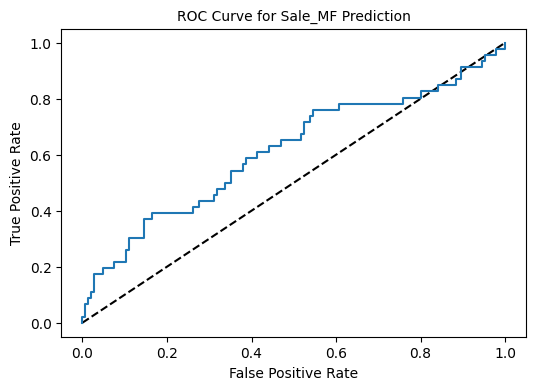



****** Model Metrics for Sale_CC ******

Accuracy: 0.7015706806282722
Precision: 0.45161290322580644
Recall: 0.25925925925925924
F1 Score: 0.32941176470588235
ROC-AUC: 0.5644768856447688

Confusion Matrix: 
 [[120  17]
 [ 40  14]]


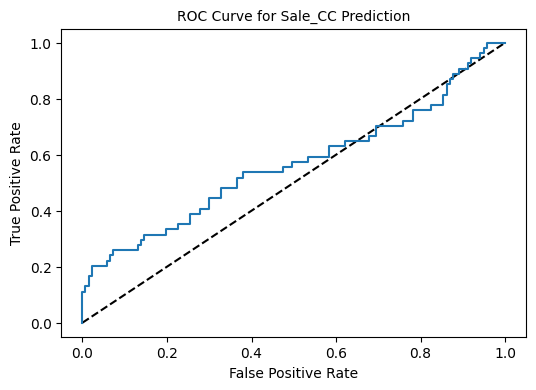



****** Model Metrics for Sale_CL ******

Accuracy: 0.7696335078534031
Precision: 0.6666666666666666
Recall: 0.33962264150943394
F1 Score: 0.45
ROC-AUC: 0.6808859721082855

Confusion Matrix: 
 [[129   9]
 [ 35  18]]


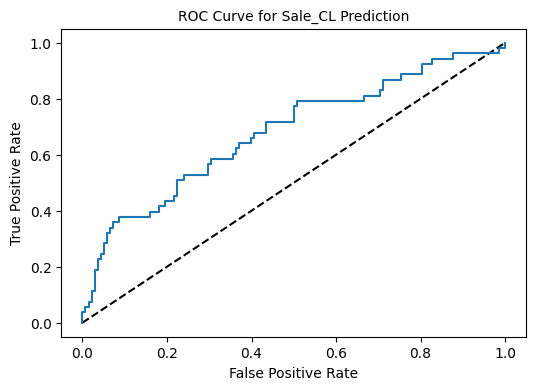

In [ ]:
# Estimate metric scores and plot ROC curves to describe the model quality of the best models on the test set 

import os
import json
from typing import Union
from sklearn.metrics import roc_curve

# Load the best modeling configurations from the JSON file 
results_path: str = "../results/"
with open(os.path.join(results_path, "best_cla_modeling_configurations.json"), "r") as f:
    best_param_configurations = json.load(f)

for target_name, target_index in zip(target_names, target_indeces):

    # Load the best modeling configurations for the target variable
    configurations = best_param_configurations[target_name]   

    # Load the dataset based on the configurations
    if configurations['data_set'] == 'not_enriched':        
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv")).values
    else:
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv")).values

    X = arr_build[:, :-6]
    y = arr_build[:, target_index]

    # Split the dataset into train and test datasets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply oversampling to the training data
    # The overSampler is applied to the training data only.     
    if configurations['over_sampler'] == 'RandomOverSampler':
        oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
    elif configurations['over_sampler'] == 'SMOTE':
        oversampler = SMOTE(sampling_strategy='auto', random_state=42)
    else:
        oversampler = None

    if oversampler is not None:
        X_train, y_train = oversampler.fit_resample(X_train, y_train)
    
    # Get the modeling method and best hyperparameters from the configurations, and build the model
    modeling_method = configurations['modeling_method']
    if modeling_method == 'DecisionTree':
        model = DecisionTreeClassifier(random_state=42, 
                                       class_weight='balanced',
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'RandomForest':
        model = RandomForestClassifier(random_state=42, 
                                       class_weight='balanced',
                                       n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'],
                                       bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])
    elif modeling_method == 'ExtraTrees':
        model = ExtraTreesClassifier(random_state=42, 
                                     class_weight='balanced',
                                     n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                     criterion=configurations['best_hyperparams']['classifier__criterion'],   
                                     max_depth=configurations['best_hyperparams']['classifier__max_depth'],                                                                       
                                     min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                     min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                     max_features=configurations['best_hyperparams']['classifier__max_features'],
                                     bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])                                    
    elif modeling_method == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42, 
                                           n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                           learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                                           max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                           min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                           min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                           subsample=configurations['best_hyperparams']['classifier__subsample'],
                                           max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'XGBoost':
        model = XGBClassifier(random_state=42,
                              eval_metric='logloss',
                              class_weight='balanced',
                              n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                              learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                              max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                              min_child_weight=configurations['best_hyperparams']['classifier__min_child_weight'],
                              subsample=configurations['best_hyperparams']['classifier__subsample'],
                              colsample_bytree=configurations['best_hyperparams']['classifier__colsample_bytree'],
                              gamma=configurations['best_hyperparams']['classifier__gamma'],
                              reg_alpha=configurations['best_hyperparams']['classifier__reg_alpha'],
                              reg_lambda=configurations['best_hyperparams']['classifier__reg_lambda'])
    else:       
        raise ValueError("Unsupported modeling method. Choose from 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")


    # Fit and make predictions
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_probs = model.predict_proba(X_test)[:, 1]

    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs)


    print(f"****** Model Metrics for {target_name} ******")
    print("\nAccuracy:", accuracy)     
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix: \n", metrics.confusion_matrix(y_test, y_pred)) # Confusion matrix

    # Generate ROC curve values: fpr, tpr, thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

    plt.figure(figsize=(6, 4))
    plt.plot([0, 1], [0, 1], 'k--')

    # Plot tpr against fpr
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {target_name} Prediction', fontdict={'fontsize': 10})
    plt.show()    
    print("\n")


In [34]:
# Build final classification models

def train_classifier(target_name: str, target_index: int) -> Union[DecisionTreeClassifier, ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier]:
    
    configurations = best_param_configurations[target_name]
    
    # Load the dataset based on the configurations
    if configurations['data_set'] == 'not_enriched':        
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv")).values
    else:
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv")).values
    
    X = arr_build[:, :-6]
    y = arr_build[:, target_index]    

    # Apply oversampling to the training data
    if configurations['over_sampler'] == 'RandomOverSampler':
        oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
    elif configurations['over_sampler'] == 'SMOTE':
        oversampler = SMOTE(sampling_strategy='auto', random_state=42)
    else:
        oversampler = None

    if oversampler is not None:
        X_train, y_train = oversampler.fit_resample(X, y)
    else:
        X_train, y_train = X, y

    # Get the modeling method and best hyperparameters from the configurations, and build the model
    modeling_method = configurations['modeling_method']
    if modeling_method == 'DecisionTree':
        model = DecisionTreeClassifier(random_state=42, 
                                       class_weight='balanced',
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'RandomForest':
        model = RandomForestClassifier(random_state=42, 
                                       class_weight='balanced',
                                       n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'],
                                       bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])
    elif modeling_method == 'ExtraTrees':
        model = ExtraTreesClassifier(random_state=42, 
                                     class_weight='balanced',
                                     n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                     criterion=configurations['best_hyperparams']['classifier__criterion'],   
                                     max_depth=configurations['best_hyperparams']['classifier__max_depth'],                                                                       
                                     min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                     min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                     max_features=configurations['best_hyperparams']['classifier__max_features'],
                                     bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])                                    
    elif modeling_method == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42, 
                                           n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                           learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                                           max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                           min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                           min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                           subsample=configurations['best_hyperparams']['classifier__subsample'],
                                           max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'XGBoost':
        model = XGBClassifier(random_state=42,
                              eval_metric='logloss',
                              class_weight='balanced',
                              n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                              learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                              max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                              min_child_weight=configurations['best_hyperparams']['classifier__min_child_weight'],
                              subsample=configurations['best_hyperparams']['classifier__subsample'],
                              colsample_bytree=configurations['best_hyperparams']['classifier__colsample_bytree'],
                              gamma=configurations['best_hyperparams']['classifier__gamma'],
                              reg_alpha=configurations['best_hyperparams']['classifier__reg_alpha'],
                              reg_lambda=configurations['best_hyperparams']['classifier__reg_lambda'])
    else:       
        raise ValueError("Unsupported modeling method. Choose from 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")
    
    model.fit(X_train, y_train)
    
    return model
    
# Load the best modeling configurations from the JSON file 
results_path: str = "../results/"
with open(os.path.join(results_path, "best_modeling_configurations.json"), "r") as f:
    best_param_configurations = json.load(f)

# Train the classifiers for each target variable
# The classifiers are trained on the training dataset with oversampling.
classifier_Sale_MF = train_classifier(target_names[0], target_indeces[0])
classifier_Sale_CC = train_classifier(target_names[1], target_indeces[1])
classifier_Sale_CL  = train_classifier(target_names[2], target_indeces[2])

# Save to pickle files
import pickle

model_output_path: str = "../models"
with open(os.path.join(model_output_path, "classifier_Sale_MF.pkl"), "wb") as f:
    pickle.dump(classifier_Sale_MF, f)
with open(os.path.join(model_output_path, "classifier_Sale_CC.pkl"), "wb") as f:
    pickle.dump(classifier_Sale_CC, f)
with open(os.path.join(model_output_path, "classifier_Sale_CL.pkl"), "wb") as f:
    pickle.dump(classifier_Sale_CL, f)

print("The final classifiers are trained and saved to pickle files.")


The final classifiers are trained and saved to pickle files.


## 6. Building Regression Models to Predict Product Purchase Revenue

### Building Baseline Models

########## Baseline Models for not_enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 18.85
Best MAE on test set: 6.69
Best MAPE on test set: 2784.76%
Best R2 score on test set: -0.03
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


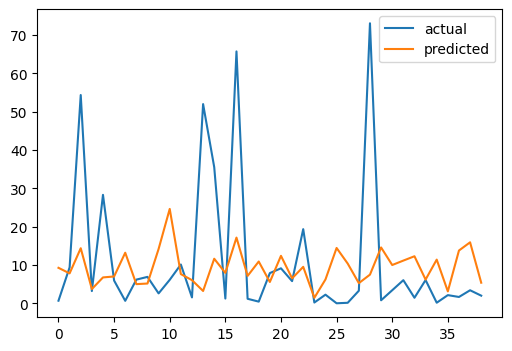

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.38
Best MAE on test set: 6.27
Best MAPE on test set: 605.16%
Best R2 score on test set: -0.03
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


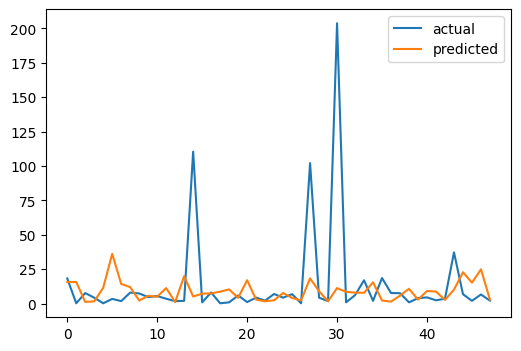

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.44
Best MAE on test set: 4.49
Best MAPE on test set: 115.67%
Best R2 score on test set: -0.44
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


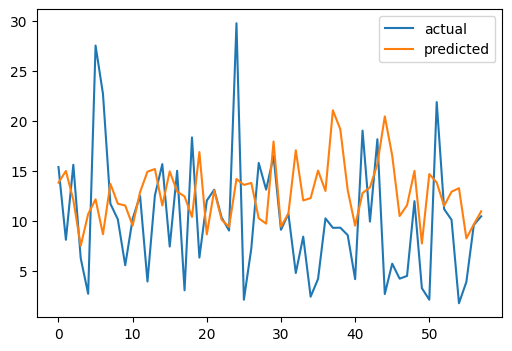




########## Baseline Models for enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 19.27
Best MAE on test set: 9.41
Best MAPE on test set: 2240.57%
Best R2 score on test set: -0.08
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


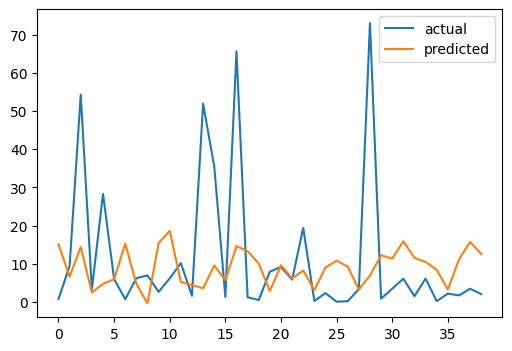

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.58
Best MAE on test set: 6.52
Best MAPE on test set: 680.72%
Best R2 score on test set: -0.04
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


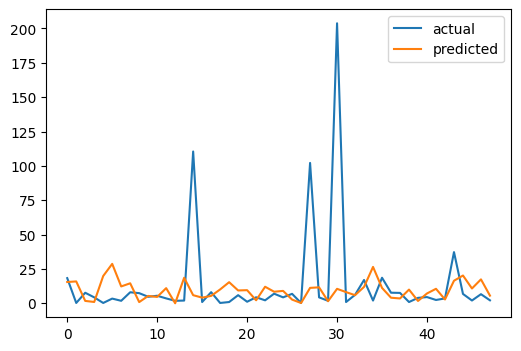

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.97
Best MAE on test set: 4.48
Best MAPE on test set: 121.08%
Best R2 score on test set: -0.65
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


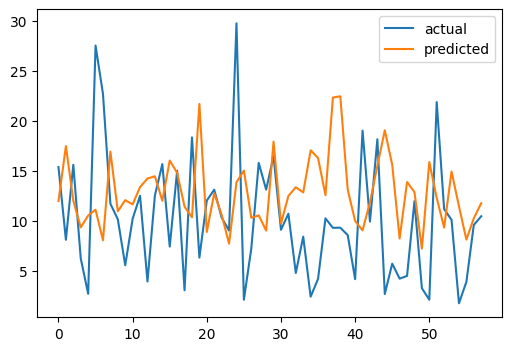




########## Baseline Models for transformed Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 18.84
Best MAE on test set: 7.30
Best MAPE on test set: 2785.74%
Best R2 score on test set: -0.03
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


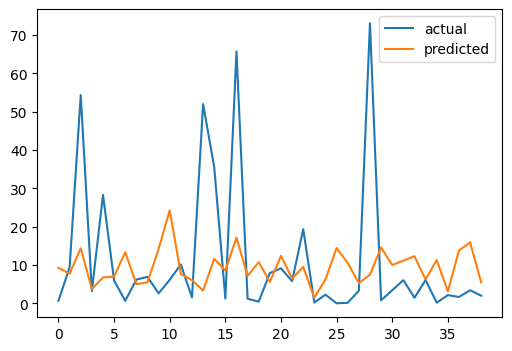

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.26
Best MAE on test set: 6.39
Best MAPE on test set: 601.51%
Best R2 score on test set: -0.02
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


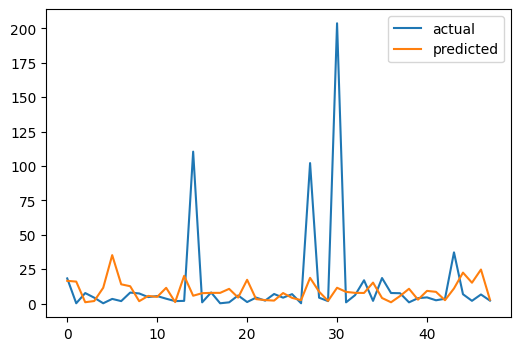

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.45
Best MAE on test set: 4.49
Best MAPE on test set: 116.35%
Best R2 score on test set: -0.44
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


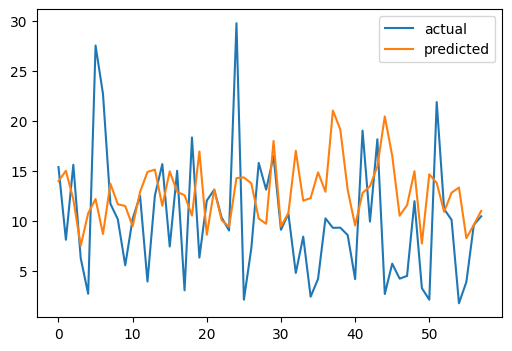

In [ ]:
# Use GradientBoostingRegressor to build the baseline regression models for the target variable 'Revenue_MF', 'Revenue_CC', and 'Revenue_CL'.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd


target_names = ['Revenue_MF', 'Revenue_CC', 'Revenue_CL']
target_indeces = [-3, -2, -1]

# Load the dataset
processed_data_path: str = "../data/processed"
df_modeling = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv"))
df_modeling_enriched = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv"))
df_modeling_transformed = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_transformed.csv"))


for data_set_name, data_set in zip(['not_enriched', 'enriched', 'transformed'], [df_modeling, df_modeling_enriched, df_modeling_transformed]):

    print(f"########## Baseline Models for {data_set_name} Dataset ##########")
    # Iterate through each target variable
    for target_name in target_names:

        df_reg_build = data_set[data_set[target_name]!=0].copy()

        numerical_features = df_reg_build.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])
            
        # ==== Split into features and target ==== 
        X = df_reg_build[numerical_features]
        y = df_reg_build[target_name]
        
        # ==== Split the dataset into train and test datasets ==== 
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define the pipeline
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('regressor', GradientBoostingRegressor(random_state=42))
        ])

        # ==== Hyperparameter distributions for GradientBoostingRegressor ==== 
        # The hyperparameter tuning is performed on the training dataset.
        param_dist = {
            'regressor__n_estimators': randint(100, 1000),
            'regressor__learning_rate': uniform(0.01, 0.3), 
            'regressor__max_depth': randint(3, 10),
            'regressor__min_samples_split': randint(2, 20), 
            'regressor__min_samples_leaf': randint(1, 20),  
            'regressor__subsample': uniform(0.6, 0.4),
            'regressor__max_features': ['sqrt', 'log2', None] 
        }

        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )
        # ==== Fit the model to the training data ==== 
        rs.fit(X_train, y_train)

        # ==== Predict on test set ==== 
        y_pred = rs.best_estimator_.predict(X_test)
        
        # ==== Calculate metrics ==== 
        rmse = root_mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # ==== Print the results ==== 
        print(f"****** Baseline Model Metric and hyperparameters for {target_name} ******")
        print(f"Best RMSE on test set: {rmse:.2f}")
        print(f"Best MAE on test set: {mae:.2f}")    
        print(f"Best MAPE on test set: {mape:.2%}") 
        print(f"Best R2 score on test set: {r2:.2f}")
        print(f"Best Hyperparams: {rs.best_params_}\n" )

        # ==== Plot the Prediction vs. Actual Values ====
        print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
        # Get actual values
        predictions = pd.DataFrame(list(y_test), columns=['actual'])
        predictions['predicted'] = y_pred
        predictions.plot(kind='line',figsize=(6, 4))
        plt.show()
            
    print("\n\n")

########## Baseline Models for not_enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 20.05
Best MAE on test set: 3.61
Best MAPE on test set: 906.42%
Best R2 score on test set: -0.17
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


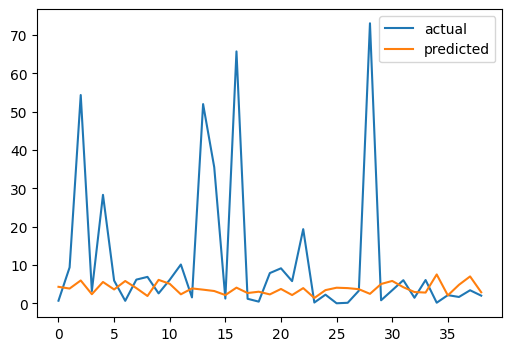

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.46
Best MAE on test set: 3.08
Best MAPE on test set: 283.43%
Best R2 score on test set: -0.04
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


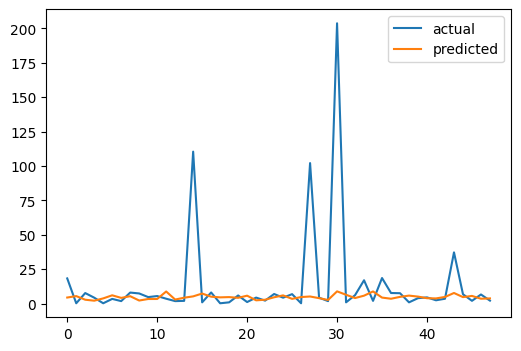

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 6.79
Best MAE on test set: 4.44
Best MAPE on test set: 94.24%
Best R2 score on test set: -0.20
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


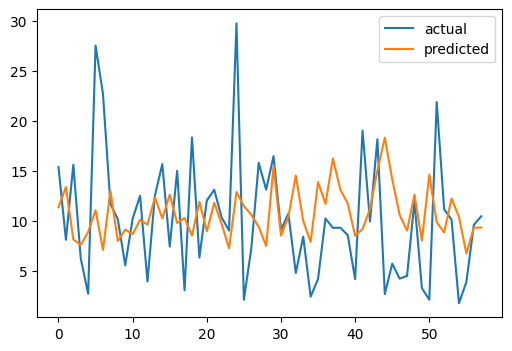




########## Baseline Models for enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 20.30
Best MAE on test set: 3.51
Best MAPE on test set: 1008.48%
Best R2 score on test set: -0.19
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


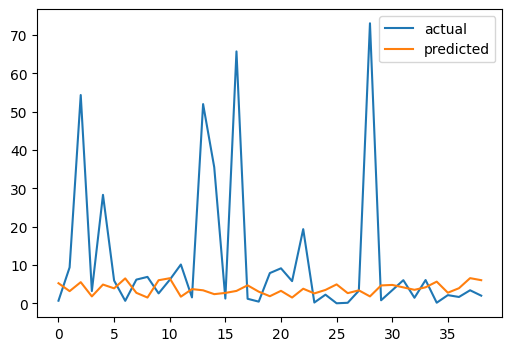

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.44
Best MAE on test set: 3.31
Best MAPE on test set: 278.29%
Best R2 score on test set: -0.04
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


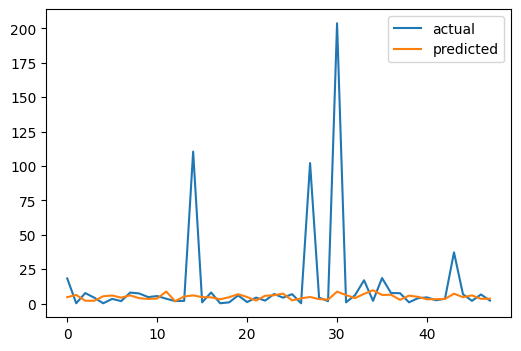

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 6.83
Best MAE on test set: 4.14
Best MAPE on test set: 95.15%
Best R2 score on test set: -0.21
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


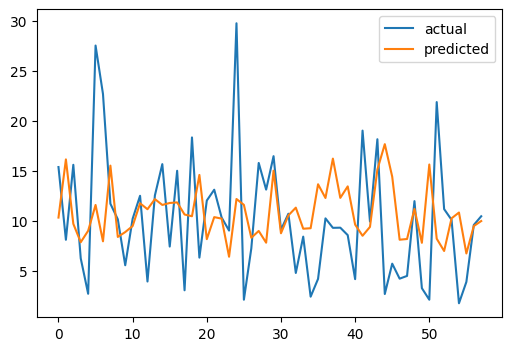




########## Baseline Models for transformed Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 20.07
Best MAE on test set: 3.30
Best MAPE on test set: 958.06%
Best R2 score on test set: -0.17
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


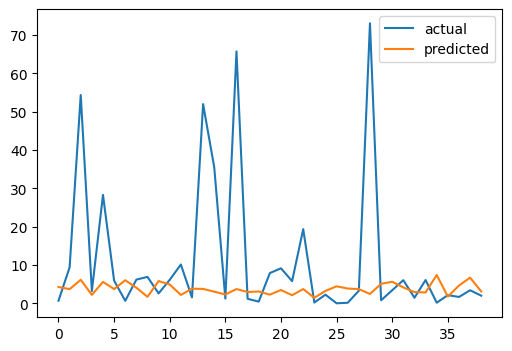

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.46
Best MAE on test set: 3.06
Best MAPE on test set: 282.09%
Best R2 score on test set: -0.04
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


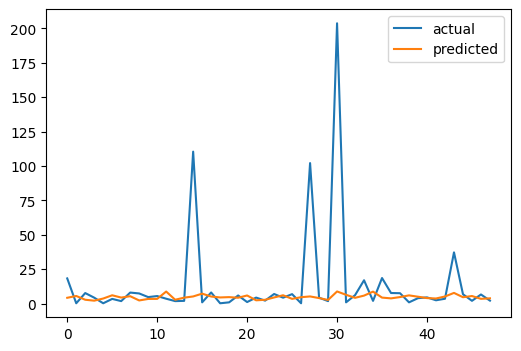

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 6.80
Best MAE on test set: 4.39
Best MAPE on test set: 93.81%
Best R2 score on test set: -0.20
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


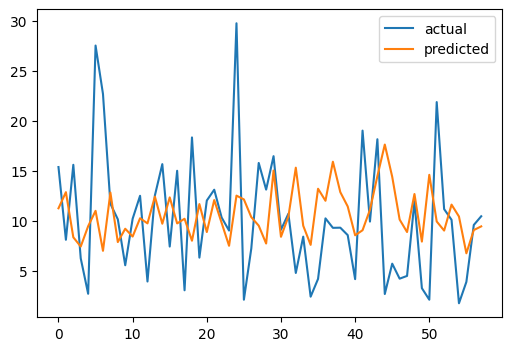

In [ ]:
# Based on the analysis in the sections "3. Basic EDA of the Dataframes" and "4. Preparing the Datasets for Modeling and Prediction", we know than the targets 'Revenue_MF', 'Revenue_CC', and 'Revenue_CL' are highly right-skewed.
# Here, we apply TransformedTargetRegressor to handle skewed targets.

from sklearn.compose import TransformedTargetRegressor

for data_set_name, data_set in zip(['not_enriched', 'enriched', 'transformed'], [df_modeling, df_modeling_enriched, df_modeling_transformed]):

    print(f"########## Baseline Models for {data_set_name} Dataset ##########")
    # Iterate through each target variable
    for target_name in target_names:
        df_reg_build = data_set[data_set[target_name]!=0].copy()

        numerical_features = df_reg_build.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])
            
        # ==== Split into features and target ==== 
        X = df_reg_build[numerical_features]
        y = df_reg_build[target_name]

        # Log-transform the target to reduce skewness
        log_transformer = FunctionTransformer(np.log1p, validate=True)
        y_log = log_transformer.fit_transform(y.values.reshape(-1, 1)).flatten()

        # ==== Split the dataset into train and test datasets ==== 
        X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
        
        # ==== Define the pipeline ==== 
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('regressor', GradientBoostingRegressor(random_state=42))
        ])

        # ==== Hyperparameter distributions for GradientBoostingRegressor ==== 
        # The hyperparameter tuning is performed on the training dataset.
        param_dist = {
            'regressor__n_estimators': randint(100, 1000),
            'regressor__learning_rate': uniform(0.01, 0.3), 
            'regressor__max_depth': randint(3, 10),
            'regressor__min_samples_split': randint(2, 20), 
            'regressor__min_samples_leaf': randint(1, 20),  
            'regressor__subsample': uniform(0.6, 0.4),
            'regressor__max_features': ['sqrt', 'log2', None] 
        }

        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )

        # ==== Fit the model to the training data ====
        rs.fit(X_train, y_train)

        # ==== Predict on test set ==== 
        y_pred_log = rs.best_estimator_.predict(X_test)

        # Inverse transform the predictions to get the original scale
        y_pred = np.expm1(y_pred_log)
        # Inverse transform the test set to get the original scale
        y_test_actual = np.expm1(y_test)

        # ==== Calculate metrics
        rmse = root_mean_squared_error(y_test_actual, y_pred)
        mae = mean_absolute_error(y_test_actual, y_pred)
        mape = mean_absolute_percentage_error(y_test_actual, y_pred)
        r2 = r2_score(y_test_actual, y_pred)

        # ==== Print the results
        print(f"****** Baseline Model Metric and hyperparameters for {target_name} ******")
        print(f"Best RMSE on test set: {rmse:.2f}")
        print(f"Best MAE on test set: {mae:.2f}")    
        print(f"Best MAPE on test set: {mape:.2%}") 
        print(f"Best R2 score on test set: {r2:.2f}")
        print(f"Best Hyperparams: {rs.best_params_}\n" )

        # ==== Plot the Prediction vs. Actual Values ====
        print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
        # Get actual values
        predictions = pd.DataFrame(list(y_test_actual), columns=['actual'])
        predictions['predicted'] = y_pred
        predictions.plot(kind='line',figsize=(6, 4))
        plt.show()
            
    print("\n\n")

### <span style="color:orange">**Baseline Regression Model Evaluation**</span>

---

#### 📊 Key Observations

- The baseline regression models **struggle to predict extreme target values**, despite the use of log transformation to address skewness.
- This challenge is **typical in domains with financial or sales data**, where targets often exhibit **long-tailed distributions and extreme outliers**.
- While log transformation **significantly improved MAE and MAPE**, it did **not lead to improvements in RMSE**, which is more sensitive to large errors.
- The use of **enriched and transformed feature sets** did **not enhance model performance** for the regression task.

---

#### 🧠 Interpretation

- The **log transformation helps stabilize error distribution** for mid-range values but is **insufficient** to capture the behavior of extreme outliers.
- These findings underscore the **limitations of standard regression models** when applied to highly skewed target variables with **heavy tails**.

---

#### ✅ Conclusion

> Given the lack of improvement from feature enrichment and transformation, the **original dataset** will be retained for future modeling.  
> A **more strategic, layered modeling approach** will be pursued to effectively address this long-tail regression problem — including methods tailored to **extreme value prediction**.

### Deep EDA for Skewed Regression Targets

########## Deep EDA results for the Target Revenue_MF ##########

****** Target Distribution Analysis for Revenue_MF ******


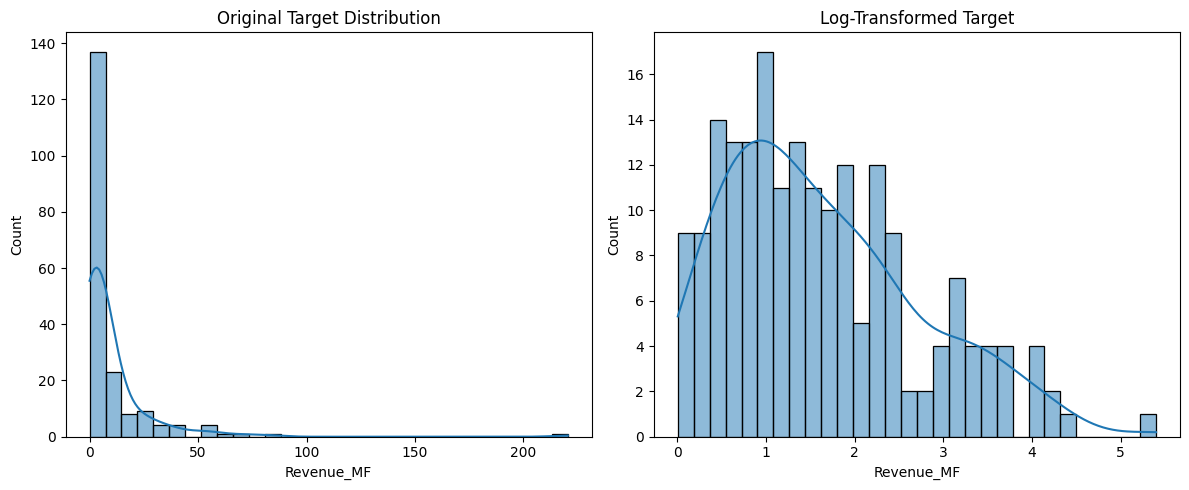

Skewness: 6.40
Kurtosis: 56.94
Outliers (> Q3 + 1.5 * IQR): 26 records

Numerical Features: ['Age', 'Tenure', 'Count_CA', 'Count_SA', 'Count_MF', 'Count_OVD', 'Count_CC', 'Count_CL', 'ActBal_CA', 'ActBal_SA', 'ActBal_MF', 'ActBal_OVD', 'ActBal_CC', 'ActBal_CL', 'VolumeCred', 'VolumeCred_CA', 'TransactionsCred', 'TransactionsCred_CA', 'VolumeDeb', 'VolumeDeb_CA', 'VolumeDebCash_Card', 'VolumeDebCashless_Card', 'VolumeDeb_PaymentOrder', 'TransactionsDeb', 'TransactionsDeb_CA', 'TransactionsDebCash_Card', 'TransactionsDebCashless_Card', 'TransactionsDeb_PaymentOrder', 'Sex_M']
Number of Numerical Features: 29

****** Feature Importance Analysis for Revenue_MF ******


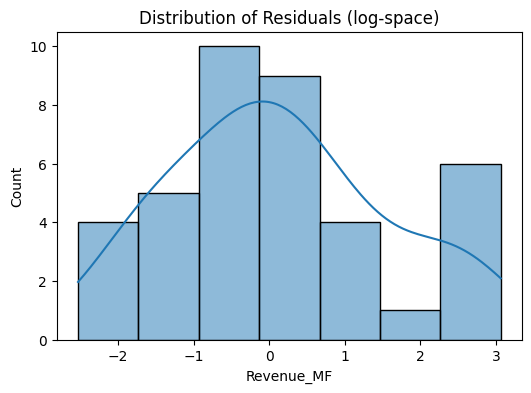

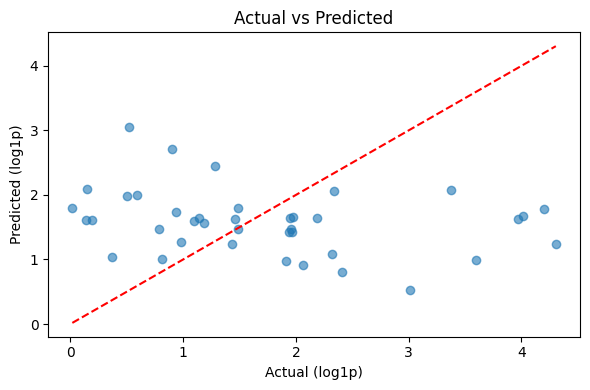

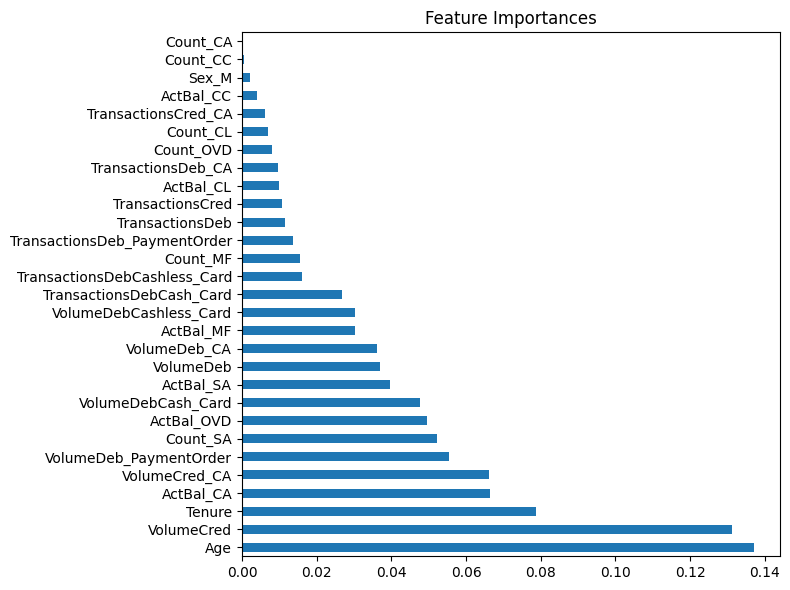

########## Deep EDA results for the Target Revenue_CC ##########

****** Target Distribution Analysis for Revenue_CC ******


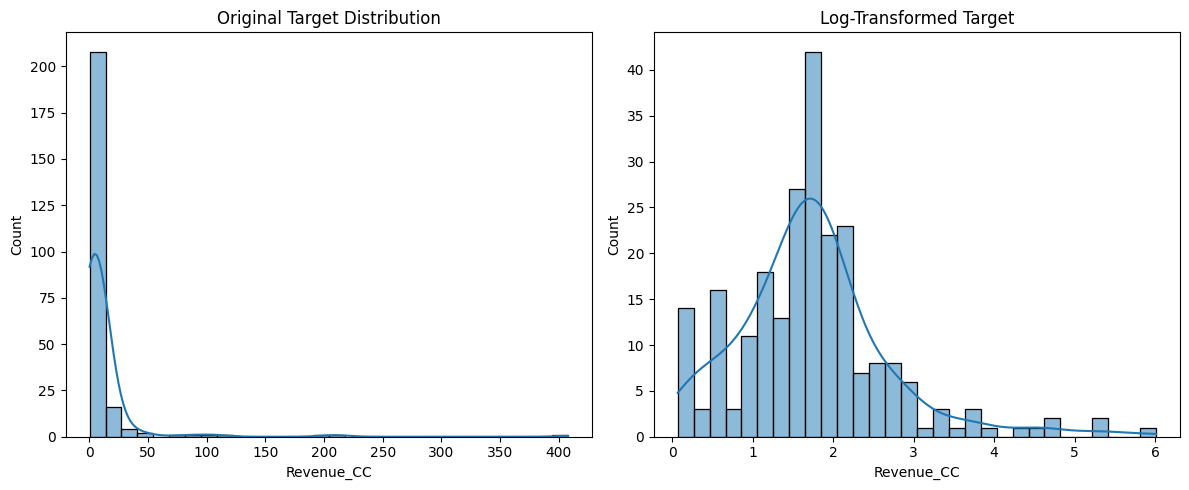

Skewness: 8.31
Kurtosis: 81.16
Outliers (> Q3 + 1.5 * IQR): 27 records

Numerical Features: ['Age', 'Tenure', 'Count_CA', 'Count_SA', 'Count_MF', 'Count_OVD', 'Count_CC', 'Count_CL', 'ActBal_CA', 'ActBal_SA', 'ActBal_MF', 'ActBal_OVD', 'ActBal_CC', 'ActBal_CL', 'VolumeCred', 'VolumeCred_CA', 'TransactionsCred', 'TransactionsCred_CA', 'VolumeDeb', 'VolumeDeb_CA', 'VolumeDebCash_Card', 'VolumeDebCashless_Card', 'VolumeDeb_PaymentOrder', 'TransactionsDeb', 'TransactionsDeb_CA', 'TransactionsDebCash_Card', 'TransactionsDebCashless_Card', 'TransactionsDeb_PaymentOrder', 'Sex_M']
Number of Numerical Features: 29

****** Feature Importance Analysis for Revenue_CC ******


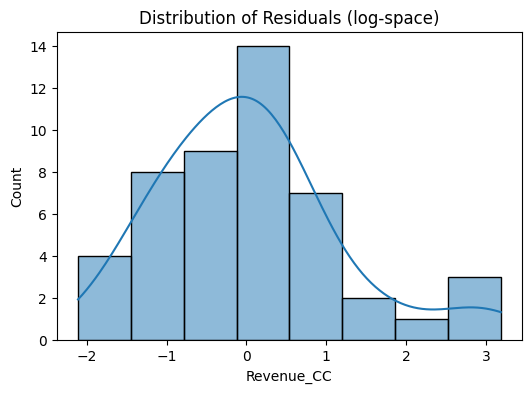

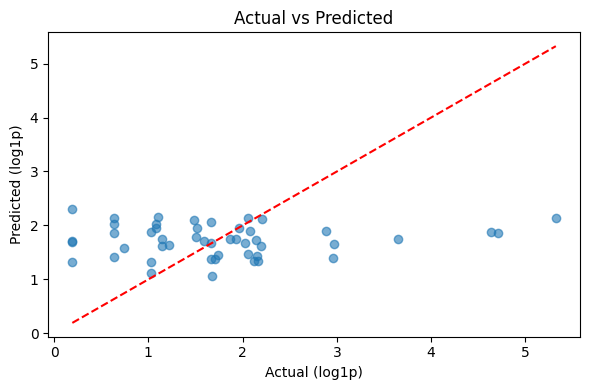

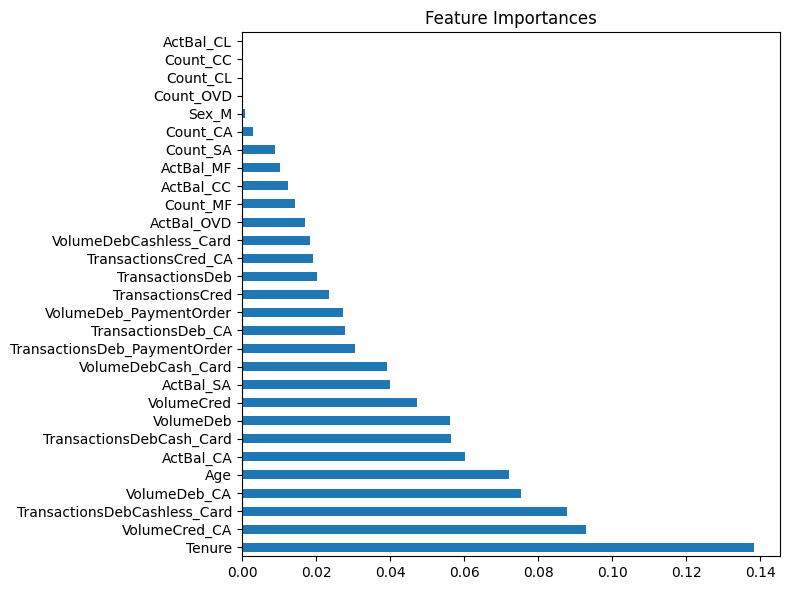

########## Deep EDA results for the Target Revenue_CL ##########

****** Target Distribution Analysis for Revenue_CL ******


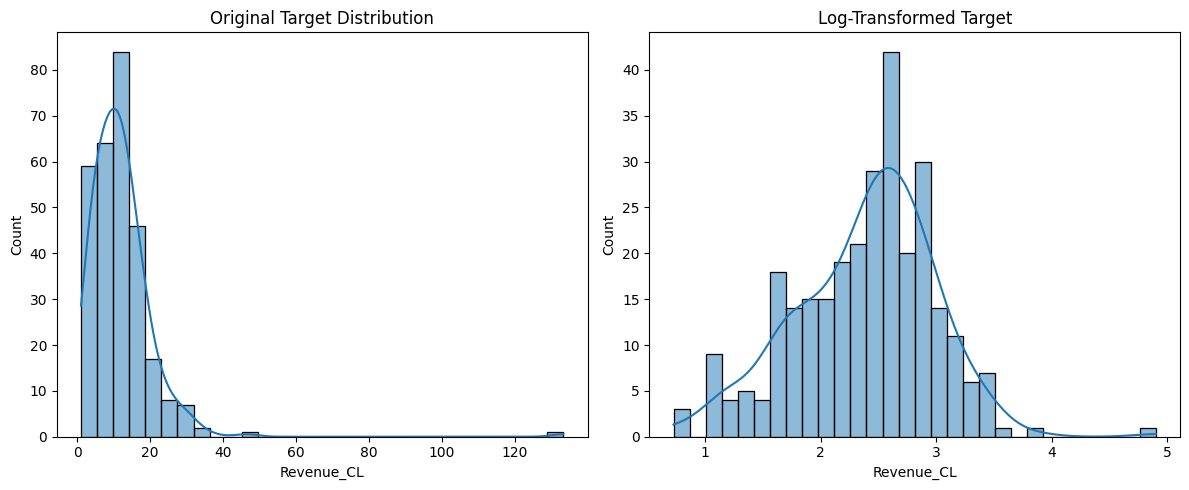

Skewness: 6.62
Kurtosis: 75.05
Outliers (> Q3 + 1.5 * IQR): 8 records

Numerical Features: ['Age', 'Tenure', 'Count_CA', 'Count_SA', 'Count_MF', 'Count_OVD', 'Count_CC', 'Count_CL', 'ActBal_CA', 'ActBal_SA', 'ActBal_MF', 'ActBal_OVD', 'ActBal_CC', 'ActBal_CL', 'VolumeCred', 'VolumeCred_CA', 'TransactionsCred', 'TransactionsCred_CA', 'VolumeDeb', 'VolumeDeb_CA', 'VolumeDebCash_Card', 'VolumeDebCashless_Card', 'VolumeDeb_PaymentOrder', 'TransactionsDeb', 'TransactionsDeb_CA', 'TransactionsDebCash_Card', 'TransactionsDebCashless_Card', 'TransactionsDeb_PaymentOrder', 'Sex_M']
Number of Numerical Features: 29

****** Feature Importance Analysis for Revenue_CL ******


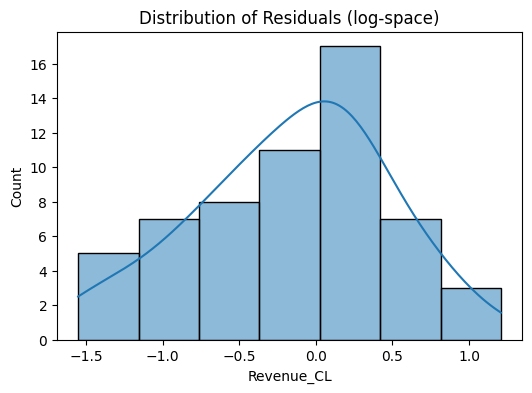

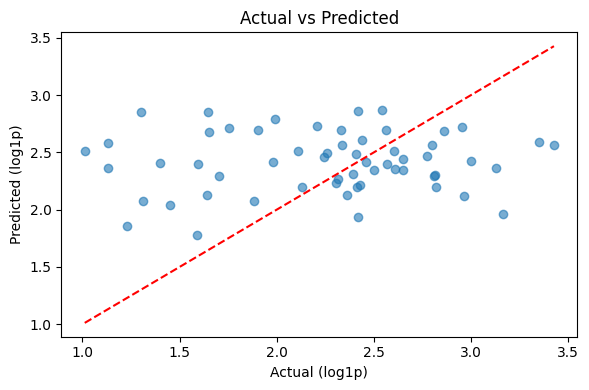

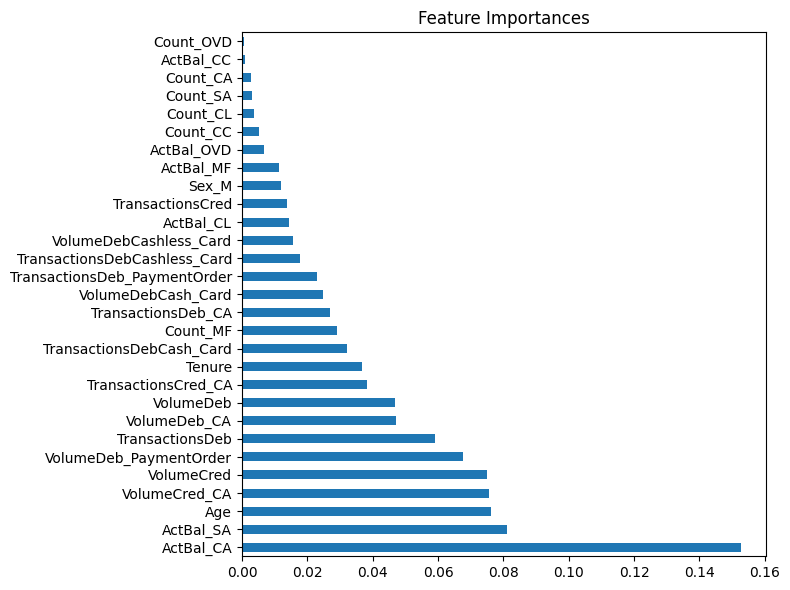

In [ ]:
import seaborn as sns
from scipy.stats import skew, kurtosis

for target_name in target_names:

    print(f"########## Deep EDA results for the Target {target_name} ##########\n")
    df_modeling_reg = df_modeling[df_modeling[target_name]!=0].copy()

    # ==== Target distribution analysis ==== 
    print(f"****** Target Distribution Analysis for {target_name} ******")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_modeling_reg[target_name], kde=True, bins=30)
    plt.title('Original Target Distribution')
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df_modeling_reg[target_name]), kde=True, bins=30)
    plt.title('Log-Transformed Target')
    plt.tight_layout()
    plt.show()

    print(f"Skewness: {skew(df_modeling_reg[target_name]):.2f}")
    print(f"Kurtosis: {kurtosis(df_modeling_reg[target_name]):.2f}")

    # Flag high outliers (e.g., top 10%)
    # Define outliers using the IQR method
    Q1 = df_modeling_reg[target_name].quantile(0.25)
    Q3 = df_modeling_reg[target_name].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    df_modeling_reg['is_outlier'] = df_modeling_reg[target_name] > upper_bound
    print(f"Outliers (> Q3 + 1.5 * IQR): {df_modeling_reg['is_outlier'].sum()} records\n")

    
    # ==== Feature vs Target Relationship Analysis ==== 
    # print(f"****** Feature vs Target Relationship Analysis for {target_name} ******")

    numerical_features = df_modeling_reg.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])
    # print(f"Numerical Features: {numerical_features.tolist()}")
    # print(f"Number of Numerical Features: {len(numerical_features)}\n")

    # for col in numerical_features:
    #     plt.figure(figsize=(6, 4))
    #     sns.scatterplot(x=df_modeling_reg[col], y=df_modeling_reg[target_name], hue=df_modeling_reg['is_outlier'], palette='coolwarm', alpha=0.7)
    #     plt.title(f'{col} vs. Target')
    #     plt.tight_layout()
    #     plt.show()
    
    # ==== Feature Importance Analysis (Baseline Model) ==== 
    print(f"****** Feature Importance Analysis for {target_name} ******")
    
    # Use GradientBoostingRegressor as a baseline model
    X = df_modeling_reg[numerical_features]
    y = df_modeling_reg[target_name]

    # Use log1p target for better behavior
    y_log = np.log1p(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    model = GradientBoostingRegressor().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Residuals
    residuals = y_test - y_pred
    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, kde=True)
    plt.title('Distribution of Residuals (log-space)')
    plt.show()

    # Actual vs Predicted (log-space)
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual (log1p)")
    plt.ylabel("Predicted (log1p)")
    plt.title("Actual vs Predicted")
    plt.tight_layout()
    plt.show()

    # Feature importances
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.sort_values(ascending=False).plot(kind='barh', figsize=(8, 6))
    plt.title("Feature Importances")
    plt.tight_layout()
    plt.show()


### <span style="color:orange">**Deep Exploratory Analysis: Target Skewness & Feature Importance**</span>

---

#### 📈 Key Observations

- **Target Distribution Characteristics**  
  The three target variables (`Revenue_MF`, `Revenue_CC`, `Revenue_CL`) exhibit **high skewness and kurtosis**, confirming that their distributions are **strongly right-skewed with heavy tails**.  
  → This **complicates model fitting**, as standard regression models optimize average loss, which can be disproportionately affected by extreme values.

- **Feature Importance**  
  In all target-specific models, the **maximum feature importance is around 0.142**, with most features **contributing less than 0.08**.  
  → This indicates **weak signal strength** and suggests that the models are **struggling to identify strong predictors**.

- **Predicted vs. Actual Scatter Plots**  
  There is **no clear relationship** between predicted and actual values across the targets, which indicates **severe model underfitting** or that the targets are **heavily noise-driven**.

- **Proportion of Outliers (Non-Zero Target Subsets)**  
  - `Revenue_MF`: 26 outliers / 242 samples → **10.74%**  
  - `Revenue_CC`: 27 outliers / 193 samples → **13.99%**  
  - `Revenue_CL`: 8 outliers / 290 samples → **2.76%**  
  → These relatively **high percentages of extreme values** may significantly hinder model generalization.

---

#### 🧪 Next Modeling Steps

To address the extreme outlier influence and evaluate model robustness, the following experimental strategies will be pursued:

- **Modeling with Outliers**  
  Train models on the **full dataset** using `log(target)` transformation.

- **Modeling without Outliers**  
  Train models on a **filtered subset** excluding extreme outliers, again using `log(target)` transformation.

- **Evaluation Strategy**  
  Both models will be evaluated on a **holdout set that contains outliers**, to assess whether models trained without outliers can better generalize to the “normal” range without being distracted by extremes.

---

#### 🎯 Objective

> These experiments aim to determine whether **excluding outliers during training** helps the models better predict non-extreme cases, while still offering **reasonable generalization** on a realistic test distribution.

### Modeling with and without Outliers and Evaluation Comparison

########## Modeling with and without Outliers for the Target Revenue_MF ##########

Full Dataset Model Performance:
Best Params: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}
RMSE: 20.05, MAE: 10.19, MAPE: 906.42%
Filtered Dataset Model Performance:
Best Params: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}
RMSE: 20.53, MAE: 10.06, MAPE: 641.50%


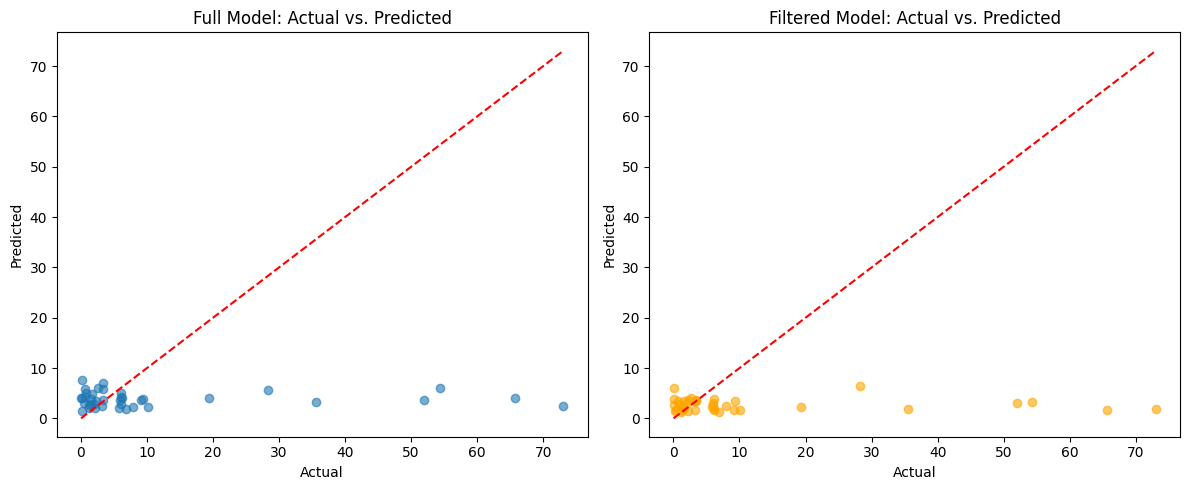




########## Modeling with and without Outliers for the Target Revenue_CC ##########

Full Dataset Model Performance:
Best Params: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}
RMSE: 35.46, MAE: 12.24, MAPE: 283.43%
Filtered Dataset Model Performance:
Best Params: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}
RMSE: 35.96, MAE: 11.99, MAPE: 199.92%


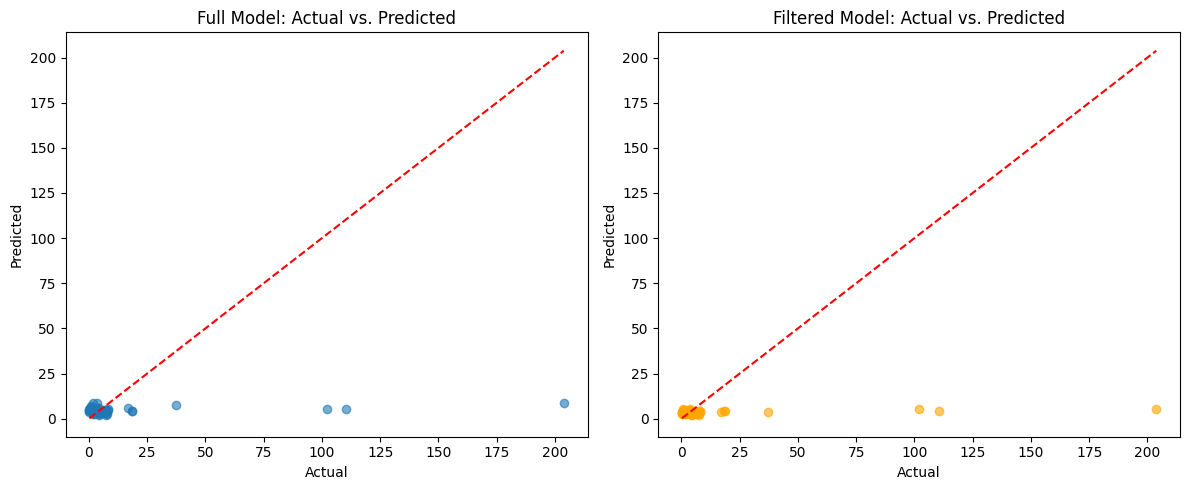




########## Modeling with and without Outliers for the Target Revenue_CL ##########

Full Dataset Model Performance:
Best Params: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}
RMSE: 6.79, MAE: 5.26, MAPE: 94.24%
Filtered Dataset Model Performance:
Best Params: {'regressor__learning_rate': 0.016175348288740735, 'regressor__max_depth': 4, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 6, 'regressor__min_samples_split': 3, 'regressor__n_estimators': 291, 'regressor__subsample': 0.996884623716487}
RMSE: 6.30, MAE: 4.95, MAPE: 83.24%


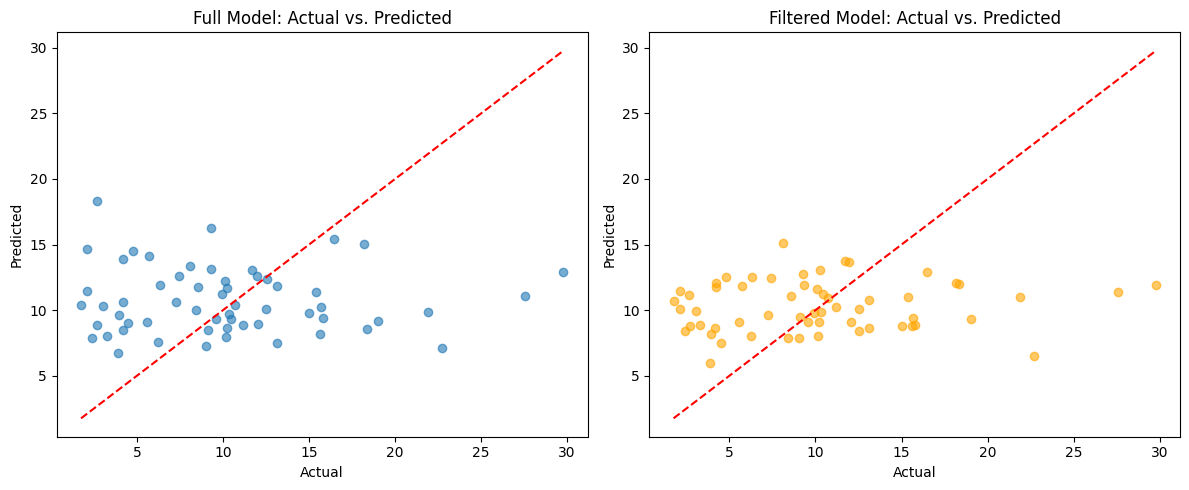

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt


for target_name in target_names:

    print(f"########## Modeling with and without Outliers for the Target {target_name} ##########\n")
    df_modeling_reg = df_modeling[df_modeling[target_name]!=0].copy()

    numerical_features = df_modeling_reg.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])

    # ==== Split into features and target ==== 
    X = df_modeling_reg[numerical_features]
    y = df_modeling_reg[target_name]

    # Log transform the target
    y_log = np.log1p(y)

    # Identify outliers in original scale using IQR ==== 
    Q1, Q3 = y.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    # Create train/test split (before outlier filtering)
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # Create filtered version without outliers (using original y before log)
    non_outlier_mask_train = y.loc[X_train_full.index] <= upper_bound
    X_train_no_outliers = X_train_full[non_outlier_mask_train]
    y_train_no_outliers = y_train_full[non_outlier_mask_train]

    non_outlier_mask_test = y.loc[X_test.index] <= upper_bound
    X_test_no_outliers = X_test[non_outlier_mask_test]
    y_test_no_outliers = y_test[non_outlier_mask_test]

    # ==== Train and evaluate models on both datasets ==== 
    # Define pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", GradientBoostingRegressor(random_state=42))
    ])

    # Define param distributions
    param_dist = {
        "regressor__n_estimators": randint(100, 1000),
        "regressor__learning_rate": uniform(0.01, 0.3),
        "regressor__max_depth": randint(3, 10),
        'regressor__min_samples_split': randint(2, 20), 
        'regressor__min_samples_leaf': randint(1, 20),  
        "regressor__subsample": uniform(0.6, 0.4),
        'regressor__max_features': ['sqrt', 'log2', None] 
    }

    # Function to train and evaluate a pipeline
    def train_and_evaluate(X_train, y_train, name):
        search = RandomizedSearchCV(pipe, 
                                    param_distributions=param_dist, 
                                    n_iter=50, 
                                    scoring="neg_root_mean_squared_error", 
                                    cv=10, 
                                    random_state=42, 
                                    n_jobs=-1)
        search.fit(X_train, y_train)
        y_pred_log = search.best_estimator_.predict(X_test)
        y_pred = np.expm1(y_pred_log)
        y_test_orig = np.expm1(y_test)

        rmse = root_mean_squared_error(y_test_orig, y_pred)
        mae = mean_absolute_error(y_test_orig, y_pred)
        mape = mean_absolute_percentage_error(y_test_orig, y_pred)

        print(f"{name} Model Performance:")
        print(f"Best Params: {search.best_params_}")
        print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2%}")

        return search, y_pred, y_test_orig

    # --- Train on full data (with outliers) ---
    model_full, pred_full, y_test_actual = train_and_evaluate(X_train_full, y_train_full, "Full Dataset")

    # --- Train on filtered data (no outliers) ---
    model_filtered, pred_filtered, _ = train_and_evaluate(X_train_no_outliers, y_train_no_outliers, "Filtered Dataset")

    # Optionally: plot actual vs predicted to visualize differences
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test_actual, pred_full, alpha=0.6)
    plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
    plt.title("Full Model: Actual vs. Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.subplot(1, 2, 2)
    plt.scatter(y_test_actual, pred_filtered, alpha=0.6, color='orange')
    plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
    plt.title("Filtered Model: Actual vs. Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.tight_layout()
    plt.show()
    print("\n\n")
    

### <span style="color:orange">**Evaluation of Full vs. Filtered Dataset Models**</span>

---

#### 📊 Key Findings

- Across all three targets, the **Filtered Dataset Models** perform slightly better than the **Full Dataset Models** in terms of **MAE** and **MAPE**, while **RMSE** is marginally worse.
  - → **MAE / MAPE ↓**: Indicates better accuracy for the **bulk of predictions** (less influenced by extreme values).
  - → **RMSE ↑**: Suggests **worse performance on extreme outliers**, which were excluded during training but still present in the holdout test set.

---

#### 🧠 Interpretation

Given that each target is **highly skewed** and includes **extreme outliers**:

- **MAE and MAPE**, being **less sensitive to large errors**, reflect improved general prediction accuracy when training excludes the most disruptive data points.
- **RMSE**, which heavily penalizes large errors, increases when the model is no longer trained to recognize those outlier patterns.
  
This suggests a **trade-off**:
> Removing outliers during training can improve general accuracy, but reduces the model's ability to extrapolate to extreme cases.

---

#### 🧪 Next Steps: Advanced Modeling Strategies

To better handle skewness and outlier behavior, the following approaches will be explored:

- **Two-Stage Modeling**
  - Step 1: Train a **binary classifier** to detect likely outliers.
  - Step 2: Use:
    - **Model A** for predicting regular-range targets.
    - **Model B** trained specifically on large-value outliers.

- **Quantile Transformation**
  - Apply quantile-based scaling to map targets to a **normal distribution**, improving model fit for standard regressors.

- **Quantile Regression**
  - Shift from point prediction to **interval prediction**, enabling uncertainty-aware forecasts and improved handling of heteroscedasticity.

---

#### 🎯 Objective

> These strategies aim to improve robustness in regression by **separately modeling normal and extreme cases**, and by exploring **distribution-aware transformations and predictions**.

### Outlier-Aware Modeling with Two-stage Modeling Approach

########## Two-stage Modeling for the Target Revenue_MF ##########

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
RMSE on test set: 20.21
MAE on test set: 10.24
MAPE on test set: 891.62%
R2 score on test set: -0.18
****** Model Prediction vs. Actual Values for Revenue_MF ******


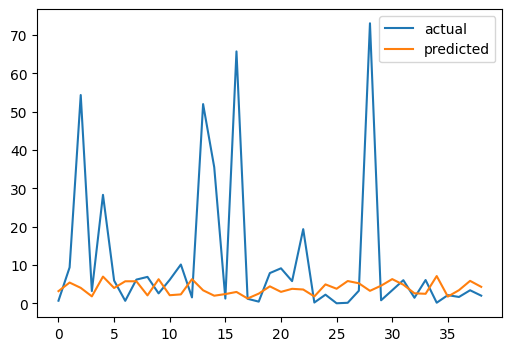




########## Two-stage Modeling for the Target Revenue_CC ##########

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
RMSE on test set: 35.95
MAE on test set: 12.38
MAPE on test set: 248.98%
R2 score on test set: -0.07
****** Model Prediction vs. Actual Values for Revenue_CC ******


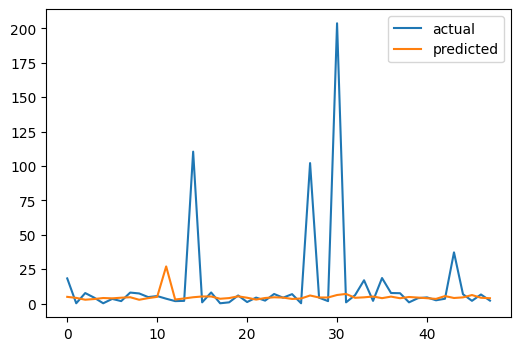




########## Two-stage Modeling for the Target Revenue_CL ##########

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
RMSE on test set: 6.37
MAE on test set: 5.10
MAPE on test set: 96.50%
R2 score on test set: -0.05
****** Model Prediction vs. Actual Values for Revenue_CL ******


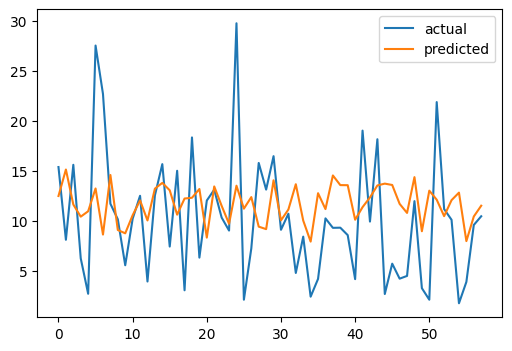

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler

for target_name in target_names:

    print(f"########## Two-stage Modeling for the Target {target_name} ##########\n")

    df_modeling_reg = df_modeling[df_modeling[target_name]!=0].copy()
    numerical_features = df_modeling_reg.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])

    # Split into features and target
    X = df_modeling_reg[numerical_features]
    y = df_modeling_reg[target_name]

    # ==== Identify outliers using IQR ==== 
    Q1, Q3 = y.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    is_outlier = y > upper_bound

    # ==== Train-test split ==== 
    X_train, X_test, y_train, y_test, is_outlier_train, is_outlier_test = train_test_split(
        X, y, is_outlier, test_size=0.2, random_state=42
    )

    # ==== Train classifier to detect outliers with random oversampling ==== 
    y_train_clf = is_outlier_train.astype(int)
    ros = RandomOverSampler(random_state=42)
    X_train_clf_res, y_train_clf_res = ros.fit_resample(X_train, y_train_clf)

    classifier = RandomForestClassifier(random_state=42)
    classifier.fit(X_train_clf_res, y_train_clf_res)

    # ==== Prepare datasets for two regressors ==== 
    X_train_normal = X_train[~is_outlier_train]
    y_train_normal = y_train[~is_outlier_train]

    X_train_outlier = X_train[is_outlier_train]
    y_train_outlier = y_train[is_outlier_train]

    # ==== Synthetic oversampling of outlier regression data ==== 
    X_out_aug, y_out_aug = resample(X_train_outlier, 
                                    y_train_outlier,
                                    replace=True, 
                                    n_samples=len(X_train_normal),
                                    random_state=42)

    # ==== Train regression models ==== 
    normal_pipe = Pipeline(steps=[
                        ('scaler', StandardScaler()),
                        ('regressor', GradientBoostingRegressor(random_state=42))
                    ])
    outlier_pipe = Pipeline(steps=[
                        ('scaler', StandardScaler()),       
                        ('regressor', GradientBoostingRegressor(random_state=42))
                    ])

    # Hyperparameter distributions for GradientBoostingRegressor
    # The hyperparameter tuning is performed on the training dataset.
    param_dist = {
        'regressor__n_estimators': randint(100, 1000),
        'regressor__learning_rate': uniform(0.01, 0.3), 
        'regressor__max_depth': randint(3, 10),
        'regressor__min_samples_split': randint(2, 20), 
        'regressor__min_samples_leaf': randint(1, 20),  
        'regressor__subsample': uniform(0.6, 0.4),
        'regressor__max_features': ['sqrt', 'log2', None] 
    }

    normal_rs = RandomizedSearchCV(
        normal_pipe,
        param_distributions=param_dist,
        scoring='neg_root_mean_squared_error',
        n_iter=50,  # Number of different combinations to try
        cv=10,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    outlier_rs = RandomizedSearchCV(
        outlier_pipe,
        param_distributions=param_dist,
        scoring='neg_root_mean_squared_error',
        n_iter=50,  # Number of different combinations to try
        cv=10,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Fit the models to the training data
    normal_rs.fit(X_train_normal, y_train_normal)
    outlier_rs.fit(X_out_aug, y_out_aug)

    # ==== Predictions ==== 
    is_outlier_pred = classifier.predict(X_test).astype(bool)
    y_pred = np.where(
        is_outlier_pred,
        outlier_rs.best_estimator_.predict(X_test),
        normal_rs.best_estimator_.predict(X_test)
    )

    # ==== Evaluation ==== 
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE on test set: {rmse:.2f}")
    print(f"MAE on test set: {mae:.2f}")
    print(f"MAPE on test set: {mape:.2%}")
    print(f"R2 score on test set: {r2:.2f}")

    # ==== Plotting the results ====
    print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
    # Get actual values
    predictions = pd.DataFrame(list(y_test), columns=['actual'])
    predictions['predicted'] = y_pred
    predictions.plot(kind='line', figsize=(6, 4))
    plt.show()
        
    print("\n\n")


### Quantile Transformation to Map Targets to Normal Distribution

########## Modeling with Quantile Transformation for the Target Revenue_MF ##########

Fitting 10 folds for each of 50 candidates, totalling 500 fits


d:\anaconda3\envs\data_ai_lab\Lib\site-packages\sklearn\preprocessing\_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (154). n_quantiles is set to n_samples.
  warnings.warn(


RMSE on test set: 20.39
MAE on test set: 10.21
MAPE on test set: 903.52%
R2 score on test set: -0.21
****** Model Prediction vs. Actual Values for Revenue_MF ******


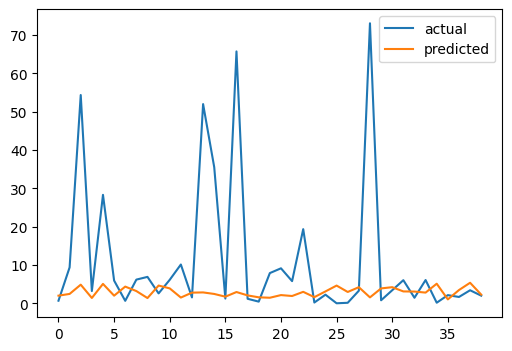




########## Modeling with Quantile Transformation for the Target Revenue_CC ##########

Fitting 10 folds for each of 50 candidates, totalling 500 fits


d:\anaconda3\envs\data_ai_lab\Lib\site-packages\sklearn\preprocessing\_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (189). n_quantiles is set to n_samples.
  warnings.warn(


RMSE on test set: 35.70
MAE on test set: 12.04
MAPE on test set: 259.35%
R2 score on test set: -0.05
****** Model Prediction vs. Actual Values for Revenue_CC ******


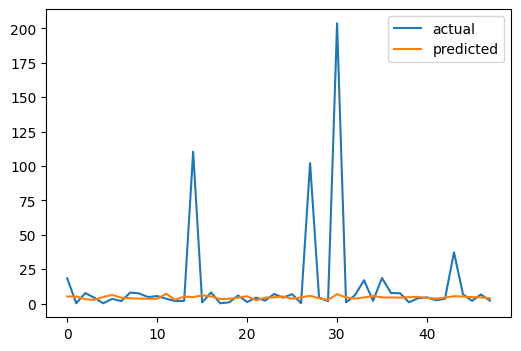




########## Modeling with Quantile Transformation for the Target Revenue_CL ##########

Fitting 10 folds for each of 50 candidates, totalling 500 fits


d:\anaconda3\envs\data_ai_lab\Lib\site-packages\sklearn\preprocessing\_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (231). n_quantiles is set to n_samples.
  warnings.warn(


RMSE on test set: 6.86
MAE on test set: 5.29
MAPE on test set: 97.88%
R2 score on test set: -0.22
****** Model Prediction vs. Actual Values for Revenue_CL ******


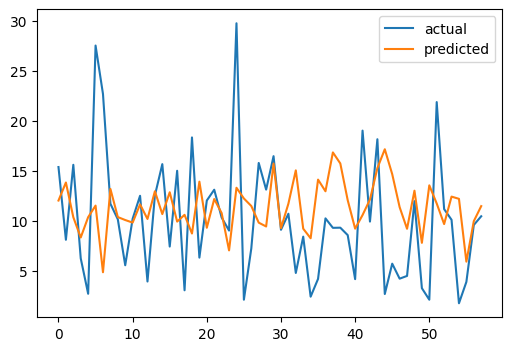

In [ ]:
from sklearn.preprocessing import QuantileTransformer

for target_name in target_names:

    print(f"########## Modeling with Quantile Transformation for the Target {target_name} ##########\n")

    # ==== Prepare Data ====
    df_modeling_reg = df_modeling[df_modeling[target_name]!=0].copy()
    numerical_features = df_modeling_reg.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])

    # Split into features and target
    X = df_modeling_reg[numerical_features]
    y = df_modeling_reg[target_name]

    # Train-test split
    X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

    # ==== Quantile Transformation ====
    qt = QuantileTransformer(output_distribution='normal', random_state=42)

    # Fit on training targets and transform
    y_train_trans = qt.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
    y_test_trans = qt.transform(y_test_raw.values.reshape(-1, 1)).flatten()

    # ==== Model + Hyperparameter Tuning ====
    pipe = Pipeline(steps=[
                        ('scaler', StandardScaler()),
                        ('regressor', GradientBoostingRegressor(random_state=42))
                    ])

    # Hyperparameter distributions for GradientBoostingRegressor
    # The hyperparameter tuning is performed on the training dataset.
    param_dist = {
        'regressor__n_estimators': randint(100, 1000),
        'regressor__learning_rate': uniform(0.01, 0.3), 
        'regressor__max_depth': randint(3, 10),
        'regressor__min_samples_split': randint(2, 20), 
        'regressor__min_samples_leaf': randint(1, 20),  
        'regressor__subsample': uniform(0.6, 0.4),
        'regressor__max_features': ['sqrt', 'log2', None] 
    }

    rs = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        scoring='neg_root_mean_squared_error',
        n_iter=50,  # Number of different combinations to try
        cv=10,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Fit the models to the transformed training data
    rs.fit(X_train, y_train_trans)


    # ==== Predictions & Inverse Transformation ====
    y_pred_trans = rs.predict(X_test)
    y_pred_raw = qt.inverse_transform(y_pred_trans.reshape(-1, 1)).flatten()

    # ==== Evaluation Metrics ====
    rmse = root_mean_squared_error(y_test_raw, y_pred_raw)
    mae = mean_absolute_error(y_test_raw, y_pred_raw)
    mape = mean_absolute_percentage_error(y_test_raw, y_pred_raw)
    r2 = r2_score(y_test_raw, y_pred_raw)

    print(f"RMSE on test set: {rmse:.2f}")
    print(f"MAE on test set: {mae:.2f}")
    print(f"MAPE on test set: {mape:.2%}")
    print(f"R2 score on test set: {r2:.2f}")

    # ==== Plotting the results ====
    print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
    # Get actual values
    predictions = pd.DataFrame(list(y_test_raw), columns=['actual'])
    predictions['predicted'] = y_pred_raw
    predictions.plot(kind='line', figsize=(6, 4))
    plt.show()
        
    print("\n\n")


### Quantile Regression

########## Modeling with Quantile Regression for the Target Revenue_MF ##########

Training quantile regressor for quantile: 0.1
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training quantile regressor for quantile: 0.5
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training quantile regressor for quantile: 0.9
Fitting 10 folds for each of 50 candidates, totalling 500 fits
RMSE on test set: 19.99
MAE on test set: 10.14
MAPE on test set: 1104.98%
R2 score on test set: -0.16
****** Model Prediction (q=0.5) vs. Actual Values for Revenue_MF ******


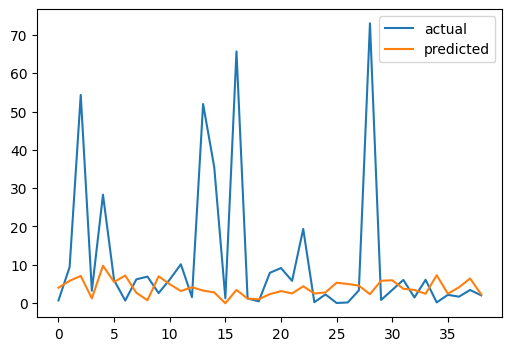

Proportion of test samples within 80% prediction interval: 38.46%



########## Modeling with Quantile Regression for the Target Revenue_CC ##########

Training quantile regressor for quantile: 0.1
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training quantile regressor for quantile: 0.5
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training quantile regressor for quantile: 0.9
Fitting 10 folds for each of 50 candidates, totalling 500 fits
RMSE on test set: 35.57
MAE on test set: 12.03
MAPE on test set: 287.78%
R2 score on test set: -0.04
****** Model Prediction (q=0.5) vs. Actual Values for Revenue_CC ******


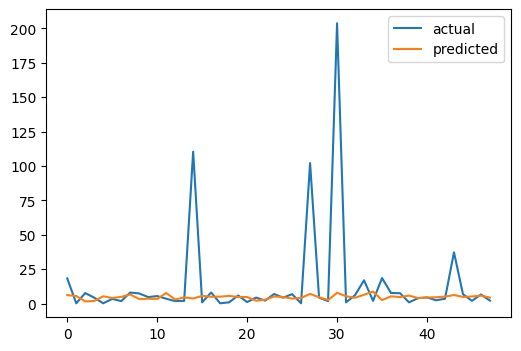

Proportion of test samples within 80% prediction interval: 35.42%



########## Modeling with Quantile Regression for the Target Revenue_CL ##########

Training quantile regressor for quantile: 0.1
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training quantile regressor for quantile: 0.5
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training quantile regressor for quantile: 0.9
Fitting 10 folds for each of 50 candidates, totalling 500 fits
RMSE on test set: 6.56
MAE on test set: 5.18
MAPE on test set: 94.35%
R2 score on test set: -0.12
****** Model Prediction (q=0.5) vs. Actual Values for Revenue_CL ******


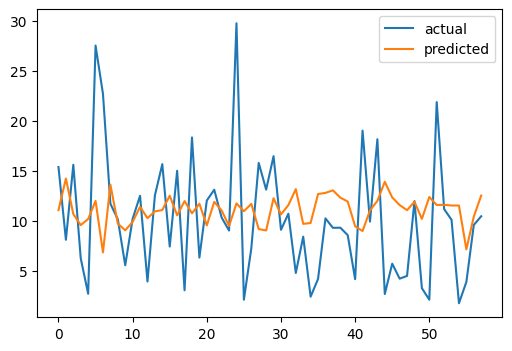

Proportion of test samples within 80% prediction interval: 43.10%





In [34]:
for target_name in target_names:

    print(f"########## Modeling with Quantile Regression for the Target {target_name} ##########\n")

    # ==== Prepare Data ====
    df_modeling_reg = df_modeling[df_modeling[target_name]!=0].copy()
    numerical_features = df_modeling_reg.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])

    # Split into features and target
    X = df_modeling_reg[numerical_features]
    y = df_modeling_reg[target_name]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ==== Train quantile regressors + Hyperparameter Tuning ====
    quantiles = [0.1, 0.5, 0.9]
    searches = {}

    # Hyperparameter distributions for GradientBoostingRegressor
    # The hyperparameter tuning is performed on the training dataset.
    param_dist = {
        'regressor__n_estimators': randint(100, 1000),
        'regressor__learning_rate': uniform(0.01, 0.3), 
        'regressor__max_depth': randint(3, 10),
        'regressor__min_samples_split': randint(2, 20), 
        'regressor__min_samples_leaf': randint(1, 20),  
        'regressor__subsample': uniform(0.6, 0.4),
        'regressor__max_features': ['sqrt', 'log2', None] 
    }

    # Fit the models to the transformed training data
    for q in quantiles:
        print(f"Training quantile regressor for quantile: {q}")
        
        # Define the pipeline
        pipe = Pipeline(steps=[
                    ('scaler', StandardScaler()),
                    ('regressor', GradientBoostingRegressor(loss='quantile', alpha=q, random_state=42))
                ])
        
        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )

        rs.fit(X_train, y_train)
        searches[q] = rs


    # ==== Predict quantiles ====
    y_preds = {q: model.predict(X_test) for q, model in searches.items()}

    # ==== Evaluation Metrics ====
    rmse = root_mean_squared_error(y_test, y_preds[0.5])
    mae = mean_absolute_error(y_test, y_preds[0.5])
    mape = mean_absolute_percentage_error(y_test, y_preds[0.5])
    r2 = r2_score(y_test, y_preds[0.5])

    print(f"RMSE on test set: {rmse:.2f}")
    print(f"MAE on test set: {mae:.2f}")
    print(f"MAPE on test set: {mape:.2%}")
    print(f"R2 score on test set: {r2:.2f}")

    # ==== Plotting the results ====
    print(f"****** Model Prediction (q=0.5) vs. Actual Values for {target_name} ******")
    # Get actual values
    predictions = pd.DataFrame(list(y_test), columns=['actual'])
    predictions['predicted'] = y_preds[0.5]
    predictions.plot(kind='line', figsize=(6, 4))
    plt.show()

    # analyze how well the model captures actual values within the prediction interval (90% CI)
    lower_bound = y_preds[0.1]
    upper_bound = y_preds[0.9]
    # Calculate the proportion of test samples within the prediction interval
    
    within_interval = np.mean((y_test >= lower_bound) & (y_test <= upper_bound))
    print(f"Proportion of test samples within 80% prediction interval: {within_interval:.2%}")
        
    print("\n\n")

### <span style="color:orange">**Summary of Advanced Regression Techniques and Next Steps**</span>

---

#### 🛠️ Techniques Explored So Far

Several advanced strategies have been applied to tackle the challenges of **target skewness**, **extreme outliers**, and **prediction variance**:

- ✅ **Log Transformation** of the target variable to reduce skewness.
- ✅ **Two-Stage Modeling** to separate normal vs. outlier prediction.
- ✅ **Quantile Transformation** of features and targets to approximate a normal distribution.
- ✅ **Quantile Regression** to provide interval predictions and better manage uncertainty.

---

#### 📉 Outcome

Despite these efforts:
- **Model performance**, particularly in terms of **RMSE**, remains limited.
- The models still struggle with **accurately predicting extreme values**, even with targeted preprocessing and layered modeling.

---

#### 🚀 Next Steps: Exploring Alternative Algorithms

To further improve performance, we will experiment with **tree-based ensemble regressors** known for their robustness on noisy, structured, and skewed datasets:

- 🔹 **LightGBM Regressor**
- 🔹 **XGBoost Regressor**
- 🔹 **Random Forest Regressor**

These models will be:
- Trained using the **log-transformed target**.
- **Carefully tuned** via hyperparameter search to optimize for skewed, long-tailed regression tasks.

---

#### 🎯 Goal

> Evaluate whether gradient-boosted and ensemble tree regressors can better capture the nonlinear relationships and mitigate the impact of extreme values and noisy/right-skewed data in this regression challenge.

###  Modeling Experiment with Alternative Regression Algorithms and Hyperparameter Tuning 

In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import FunctionTransformer
from typing import Union
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

best_param_configurations = {}

for target_name in target_names:

    # Initialize the best model configuration
    best_param_configurations[target_name] = None

    print(f"########## Modeling with and without Outliers for the Target {target_name} ##########\n")
    df_modeling_reg = df_modeling[df_modeling[target_name]!=0].copy()

    numerical_features = df_modeling_reg.select_dtypes(include=[np.number]).columns.drop(target_names + ['Client', 'Sale_MF', 'Sale_CC', 'Sale_CL'])

    # ==== Split into features and target ==== 
    X = df_modeling_reg[numerical_features]
    y = df_modeling_reg[target_name]

    # Log-transform the target to reduce skewness
    log_transformer = FunctionTransformer(np.log1p, validate=True)
    y_log = log_transformer.fit_transform(y.values.reshape(-1, 1)).flatten()

    # ==== Create train/test split====
    X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # ==== Define Models and Hyperparameter Grids
    models = {
        'GradientBoosting': GradientBoostingRegressor(random_state=42),
        'RandomForest': RandomForestRegressor(random_state=42),
        'LightGBM': LGBMRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42, verbosity=0)
    }

    param_distributions = {
        'GradientBoosting': {
            'regressor__n_estimators': randint(100, 1000),
            'regressor__learning_rate': uniform(0.01, 0.3), 
            'regressor__max_depth': randint(3, 10),
            'regressor__min_samples_split': randint(2, 20), 
            'regressor__min_samples_leaf': randint(1, 20),  
            'regressor__subsample': uniform(0.6, 0.4),
            'regressor__max_features': ['sqrt', 'log2', None] 
        },
        'RandomForest': {
            'regressor__n_estimators': randint(100, 1000),
            'regressor__max_depth': [None] + list(range(3, 50)),
            'regressor__min_samples_split': randint(2, 20),
            'regressor__min_samples_leaf': randint(1, 20),
            'regressor__max_features': ['sqrt', 'log2'],
            'regressor__bootstrap': [True, False],
        },
        'LightGBM': {
            'regressor__num_leaves': randint(20, 150),                   # Controls complexity
            'regressor__max_depth': randint(3, 15),                      # Max tree depth
            'regressor__learning_rate': uniform(0.01, 0.2),              # Smaller = slower but more accurate
            'regressor__n_estimators': randint(100, 1000),               # Number of boosting rounds
            'regressor__min_child_samples': randint(5, 100),             # Minimum samples in one leaf
            'regressor__subsample': uniform(0.5, 0.5),                   # Row sampling (like bagging)
            'regressor__colsample_bytree': uniform(0.5, 0.5),            # Feature sampling
            'regressor__reg_alpha': uniform(0.0, 1.0),                   # L1 regularization
            'regressor__reg_lambda': uniform(0.0, 1.0),                  # L2 regularization
            'regressor__boosting_type': ['gbdt', 'dart'],                # Boosting type
            'regressor__objective': ['regression', 'huber'],             # Objective function

        },
        'XGBoost': {
            'regressor__n_estimators': randint(100, 1000),              # Number of trees
            'regressor__learning_rate': uniform(0.01, 0.3),             # Step size shrinkage
            'regressor__max_depth': randint(3, 15),                     # Max depth of each tree
            'regressor__min_child_weight': randint(1, 10),              # Minimum sum of instance weight needed in a child
            'regressor__gamma': uniform(0, 5),                          # Minimum loss reduction to make a split
            'regressor__subsample': uniform(0.5, 0.5),                  # % of rows sampled per tree
            'regressor__colsample_bytree': uniform(0.5, 0.5),           # % of features sampled per tree
            'regressor__reg_alpha': uniform(0, 1.0),                    # L1 regularization term
            'regressor__reg_lambda': uniform(0, 1.0),                   # L2 regularization term
        }
    }


    # ==== Perform random search with cross-validation for each modeling algorithm ====
    for name, model in models.items():
        print(f"\nTraining and Tuning {name} Model ...")

        # Define the pipeline
        pipe = Pipeline(steps=[
                    ('scaler', StandardScaler()),
                    ('regressor', model)
                ])
        
        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_distributions[name],
            n_iter=50,
            cv=10,
            scoring='neg_root_mean_squared_error',
            random_state=42,
            verbose=0,
            n_jobs=-1
        )
        rs.fit(X_train, y_train)

        # ==== Predict on test set ==== 
        y_pred_log = rs.best_estimator_.predict(X_test)

        # Inverse transform the predictions to get the original scale
        y_pred = np.expm1(y_pred_log)
        # Inverse transform the test set to get the original scale
        y_test_actual = np.expm1(y_test)

        # Calculate the metrics
        rmse = root_mean_squared_error(y_test_actual, y_pred)
        mae = mean_absolute_error(y_test_actual, y_pred)
        mape = mean_absolute_percentage_error(y_test_actual, y_pred)
        r2 = r2_score(y_test_actual, y_pred)

        # Print the metrics for the current model
        print(f"RMSE on test set: {rmse:.2f}")
        print(f"MAE on test set: {mae:.2f}")
        print(f"MAPE on test set: {mape:.2%}")
        print(f"R2 score on test set: {r2:.2f}")

        if best_param_configurations[target_name] is None:
            best_param_configurations[target_name] = {'modeling_method': name, 'best_score': rmse, 'best_hyperparams': rs.best_params_}  
        else:
            if rmse < best_param_configurations[target_name]['best_score']:
                best_param_configurations[target_name] = {'modeling_method': name, 'best_score': rmse, 'best_hyperparams': rs.best_params_}   

    # ==== Display the best modeling algorithm, best score and best Hyperparameter setting for each target variable ====    
    print(f"\n****** Best Model, Score and Hyperparameters for {target_name} ******")
    print(f"Best Modeling Algorithm: {best_param_configurations[target_name]['modeling_method']}")
    print(f"Best Score: {best_param_configurations[target_name]['best_score']:.2f}")
    print(f"Best hyperparameters: {best_param_configurations[target_name]['best_hyperparams']}\n") 
    print("\n")


# Save the best modling configurations into a JSON file
import json
import os

# Since JSON module in Python doesn't know how to handle NumPy types, we need to convert them to standard Python types.
def convert_numpy_types(obj: Union[np.ndarray, np.generic, dict, list]) -> Union[dict, list, float, int, str]:
    
    """Convert NumPy types to standard Python types for JSON serialization.     
    Args:   
        obj (Union[np.ndarray, np.generic, dict, list]): The object to convert.
       
    Returns:
        Union[dict, list, float, int, str]: The converted object.
    """

    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj
    

cleaned_best_param_configurations = convert_numpy_types(best_param_configurations)

results_path: str = "../results/"
with open(os.path.join(results_path, "best_reg_modeling_configurations.json"), 'w') as f:
    json.dump(cleaned_best_param_configurations, f, indent=4)


########## Modeling with and without Outliers for the Target Revenue_MF ##########


Training and Tuning GradientBoosting Model ...
RMSE on test set: 20.05
MAE on test set: 10.19
MAPE on test set: 906.42%
R2 score on test set: -0.17

Training and Tuning RandomForest Model ...
RMSE on test set: 19.93
MAE on test set: 10.01
MAPE on test set: 856.83%
R2 score on test set: -0.15

Training and Tuning LightGBM Model ...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 154, number of used features: 0
[LightGBM] [Info] Start training from score 1.602588
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the s

### <span style="color:orange">**Comments: Regression Modeling Algorithm Selection Rationale**</span>

The comparison of RMSE on the test set shows that, for different targets, the best-performing regression models vary:
- For **Revenue_MF**, `RandomForestRegressor` yields the lowest RMSE.  
- For **Revenue_CC**, `GradientBoostingRegressor` performs best.  
- For **Revenue_CL**, `XGBRegressor` achieves the best result.

However, for each target, the RMSE produced by `GradientBoostingRegressor`,if it is not the best, is only slightly higher than that of the best-performing model. Given this small performance trade-off, `GradientBoostingRegressor` will be used as the final modeling algorithm for all targets.

This is a pragmatic decision based on the following considerations:

- **Prediction Intervals Availability**  
  `GradientBoostingRegressor` supports quantile regression, enabling the estimation of prediction intervals. This is beneficial for capturing uncertainty rather than relying solely on point predictions.

- **Consistency in Development and Deployment**  
  Since model performance differences are minimal, using a single algorithm across all targets promotes consistency. It simplifies the implementation of inference pipelines and streamlines future model maintenance and monitoring.


### Exploring Modeling Methods and Regression Errors 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

models = [RandomForestRegressor(random_state=0), 
          GradientBoostingRegressor(random_state=0), 
          XGBRegressor(booster='gblinear', random_state=0)]
model_names = ["RandomForest", "GradientBoosting", "XGBoost"]

target_names = ['Revenue_MF', 'Revenue_CC', 'Revenue_CL']
target_indeces = [-3, -2, -1]


for target_name, target_index in zip(target_names, target_indeces):

    df_Rev_build = df_modeling[df_modeling[target_name]!=0].drop(['Client'], axis=1).astype('float32')

    arr_build = df_Rev_build.values
    
    # Scale the data using StandardScaler, as the ensemble regression models are sensetive to scaling 
    scaler = StandardScaler()
    
    arr_scaled = scaler.fit_transform(arr_build)

    X = arr_scaled[:, :-6]
    y = arr_scaled[:, target_index]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"****** Cross-Validation Scores for {target_name} ******")
  
    for model, model_name in zip(models, model_names):
        
        model = model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        print(f"-- {model_name} --")
        # R^2 score
        print("\tMean negtive MAPE:", cross_val_score(model, X, y, scoring="neg_mean_absolute_percentage_error", cv=10, n_jobs=-1).mean()) 
        
        # MAPE on the test set
        print("\tMAPE on test set:", mean_absolute_percentage_error(y_test, y_pred), "\n") 


Cross-validation results show that the MAPE scroes for different modeling algorithms are quite high. **GradientBoostingRegressor** is selected to build the final regression models, as it can be used to generate prediction intervals to give a reasonable range of estimation. 

In [ ]:
# Set lower and upper quantile to produce a 90% confidence interval
LOWER_ALPHA = 0.05
UPPER_ALPHA = 0.95

# Investigate the prediction interval by using GradientBoostingRegressor 
for target_name, target_index in zip(target_names, target_indeces):
    
    df_Rev_build = df_modeling[df_modeling[target_name]!=0].drop(['Client'], axis=1).astype('float32')

    arr_build = df_Rev_build.values
    
    # Scale the data using StandardScaler, as the ensemble regression models are sensetive to scaling 
    scaler = StandardScaler()
    
    arr_scaled = scaler.fit_transform(arr_build)

    X = arr_scaled[:, :-6]
    y = arr_scaled[:, target_index]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"****** Modeling Results for {target_name} ******")    
    
    # Each model has to be separate
    lower_model = GradientBoostingRegressor(loss="quantile", alpha=LOWER_ALPHA)

    # The mid model will use the default loss
    mid_model = GradientBoostingRegressor(loss="quantile", alpha=0.5)

    upper_model = GradientBoostingRegressor(loss="quantile", alpha=UPPER_ALPHA)


    # Fit models
    lower_model.fit(X_train, y_train)
    mid_model.fit(X_train, y_train)
    upper_model.fit(X_train, y_train)
    
    # Get actual values
    predictions = pd.DataFrame(y_test, columns=['actual'])
    
    # Predict
    predictions['lower'] = lower_model.predict(X_test)
    predictions['mid'] = mid_model.predict(X_test)
    predictions['upper'] = upper_model.predict(X_test)
    
    predictions.plot(kind='line',figsize=(6, 4))
    plt.show()


The plots of prediction intervals indicate that the models trained with the quantile loss and different alpha values can generate the good prediction intervals:
* The actual values are usually within the interval derived by the "lower" and "upper" models.
* The "mid" models can be used to generate reasonable estimates of the actual target values. 
<br/><br/>

Therefore, in the marketing optimization, we are going to use the "mid" models to estimate the revenues, while the "lower" and "upper" models will be used to give the 90% confidence interval of the estimation.   

### Building Final Regression Models

In [ ]:
# Build final classification models
def train_regressors(df_modeling: pd.DataFrame, target_name, target_index: int) -> (GradientBoostingRegressor,
                                                                                    GradientBoostingRegressor,
                                                                                    GradientBoostingRegressor,
                                                                                    StandardScaler):
    
    df_Rev_build = df_modeling[df_modeling[target_name]!=0].drop(['Client'], axis=1).astype('float32')

    arr_build = df_Rev_build.values
    
    X = arr_build[:, :-6]
    y = arr_build[:, target_index].reshape(-1, 1)    
    
    arr_filtered = np.concatenate((X, y), axis=1)
    
    # Scale the data using StandardScaler 
    scaler = StandardScaler()
    
    arr_scaled = scaler.fit_transform(arr_filtered)
    
    X_scaled = arr_scaled[:, :-1]
    y_scaled = arr_scaled[:, -1]    
    
    # Define models
    lower_model = GradientBoostingRegressor(loss="quantile", alpha=LOWER_ALPHA)
    mid_model = GradientBoostingRegressor(loss="quantile", alpha=0.5)
    upper_model = GradientBoostingRegressor(loss="quantile", alpha=UPPER_ALPHA)
    
    # Fit models
    lower_model.fit(X_scaled, y_scaled)
    mid_model.fit(X_scaled, y_scaled)
    upper_model.fit(X_scaled, y_scaled)
    
    return lower_model, mid_model, upper_model, scaler


reg_rev_MF_lower, reg_rev_MF_mid, reg_rev_MF_upper, scaler_rev_MF = train_regressors(df_modeling, 
                                                                                     target_names[0], 
                                                                                     target_indeces[0])

reg_rev_CC_lower, reg_rev_CC_mid, reg_rev_CC_upper, scaler_rev_CC = train_regressors(df_modeling, 
                                                                                     target_names[1], 
                                                                                     target_indeces[1])

reg_rev_CL_lower, reg_rev_CL_mid, reg_rev_CL_upper, scaler_rev_CL = train_regressors(df_modeling, 
                                                                                     target_names[2], 
                                                                                     target_indeces[2])


## 7. Generate Optimazation Results to Maximize Revenue

### Estimating Buying Propensity Using the Classification Models

In [ ]:
df_propensity = pd.DataFrame().assign(Client=df_prediction['Client'])
array_prediction = df_prediction.drop(['Client'], axis=1).astype('float32').values
total_num_clients = array_prediction.shape[0]

prob_names = ['prob_MF', 'prob_CC', 'prob_CL']
classifiers = [classifier_Sale_MF, classifier_Sale_CC, classifier_Sale_CL]
target_rates = [target_rate_Sale_MF, target_rate_Sale_CC, target_rate_Sale_CL]

for prob_name, classifier, target_rate in zip(prob_names, classifiers, target_rates):

    # Estimate the probability for a specific product
    probs = classifier.predict_proba(array_prediction)[:, 1]

    # Normalize the probability to make the target rate consistent with that in the training set  
    propensity = probs * (target_rate * total_num_clients) / probs.sum() 

    df_propensity[prob_name] = propensity


### Estimating Revenue and Confidence Intervals Using the Regression Models

In [ ]:
rev_names = [{'mid': 'rev_MF', 'lower': 'rev_MF_lower', 'upper': 'rev_MF_upper'},
             {'mid': 'rev_CC', 'lower': 'rev_CC_lower', 'upper': 'rev_CC_upper'},
             {'mid': 'rev_CL', 'lower': 'rev_CL_lower', 'upper': 'rev_CL_upper'}]

regressors  = [{'mid': reg_rev_MF_mid, 'lower': reg_rev_MF_lower, 'upper': reg_rev_MF_upper},
               {'mid': reg_rev_CC_mid, 'lower': reg_rev_CC_lower, 'upper': reg_rev_CC_upper},
               {'mid': reg_rev_CL_mid, 'lower': reg_rev_CL_lower, 'upper': reg_rev_CL_upper}]

scalers = [scaler_rev_MF, scaler_rev_CC, scaler_rev_CL]


for rev_name, regressor, scaler in zip(rev_names, regressors, scalers):

    # Scale the features
    array_scaled = scaler.transform(np.hstack((array_prediction, np.zeros((array_prediction.shape[0], 1)))))

    # Estimate the revenue for a specific product
    rev = regressor['mid'].predict(array_scaled[:, :-1])
    rev_lower = regressor['lower'].predict(array_scaled[:, :-1])
    rev_upper = regressor['upper'].predict(array_scaled[:, :-1])

    # Invert scaling for prediction
    inv_rev = np.concatenate((array_scaled[:, :-1], rev.reshape(-1, 1)), axis=1)
    inv_rev = scaler.inverse_transform(inv_rev)
    inv_rev = inv_rev[:, -1]

    inv_rev_lower = np.concatenate((array_scaled[:, :-1], rev_lower.reshape(-1, 1)), axis=1)
    inv_rev_lower = scaler.inverse_transform(inv_rev_lower)
    inv_rev_lower = inv_rev_lower[:,-1]

    inv_rev_upper = np.concatenate((array_scaled[:, :-1], rev_upper.reshape(-1, 1)), axis=1)
    inv_rev_upper = scaler.inverse_transform(inv_rev_upper)
    inv_rev_upper = inv_rev_upper[:, -1]


    df_propensity[rev_name['mid']] = inv_rev
    df_propensity[rev_name['lower']] = inv_rev_lower
    df_propensity[rev_name['upper']] = inv_rev_upper


### Generating Optimization Results for Direct Marketing Campaign

In [ ]:
df_predicted = df_propensity.copy()

for product_name in ['MF', 'CC', 'CL']:
    # Calculate the expected revenue for each product
    df_predicted[f'rev_{product_name}_exp'] = df_predicted[f'prob_{product_name}'] * df_predicted[f'rev_{product_name}']
    df_predicted[f'rev_{product_name}_lower_exp'] = df_predicted[f'prob_{product_name}'] * df_predicted[f'rev_{product_name}_lower']
    df_predicted[f'rev_{product_name}_upper_exp'] = df_predicted[f'prob_{product_name}'] * df_predicted[f'rev_{product_name}_upper']
    
# Calculate the expected total revenue    
df_predicted['rev_total_exp'] = df_predicted['rev_MF_exp'] + df_predicted['rev_CC_exp'] + df_predicted['rev_CL_exp']
df_predicted['rev_total_lower_exp'] = df_predicted['rev_MF_lower_exp'] + df_predicted['rev_CC_lower_exp'] + df_predicted['rev_CL_lower_exp']
df_predicted['rev_total_upper_exp'] = df_predicted['rev_MF_upper_exp'] + df_predicted['rev_CC_upper_exp'] + df_predicted['rev_CL_upper_exp']

# Get the top 100 clients to maximize the expected total revenue  
df_predicted = df_predicted.sort_values(by='rev_total_exp', axis=0, ascending=False)
df_optimized = df_predicted.iloc[0:100]

df_optimized = df_optimized[['Client', 'prob_MF', 'prob_CC', 'prob_CL', 'rev_total_exp', 'rev_total_lower_exp', 'rev_total_upper_exp'] ]

print(f"Expected Number of Clients to Buy MF: {df_optimized['prob_MF'].values.sum()}")
print(f"Expected Number of Clients to Buy CC: {df_optimized['prob_CC'].values.sum()}")
print(f"Expected Number of Clients to Buy CL: {df_optimized['prob_CL'].values.sum()}")

print(f"Expected Total Revenue: {df_optimized['rev_total_exp'].values.sum()}")
print(f"90% Confidence Interval of Expected Total Revenue: [{df_optimized['rev_total_lower_exp'].values.sum()}, {df_optimized['rev_total_upper_exp'].values.sum()}]")


In [ ]:
df_optimized.to_csv("Campaign_Targets.csv", index=False)

In [ ]:
df_propensity['prob_MF'].values